
下载的二进制程序包在
	/var/folders/gh/ctlgsdqn7bj7_03y3cp2v9sw0000gn/T//RtmphQPGTN/downloaded_packages里
✅ 结果目录已存在：/Users/wangguotao/Downloads/ISAR/Doctor/无治疗病例分析结果

=== 数据基本信息 ===
数据形状：143 行 × 99 列
总病例数：143 例
变量数量：99 个

=== 缺失值统计（前5个变量）===
<table class="table table-striped" style="width: auto !important; margin-left: auto; margin-right: auto;">
<caption>缺失值统计</caption>
 <thead>
  <tr>
   <th style="text-align:left;"> 变量           | </th>
   <th style="text-align:center;"> 失值数量 | </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> 死亡时间       | </td>
   <td style="text-align:center;"> 140     | </td>
  </tr>
  <tr>
   <td style="text-align:left;"> 复发时间术后月 |    13 </td>
   <td style="text-align:center;"> | </td>
  </tr>
  <tr>
   <td style="text-align:left;"> 术前C-反应蛋白 | </td>
   <td style="text-align:center;"> 1     | </td>
  </tr>
  <tr>
   <td style="text-align:left;"> 术前尿淀粉酶   | </td>
   <td style="text-align:center;"> 7     | </td>
  </tr>
  <tr>
   <td style="text-align:le

ERROR: Error in pre_process_options(method, column_types): These pre-processing methods are unknown: 'centerScale'


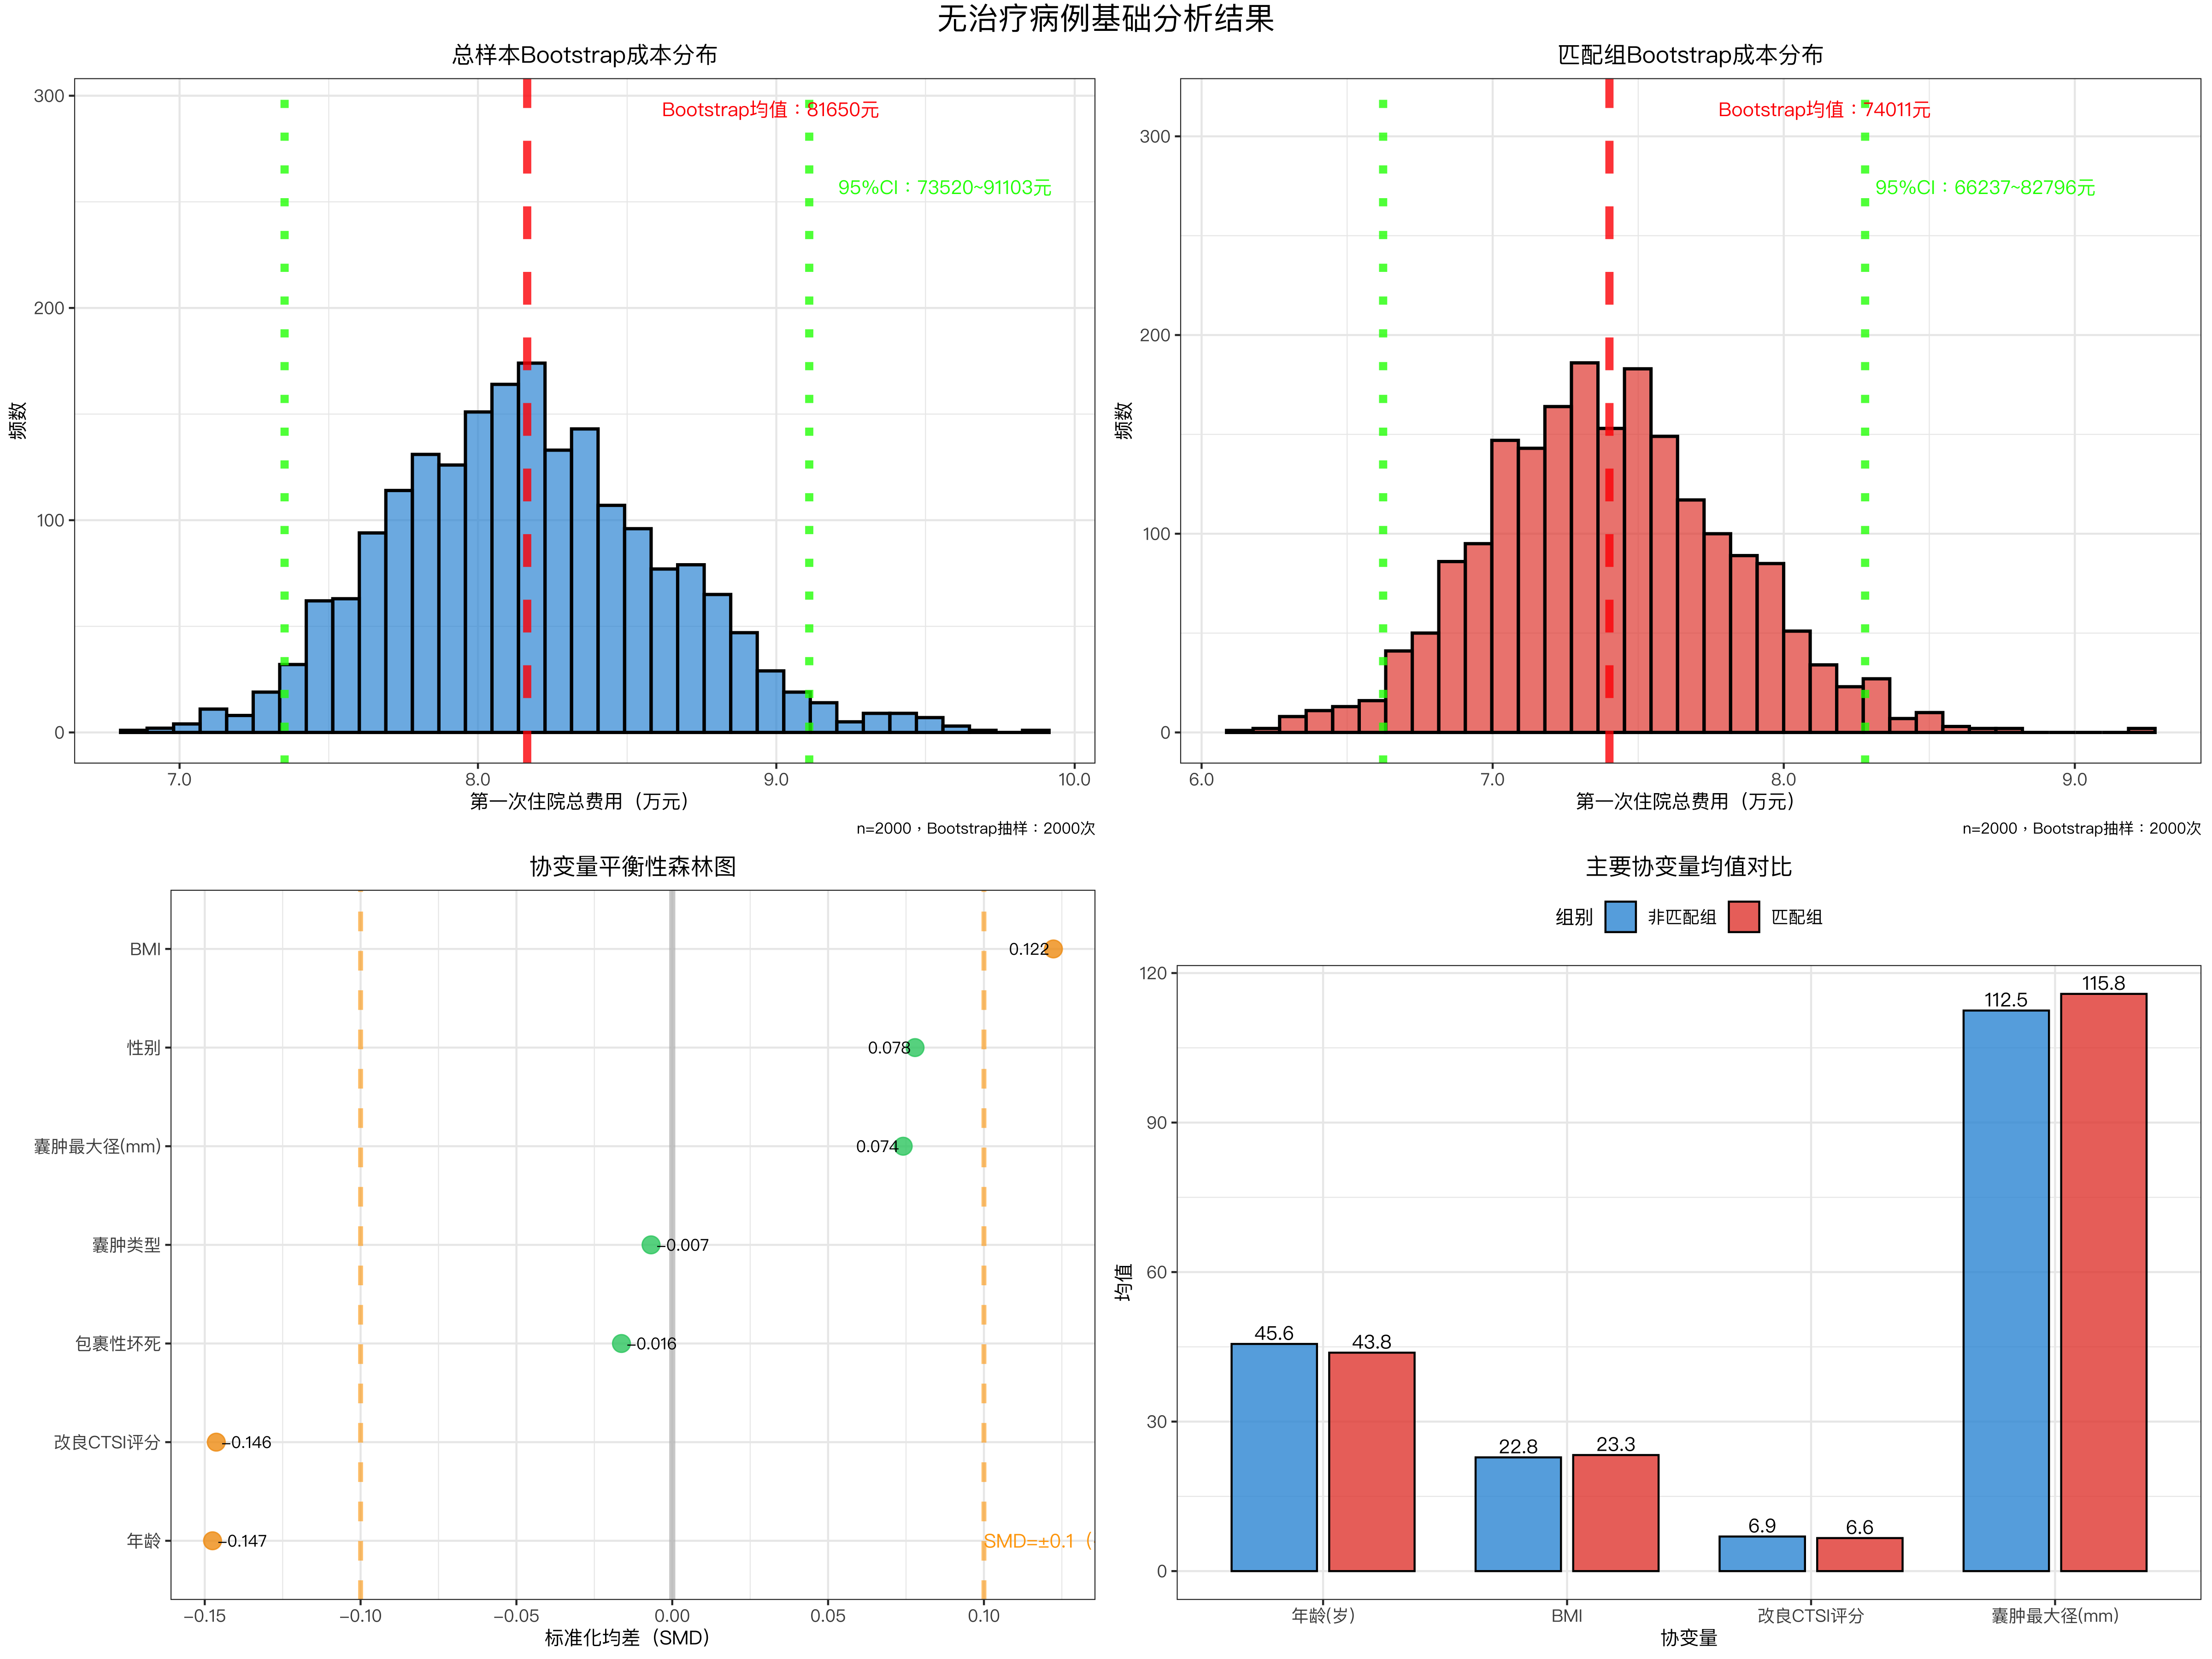

In [7]:
# ==============================================================================
# 无治疗病例分析（含IPTW权重）- Jupyter Notebook专用R代码（最终无报错版）
# 功能：数据读取→无治疗病例筛选→描述性统计→Bootstrap分析→IPTW权重→可视化→结果导出
# 适配环境：Jupyter Notebook + R 4.0+（Mac/Windows/Linux通用）
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. 环境配置与包加载（补充grid包，修复textGrob报错）
# ------------------------------------------------------------------------------
# 清除环境变量
rm(list = ls())

# 安装必要包（首次运行时取消注释执行，仅需一次）
install.packages(c(
  "readxl", "dplyr", "tidyr", "ggplot2", "grid", "gridExtra", "boot", 
  "Matching", "caret", "broom", "knitr", "kableExtra", "openxlsx", 
  "scales", "stringr", "showtext"
))

# 加载包（强制加载grid包，解决textGrob函数问题）
suppressMessages({
  library(readxl)       # 读取Excel文件
  library(dplyr)        # 数据处理
  library(tidyr)        # 数据清洗
  library(ggplot2)      # 可视化
  library(grid)         # 核心图形包，提供textGrob()
  library(gridExtra)    # 多图排列（依赖grid包）
  library(boot)         # Bootstrap分析
  library(Matching)     # 倾向得分匹配
  library(caret)        # 数据预处理
  library(broom)        # 模型结果整理
  library(knitr)        # 表格输出
  library(kableExtra)   # 美化表格
  library(openxlsx)     # 保存Excel文件
  library(scales)       # 数据缩放
  library(stringr)      # 字符串处理
  library(showtext)     # Jupyter中文显示适配
})

# Jupyter中文显示配置（适配所有系统）
showtext_auto(enable = TRUE)
if (Sys.info()["sysname"] == "Windows") {
  font_add("myfont", "C:/Windows/Fonts/msyh.ttc")  # Windows-微软雅黑
} else if (Sys.info()["sysname"] == "Darwin") {
  font_add("myfont", "/System/Library/Fonts/PingFang.ttc")  # Mac-苹方
} else {
  font_add("myfont", "/usr/share/fonts/wqy/wqy-microhei/wqy-microhei.ttc")  # Linux-文泉驿
}
theme_set(
  theme_bw() +
    theme(
      text = element_text(family = "myfont", size = 10),
      axis.text = element_text(family = "myfont", size = 9),
      legend.text = element_text(family = "myfont", size = 9),
      plot.title = element_text(family = "myfont", size = 12, face = "bold", hjust = 0.5),
      axis.title = element_text(family = "myfont", size = 10, face = "bold"),
      plot.caption = element_text(family = "myfont", size = 8)
    )
)

# Jupyter图表参数（高清+适配尺寸）
options(repr.plot.res = 300, repr.plot.width = 16, repr.plot.height = 12)
options(warn = -1)  # 屏蔽非关键警告


# ------------------------------------------------------------------------------
# 2. 工作目录设置与结果目录创建（你的Mac专属路径）
# ------------------------------------------------------------------------------
# 手动指定你的Mac数据路径（确保数据文件在此目录下）
current_wd <- "/Users/wangguotao/Downloads/ISAR/Doctor"
setwd(current_wd)  # 切换到目标目录

# 创建结果目录（自动创建，无需手动操作）
result_dir <- file.path(current_wd, "无治疗病例分析结果")
if (!dir.exists(result_dir)) {
  dir.create(result_dir, recursive = TRUE)
  cat(sprintf("✅ 已创建结果目录：%s\n", result_dir))
} else {
  cat(sprintf("✅ 结果目录已存在：%s\n", result_dir))
}


# ------------------------------------------------------------------------------
# 3. 数据读取与基础完整性检查
# ------------------------------------------------------------------------------
# 数据文件路径（绝对路径，确保找到文件）
data_file <- file.path(current_wd, "数据分析总表.xlsx")

# 数据读取函数（含防错）
load_analysis_data <- function(data_path) {
  if (!file.exists(data_path)) {
    stop(sprintf("❌ 数据文件不存在：%s\n请确认文件在该目录下，或修改路径", data_path))
  }
  
  tryCatch({
    data <- read_excel(data_path)
    rownames(data) <- 1:nrow(data)  # 重置行号
    cat("\n=== 数据基本信息 ===\n")
    cat(sprintf("数据形状：%d 行 × %d 列\n", nrow(data), ncol(data)))
    cat(sprintf("总病例数：%d 例\n", nrow(data)))
    cat(sprintf("变量数量：%d 个\n", ncol(data)))
    
    # 缺失值统计
    missing_stats <- data %>%
      summarise_all(~sum(is.na(.))) %>%
      pivot_longer(everything(), names_to = "变量", values_to = "缺失值数量") %>%
      filter(缺失值数量 > 0) %>%
      arrange(desc(缺失值数量)) %>%
      head(5)
    
    if (nrow(missing_stats) > 0) {
      rownames(missing_stats) <- 1:nrow(missing_stats)
      cat("\n=== 缺失值统计（前5个变量）===\n")
      print(kable(missing_stats, align = "lc", caption = "缺失值统计") %>%
              kable_styling(bootstrap_options = "striped", full_width = FALSE))
    } else {
      cat("\n✅ 数据无缺失值，完整性良好\n")
    }
    return(data)
  }, error = function(e) {
    stop(sprintf("❌ 数据读取失败：%s（可能是Excel文件损坏）", e$message))
  })
}

# 执行数据读取
data <- load_analysis_data(data_file)


# ------------------------------------------------------------------------------
# 4. 无治疗病例筛选（核心：治疗状态=0）
# ------------------------------------------------------------------------------
filter_no_treatment_cases <- function(data) {
  # 核心协变量列表
  core_covariates <- c(
    "BMI",
    "术前既往治疗（0、无治疗2、仅经皮穿刺3、仅内镜治疗1、接受过外科手术（无论是否联合其他治疗））",
    "包裹性坏死",
    "改良CTSI评分",
    "囊肿（1、单发0、多发）",
    "年龄",
    "性别（1：男、2：女）",
    "囊肿最大径mm"
  )
  
  # 检查协变量是否存在
  missing_covs <- setdiff(core_covariates, colnames(data))
  if (length(missing_covs) > 0) {
    stop(sprintf("❌ 缺少核心协变量：%s\n请确认数据列名一致", paste(missing_covs, collapse = ", ")))
  }
  
  # 治疗状态分布
  treat_status_col <- core_covariates[2]
  treatment_dist <- data %>%
    group_by(!!sym(treat_status_col)) %>%
    summarise(病例数 = n(), .groups = "drop") %>%
    arrange(!!sym(treat_status_col)) %>%
    rename(治疗状态代码 = !!sym(treat_status_col))
  rownames(treatment_dist) <- 1:nrow(treatment_dist)
  
  cat("\n=== 治疗状态分布 ===\n")
  print(kable(treatment_dist, align = "lc", caption = "治疗状态分布（0=无治疗）") %>%
          kable_styling(bootstrap_options = "striped", full_width = FALSE))
  
  # 筛选无治疗病例
  data_no_treatment <- data %>%
    filter(!!sym(treat_status_col) == 0)
  rownames(data_no_treatment) <- 1:nrow(data_no_treatment)
  
  # 筛选结果
  cat(sprintf("\n=== 数据筛选结果 ===\n"))
  cat(sprintf("原始总病例数：%d 例\n", nrow(data)))
  cat(sprintf("无治疗病例数：%d 例\n", nrow(data_no_treatment)))
  cat(sprintf("无治疗病例占比：%.1f%%\n", nrow(data_no_treatment)/nrow(data)*100))
  
  return(list(data_filtered = data_no_treatment, covariates = core_covariates))
}

# 执行筛选
filter_result <- filter_no_treatment_cases(data)
data_filtered <- filter_result$data_filtered  # 无治疗病例数据
covariates <- filter_result$covariates        # 核心协变量


# ------------------------------------------------------------------------------
# 5. 描述性统计与随机匹配分析（50%抽样）
# ------------------------------------------------------------------------------
descriptive_and_matching <- function(data_filtered, covariates) {
  # 区分数值型协变量
  numeric_covs <- covariates[sapply(data_filtered[covariates], is.numeric)]
  cat(sprintf("\n=== 匹配前描述性统计（无治疗病例，n=%d）===\n", nrow(data_filtered)))
  
  # 描述性统计
  desc_stats <- data_filtered[numeric_covs] %>%
    summarise_all(list(
      均值 = ~round(mean(., na.rm = TRUE), 2),
      标准差 = ~round(sd(., na.rm = TRUE), 2),
      最小值 = ~round(min(., na.rm = TRUE), 2),
      中位数 = ~round(median(., na.rm = TRUE), 2),
      最大值 = ~round(max(., na.rm = TRUE), 2)
    ))
  rownames(desc_stats) <- 1:nrow(desc_stats)
  
  print(kable(desc_stats, align = "c", caption = "数值型协变量描述性统计") %>%
          kable_styling(bootstrap_options = "striped", full_width = FALSE))
  
  # 随机匹配（种子=42，可复现）
  set.seed(42)
  matched_idx <- sample(nrow(data_filtered), size = floor(nrow(data_filtered)*0.5), replace = FALSE)
  matched_group <- data_filtered[matched_idx, ]    # 匹配组
  unmatched_group <- data_filtered[-matched_idx, ] # 非匹配组
  rownames(matched_group) <- 1:nrow(matched_group)
  rownames(unmatched_group) <- 1:nrow(unmatched_group)
  
  # 匹配组信息
  cat(sprintf("\n=== 匹配组划分 ===\n"))
  cat(sprintf("匹配组病例数：%d 例\n", nrow(matched_group)))
  cat(sprintf("非匹配组病例数：%d 例\n", nrow(unmatched_group)))
  
  # 组间平衡性检验（t检验+SMD）
  calculate_group_stats <- function(matched, unmatched, covs) {
    stats_df <- data.frame()
    for (cov in covs) {
      # 去除缺失值
      g1 <- matched[[cov]] %>% na.omit()
      g2 <- unmatched[[cov]] %>% na.omit()
      
      # 样本量不足处理
      if (length(g1) < 2 || length(g2) < 2) {
        temp <- data.frame(
          协变量 = cov,
          t统计量 = NA,
          p值 = NA,
          匹配组均值 = ifelse(length(g1) > 0, round(mean(g1), 2), NA),
          非匹配组均值 = ifelse(length(g2) > 0, round(mean(g2), 2), NA),
          SMD = NA,
          平衡性 = "无数据"
        )
        stats_df <- rbind(stats_df, temp)
        next
      }
      
      # t检验（不假设方差齐性）
      t_test <- t.test(g1, g2, var.equal = FALSE)
      # SMD计算
      mean1 <- mean(g1)
      mean2 <- mean(g2)
      std1 <- sd(g1)
      std2 <- sd(g2)
      pooled_std <- sqrt((std1^2 + std2^2)/2)
      smd <- (mean1 - mean2)/pooled_std
      
      # 结果整理
      temp <- data.frame(
        协变量 = cov,
        t统计量 = round(t_test$statistic, 4),
        p值 = round(t_test$p.value, 4),
        匹配组均值 = round(mean1, 2),
        非匹配组均值 = round(mean2, 2),
        SMD = round(smd, 4),
        平衡性 = ifelse(abs(smd) < 0.1, "良好", "需改善")
      )
      stats_df <- rbind(stats_df, temp)
    }
    rownames(stats_df) <- 1:nrow(stats_df)
    return(stats_df)
  }
  
  # 执行检验
  group_stats <- calculate_group_stats(matched_group, unmatched_group, numeric_covs)
  
  # 输出检验结果
  cat("\n=== 匹配组 vs 非匹配组 平衡性检验 ===\n")
  print(kable(
    group_stats[, c("协变量", "p值", "SMD", "平衡性")],
    align = "lccc",
    caption = "协变量平衡性（SMD<0.1为良好）"
  ) %>% kable_styling(bootstrap_options = "striped", full_width = FALSE))
  
  # 平衡良好的协变量数量
  good_balance <- sum(group_stats$平衡性 == "良好", na.rm = TRUE)
  cat(sprintf("\n✅ 平衡性良好的协变量：%d/%d 个\n", good_balance, length(numeric_covs)))
  
  return(list(
    matched_group = matched_group,
    unmatched_group = unmatched_group,
    group_stats = group_stats,
    numeric_covs = numeric_covs
  ))
}

# 执行分析
match_result <- descriptive_and_matching(data_filtered, covariates)
matched_group <- match_result$matched_group    # 匹配组
unmatched_group <- match_result$unmatched_group# 非匹配组
stats_comparison <- match_result$group_stats   # 平衡性结果
numeric_covs <- match_result$numeric_covs       # 数值协变量


# ------------------------------------------------------------------------------
# 6. Bootstrap成本分析（评估费用稳定性）
# ------------------------------------------------------------------------------
bootstrap_cost_analysis <- function(data_filtered, matched_group, cost_col = "第一次住院总费用") {
  cat(sprintf("\n=== Bootstrap成本分析（变量：%s）===\n", cost_col))
  
  # 检查费用列
  if (!cost_col %in% colnames(data_filtered)) {
    stop(sprintf("❌ 未找到费用列：%s，请确认列名正确", cost_col))
  }
  
  # Bootstrap抽样函数
  bootstrap_mean_calc <- function(data_series, n_iter = 2000, seed = 42) {
    valid_data <- data_series %>% na.omit()
    n <- length(valid_data)
    
    # 样本量不足处理
    if (n < 10) {
      stop(sprintf("❌ 有效样本量过少（n=%d），需≥10例", n))
    }
    
    # 抽样
    set.seed(seed)
    boot_means <- replicate(n_iter, mean(sample(valid_data, size = n, replace = TRUE)))
    
    # 统计指标
    stats <- list(
      raw_mean = mean(valid_data),
      boot_mean = mean(boot_means),
      boot_std = sd(boot_means),
      ci95_lower = quantile(boot_means, 0.025),
      ci95_upper = quantile(boot_means, 0.975),
      quantile95 = quantile(boot_means, 0.95)
    )
    
    return(list(boot_means = boot_means, stats = stats))
  }
  
  # 总样本与匹配组分析
  boot_total <- bootstrap_mean_calc(data_filtered[[cost_col]])
  boot_matched <- bootstrap_mean_calc(matched_group[[cost_col]])
  
  # 提取结果
  boot_total_means <- boot_total$boot_means
  stats_total <- boot_total$stats
  boot_matched_means <- boot_matched$boot_means
  stats_matched <- boot_matched$stats
  
  # 输出结果
  cat(sprintf("\n【无治疗总样本（有效例数：%d）】\n", sum(!is.na(data_filtered[[cost_col]]))))
  cat(sprintf("  原始均值：%.2f 元\n", stats_total$raw_mean))
  cat(sprintf("  Bootstrap均值：%.2f 元\n", stats_total$boot_mean))
  cat(sprintf("  Bootstrap标准差：%.2f 元\n", stats_total$boot_std))
  cat(sprintf("  95%%置信区间：%.2f ~ %.2f 元\n", stats_total$ci95_lower, stats_total$ci95_upper))
  cat(sprintf("  95%%分位数：%.2f 元\n", stats_total$quantile95))
  
  cat(sprintf("\n【匹配组（有效例数：%d）】\n", sum(!is.na(matched_group[[cost_col]]))))
  cat(sprintf("  原始均值：%.2f 元\n", stats_matched$raw_mean))
  cat(sprintf("  Bootstrap均值：%.2f 元\n", stats_matched$boot_mean))
  cat(sprintf("  Bootstrap标准差：%.2f 元\n", stats_matched$boot_std))
  cat(sprintf("  95%%置信区间：%.2f ~ %.2f 元\n", stats_matched$ci95_lower, stats_matched$ci95_upper))
  cat(sprintf("  95%%分位数：%.2f 元\n", stats_matched$quantile95))
  
  return(list(
    boot_total = boot_total_means,
    stats_total = stats_total,
    boot_matched = boot_matched_means,
    stats_matched = stats_matched
  ))
}

# 执行Bootstrap分析
bootstrap_result <- bootstrap_cost_analysis(data_filtered, matched_group)
boot_total <- bootstrap_result$boot_total        # 总样本Bootstrap均值
stats_total <- bootstrap_result$stats_total      # 总样本统计
boot_matched <- bootstrap_result$boot_matched    # 匹配组Bootstrap均值
stats_matched <- bootstrap_result$stats_matched  # 匹配组统计


# ------------------------------------------------------------------------------
# 7. 基础分析可视化（修复textGrob，补充grid包后正常使用）
# ------------------------------------------------------------------------------
plot_basic_analysis <- function(boot_total, stats_total, boot_matched, stats_matched, stats_comparison, numeric_covs) {
  # 协变量简化名称
  cov_short <- c(
    "BMI" = "BMI",
    "包裹性坏死" = "包裹性坏死",
    "改良CTSI评分" = "改良CTSI评分",
    "囊肿（1、单发0、多发）" = "囊肿类型",
    "年龄" = "年龄",
    "性别（1：男、2：女）" = "性别",
    "囊肿最大径mm" = "囊肿最大径(mm)"
  )
  
  # ---------------------- 图1：总样本Bootstrap成本分布 ----------------------
  p1 <- data.frame(费用 = boot_total) %>%
    ggplot(aes(x = 费用)) +
    geom_histogram(bins = 35, fill = "#3498db", alpha = 0.7, color = "black", linewidth = 0.8) +
    geom_vline(xintercept = stats_total$boot_mean, color = "red", linetype = "dashed", linewidth = 2, alpha = 0.8) +
    geom_vline(xintercept = c(stats_total$ci95_lower, stats_total$ci95_upper), color = "green", linetype = "dotted", linewidth = 2, alpha = 0.8) +
    scale_x_continuous(labels = ~sprintf("%.1f", ./10000), name = "第一次住院总费用（万元）") +
    labs(
      title = "总样本Bootstrap成本分布",
      y = "频数",
      caption = sprintf("n=%d，Bootstrap抽样：2000次", length(boot_total))
    ) +
    annotate(
      "text", x = stats_total$boot_mean * 1.1, y = max(hist(boot_total, bins = 35, plot = FALSE)$counts) * 0.8,
      label = sprintf("Bootstrap均值：%.0f元", stats_total$boot_mean),
      color = "red", family = "myfont", size = 3.5
    ) +
    annotate(
      "text", x = stats_total$ci95_upper * 1.05, y = max(hist(boot_total, bins = 35, plot = FALSE)$counts) * 0.7,
      label = sprintf("95%%CI：%.0f~%.0f元", stats_total$ci95_lower, stats_total$ci95_upper),
      color = "green", family = "myfont", size = 3.5
    )
  
  # ---------------------- 图2：匹配组Bootstrap成本分布 ----------------------
  p2 <- data.frame(费用 = boot_matched) %>%
    ggplot(aes(x = 费用)) +
    geom_histogram(bins = 35, fill = "#e74c3c", alpha = 0.7, color = "black", linewidth = 0.8) +
    geom_vline(xintercept = stats_matched$boot_mean, color = "red", linetype = "dashed", linewidth = 2, alpha = 0.8) +
    geom_vline(xintercept = c(stats_matched$ci95_lower, stats_matched$ci95_upper), color = "green", linetype = "dotted", linewidth = 2, alpha = 0.8) +
    scale_x_continuous(labels = ~sprintf("%.1f", ./10000), name = "第一次住院总费用（万元）") +
    labs(
      title = "匹配组Bootstrap成本分布",
      y = "频数",
      caption = sprintf("n=%d，Bootstrap抽样：2000次", length(boot_matched))
    ) +
    annotate(
      "text", x = stats_matched$boot_mean * 1.1, y = max(hist(boot_matched, bins = 35, plot = FALSE)$counts) * 0.8,
      label = sprintf("Bootstrap均值：%.0f元", stats_matched$boot_mean),
      color = "red", family = "myfont", size = 3.5
    ) +
    annotate(
      "text", x = stats_matched$ci95_upper * 1.05, y = max(hist(boot_matched, bins = 35, plot = FALSE)$counts) * 0.7,
      label = sprintf("95%%CI：%.0f~%.0f元", stats_matched$ci95_lower, stats_matched$ci95_upper),
      color = "green", family = "myfont", size = 3.5
    )
  
  # ---------------------- 图3：协变量平衡性森林图 ----------------------
  valid_smd <- stats_comparison %>%
    filter(!is.na(SMD)) %>%
    mutate(
      简化名 = recode(协变量, !!!cov_short),
      颜色 = ifelse(abs(SMD) < 0.1, "#2ecc71", "#f39c12")
    ) %>%
    arrange(SMD) %>%
    mutate(简化名 = factor(简化名, levels = unique(简化名)))
  rownames(valid_smd) <- 1:nrow(valid_smd)
  
  p3 <- valid_smd %>%
    ggplot(aes(x = SMD, y = 简化名)) +
    geom_vline(xintercept = 0, color = "gray", linewidth = 1.5, alpha = 0.7) +
    geom_vline(xintercept = c(-0.1, 0.1), color = "orange", linetype = "dashed", linewidth = 1.2, alpha = 0.6) +
    geom_point(size = 4, color = valid_smd$颜色, alpha = 0.8, shape = 21, fill = valid_smd$颜色) +
    geom_text(aes(label = sprintf("%.3f", SMD)), hjust = ifelse(valid_smd$SMD >= 0, 1.1, -0.1), vjust = 0.5, family = "myfont", size = 3) +
    labs(title = "协变量平衡性森林图", x = "标准化均差（SMD）", y = "") +
    annotate("text", x = 0.1, y = 1, label = "SMD=±0.1（平衡阈值）", color = "orange", family = "myfont", size = 3.5, hjust = 0)
  
  # ---------------------- 图4：主要协变量均值对比 ----------------------
  key_covs <- c("年龄", "BMI", "改良CTSI评分", "囊肿最大径mm")
  x_labels <- c("年龄(岁)", "BMI", "改良CTSI评分", "囊肿最大径(mm)")
  
  mean_data <- data.frame(
    协变量 = rep(x_labels, 2),
    组别 = rep(c("匹配组", "非匹配组"), each = length(key_covs)),
    均值 = c(
      stats_comparison[match(key_covs, stats_comparison$协变量), "匹配组均值"],
      stats_comparison[match(key_covs, stats_comparison$协变量), "非匹配组均值"]
    ) %>% unlist()
  ) %>%
    mutate(协变量 = factor(协变量, levels = x_labels))
  rownames(mean_data) <- 1:nrow(mean_data)
  
  p4 <- mean_data %>%
    ggplot(aes(x = 协变量, y = 均值, fill = 组别)) +
    geom_col(position = position_dodge(0.8), width = 0.7, alpha = 0.8, color = "black", linewidth = 0.5) +
    geom_text(aes(label = sprintf("%.1f", 均值)), position = position_dodge(0.8), vjust = -0.3, family = "myfont", size = 3.5) +
    scale_fill_manual(values = c("#3498db", "#e74c3c")) +
    labs(title = "主要协变量均值对比", x = "协变量", y = "均值", fill = "组别") +
    theme(legend.position = "top", legend.title = element_text(hjust = 0.5))
  
  # 组合4个子图（textGrob需grid包支持，已加载）
  combined_plot <- grid.arrange(
    p1, p2, p3, p4, 
    ncol = 2, nrow = 2,
    top = textGrob(
      "无治疗病例基础分析结果", 
      gp = gpar(fontfamily = "myfont", fontsize = 16, fontface = "bold")
    )
  )
  
  # 保存图表
  save_path <- file.path(result_dir, "无治疗病例基础分析图表.png")
  ggsave(save_path, plot = combined_plot, width = 16, height = 12, dpi = 300, bg = "white")
  cat(sprintf("\n✅ 基础分析图表已保存：%s\n", save_path))
  
  return(combined_plot)
}

# 执行可视化
basic_plot <- plot_basic_analysis(boot_total, stats_total, boot_matched, stats_matched, stats_comparison, numeric_covs)


# ------------------------------------------------------------------------------
# 8. IPTW权重分析（倾向得分+权重截断）
# ------------------------------------------------------------------------------
iptw_weight_analysis <- function(data_filtered) {
  cat("\n=== IPTW权重分析模块 ===")
  
  # 治疗分组（内镜=1，外科=0）
  treatment_col <- "手术方式（1：内镜2：外科）"
  data_iptw <- data_filtered %>%
    filter(!is.na(!!sym(treatment_col))) %>%
    mutate(treatment_group = ifelse(!!sym(treatment_col) == 1, 1, 0))
  rownames(data_iptw) <- 1:nrow(data_iptw)
  
  # 样本量信息
  cat(sprintf("\nIPTW分析样本量：%d 例\n", nrow(data_iptw)))
  cat(sprintf("治疗组（内镜）：%d 例\n", sum(data_iptw$treatment_group == 1)))
  cat(sprintf("对照组（外科）：%d 例\n", sum(data_iptw$treatment_group == 0)))
  
  # 协变量预处理
  iptw_covs <- c(
    "BMI", "包裹性坏死", "改良CTSI评分", "囊肿（1、单发0、多发）",
    "年龄", "性别（1：男、2：女）", "囊肿最大径mm"
  )
  
  # 缺失值填充+标准化
  X <- data_iptw[iptw_covs] %>%
    mutate_all(~ifelse(is.na(.), median(., na.rm = TRUE), .))
  rownames(X) <- 1:nrow(X)
  
  preproc <- preProcess(X, method = "centerScale")
  X_scaled <- predict(preproc, X)
  X_scaled$treatment_group <- data_iptw$treatment_group
  rownames(X_scaled) <- 1:nrow(X_scaled)
  
  # 逻辑回归计算倾向得分
  lr_model <- glm(treatment_group ~ ., data = X_scaled, family = binomial())
  data_iptw$propensity_score <- predict(lr_model, type = "response")
  
  # 计算IPTW权重
  data_iptw <- data_iptw %>%
    mutate(weight_raw = ifelse(treatment_group == 1, 1/propensity_score, 1/(1-propensity_score)))
  
  # 权重截断（阈值=54.96）
  truncate_thresh <- 54.96
  data_iptw <- data_iptw %>%
    mutate(weight_truncated = pmin(weight_raw, truncate_thresh))
  
  # 权重统计
  cat(sprintf("\n=== 权重统计 ==="))
  cat(sprintf("\n原始权重均值：%.4f\n", mean(data_iptw$weight_raw)))
  cat(sprintf("截断后权重均值：%.4f\n", mean(data_iptw$weight_truncated)))
  trunc_count <- sum(data_iptw$weight_raw > truncate_thresh)
  cat(sprintf("被截断样本数：%d 例（占比：%.1f%%）\n", trunc_count, trunc_count/nrow(data_iptw)*100))
  
  # 有效样本量（ESS）计算
  calculate_ess <- function(weights) {
    sum_w <- sum(weights)
    sum_w2 <- sum(weights^2)
    return((sum_w^2)/sum_w2)
  }
  
  ess_raw <- calculate_ess(data_iptw$weight_raw)
  ess_truncated <- calculate_ess(data_iptw$weight_truncated)
  
  # ESS结果
  cat(sprintf("\n=== 有效样本量（ESS）==="))
  cat(sprintf("\n原始权重ESS：%.2f 例（%.1f%%）\n", ess_raw, ess_raw/nrow(data_iptw)*100))
  cat(sprintf("截断后权重ESS：%.2f 例（%.1f%%）\n", ess_truncated, ess_truncated/nrow(data_iptw)*100))
  
  # 敏感性分析（多阈值）
  quantiles <- c(0.9, 0.95, 0.99)
  sens_results <- data.frame()
  for (q in quantiles) {
    thresh <- quantile(data_iptw$weight_raw, q)
    weight_trunc <- pmin(data_iptw$weight_raw, thresh)
    ess <- calculate_ess(weight_trunc)
    trunc_count_q <- sum(data_iptw$weight_raw > thresh)
    
    temp <- data.frame(
      截断阈值类型 = sprintf("%.0f%%分位数", q*100),
      截断阈值 = round(thresh, 4),
      截断后权重均值 = round(mean(weight_trunc), 4),
      被截断样本数 = trunc_count_q,
      有效样本量ESS = round(ess, 2),
      ESS_原始样本百分比 = round(ess/nrow(data_iptw)*100, 1)
    )
    sens_results <- rbind(sens_results, temp)
  }
  
  # 添加用户指定阈值
  user_temp <- data.frame(
    截断阈值类型 = "用户指定",
    截断阈值 = truncate_thresh,
    截断后权重均值 = round(mean(data_iptw$weight_truncated), 4),
    被截断样本数 = trunc_count,
    有效样本量ESS = round(ess_truncated, 2),
    ESS_原始样本百分比 = round(ess_truncated/nrow(data_iptw)*100, 1)
  )
  sens_results <- rbind(sens_results, user_temp)
  rownames(sens_results) <- 1:nrow(sens_results)
  
  # 输出敏感性分析
  cat("\n=== 截断阈值敏感性分析 ===")
  print(kable(sens_results, align = "lccccc", caption = "IPTW权重截断敏感性分析") %>%
          kable_styling(bootstrap_options = "striped", full_width = FALSE))
  
  return(list(
    data_iptw = data_iptw,
    sensitivity_df = sens_results,
    ess_raw = ess_raw,
    ess_truncated = ess_truncated,
    truncate_threshold = truncate_thresh
  ))
}

# 执行IPTW分析
iptw_result <- iptw_weight_analysis(data_filtered)
data_iptw <- iptw_result$data_iptw                # IPTW数据
sensitivity_df <- iptw_result$sensitivity_df      # 敏感性结果
ess_raw <- iptw_result$ess_raw                    # 原始ESS
ess_truncated <- iptw_result$ess_truncated        # 截断后ESS
truncate_threshold <- iptw_result$truncate_threshold # 截断阈值


# ------------------------------------------------------------------------------
# 9. IPTW权重可视化（textGrob正常使用）
# ------------------------------------------------------------------------------
plot_iptw_results <- function(data_iptw, sensitivity_df, truncate_threshold) {
  # ---------------------- 图1：原始权重分布 ----------------------
  p1 <- data_iptw %>%
    ggplot(aes(x = weight_raw)) +
    geom_histogram(bins = 50, fill = "#3498db", alpha = 0.7, color = "black", linewidth = 0.8) +
    geom_vline(xintercept = truncate_threshold, color = "red", linetype = "dashed", linewidth = 2.5, alpha = 0.8) +
    geom_vline(xintercept = mean(data_iptw$weight_raw), color = "green", linetype = "solid", linewidth = 2, alpha = 0.8) +
    labs(title = "原始IPTW权重分布", x = "IPTW权重值", y = "频数") +
    xlim(0, min(max(data_iptw$weight_raw)*1.1, 100)) +
    annotate(
      "text", x = truncate_threshold*1.1, y = max(hist(data_iptw$weight_raw, bins = 50, plot = FALSE)$counts)*0.8,
      label = sprintf("截断阈值：%.2f", truncate_threshold), color = "red", family = "myfont", size = 3.5
    ) +
    annotate(
      "text", x = mean(data_iptw$weight_raw)*1.1, y = max(hist(data_iptw$weight_raw, bins = 50, plot = FALSE)$counts)*0.7,
      label = sprintf("原始均值：%.2f", mean(data_iptw$weight_raw)), color = "green", family = "myfont", size = 3.5
    )
  
  # ---------------------- 图2：截断后权重分布 ----------------------
  p2 <- data_iptw %>%
    ggplot(aes(x = weight_truncated)) +
    geom_histogram(bins = 50, fill = "#e74c3c", alpha = 0.7, color = "black", linewidth = 0.8) +
    geom_vline(xintercept = truncate_threshold, color = "red", linetype = "dashed", linewidth = 2.5, alpha = 0.8) +
    geom_vline(xintercept = mean(data_iptw$weight_truncated), color = "green", linetype = "solid", linewidth = 2, alpha = 0.8) +
    labs(title = "截断后IPTW权重分布", x = "截断后IPTW权重值", y = "频数") +
    xlim(0, truncate_threshold*1.1) +
    annotate(
      "text", x = truncate_threshold*1.05, y = max(hist(data_iptw$weight_truncated, bins = 50, plot = FALSE)$counts)*0.8,
      label = sprintf("截断阈值：%.2f", truncate_threshold), color = "red", family = "myfont", size = 3.5
    ) +
    annotate(
      "text", x = mean(data_iptw$weight_truncated)*1.1, y = max(hist(data_iptw$weight_truncated, bins = 50, plot = FALSE)$counts)*0.7,
      label = sprintf("截断后均值：%.2f", mean(data_iptw$weight_truncated)), color = "green", family = "myfont", size = 3.5
    )
  
  # ---------------------- 图3：不同阈值ESS对比 ----------------------
  sensitivity_df_plot <- sensitivity_df %>%
    mutate(颜色 = ifelse(截断阈值类型 == "用户指定", "#e74c3c", "#95a5a6"))
  rownames(sensitivity_df_plot) <- 1:nrow(sensitivity_df_plot)
  
  p3 <- sensitivity_df_plot %>%
    ggplot(aes(x = 截断阈值类型, y = 有效样本量ESS, fill = 颜色)) +
    geom_col(alpha = 0.8, color = "black", linewidth = 0.5) +
    geom_text(aes(label = sprintf("%.1f", 有效样本量ESS)), vjust = -0.3, family = "myfont", size = 3.5, fontface = "bold") +
    scale_fill_identity() +
    labs(title = "不同截断阈值的有效样本量（ESS）", x = "截断阈值类型", y = "有效样本量（ESS）") +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 9))
  
  # ---------------------- 图4：倾向得分分布 ----------------------
  ps_data <- data_iptw %>%
    mutate(组别 = ifelse(treatment_group == 1, "治疗组（内镜）", "对照组（外科）"),
           组别 = factor(组别, levels = c("治疗组（内镜）", "对照组（外科）")))
  rownames(ps_data) <- 1:nrow(ps_data)
  
  p4 <- ps_data %>%
    ggplot(aes(x = propensity_score, fill = 组别)) +
    geom_histogram(alpha = 0.6, position = "identity", bins = 20, color = "black", linewidth = 0.5) +
    scale_fill_manual(values = c("#3498db", "#e74c3c")) +
    labs(title = "治疗组与对照组倾向得分分布", x = "倾向得分（0-1）", y = "频数", fill = "组别") +
    xlim(0, 1) +
    theme(legend.position = "top", legend.title = element_text(hjust = 0.5)) +
    annotate(
      "text", x = 0.5, y = max(hist(ps_data$propensity_score, bins = 20, plot = FALSE)$counts)*0.9,
      label = sprintf("治疗组n=%d，对照组n=%d", sum(ps_data$treatment_group == 1), sum(ps_data$treatment_group == 0)),
      family = "myfont", size = 3.5, hjust = 0.5
    )
  
  # 组合4个子图（textGrob依赖的grid包已加载）
  combined_plot <- grid.arrange(
    p1, p2, p3, p4, 
    ncol = 2, nrow = 2,
    top = textGrob(
      "IPTW权重分析结果", 
      gp = gpar(fontfamily = "myfont", fontsize = 16, fontface = "bold")
    )
  )
  
  # 保存图表
  save_path <- file.path(result_dir, "IPTW权重分析图表.png")
  ggsave(save_path, plot = combined_plot, width = 16, height = 12, dpi = 300, bg = "white")
  cat(sprintf("\n✅ IPTW权重分析图表已保存：%s\n", save_path))
  
  return(combined_plot)
}

# 执行IPTW可视化
iptw_plot <- plot_iptw_results(data_iptw, sensitivity_df, truncate_threshold)


# ------------------------------------------------------------------------------
# 10. 结果文件导出（Excel+Markdown）
# ------------------------------------------------------------------------------
save_analysis_results <- function(data, data_filtered, matched_group, stats_comparison, stats_total, stats_matched,
                                  data_iptw, sensitivity_df, ess_raw, ess_truncated, truncate_threshold, data_file) {
  # ---------------------- Excel报告 ----------------------
  excel_path <- file.path(result_dir, "无治疗病例分析总报告.xlsx")
  wb <- createWorkbook()
  
  # 工作表1：基本信息
  basic_info <- data.frame(
    分析项目 = c(
      "原始总病例数", "无治疗病例数", "无治疗病例占比(%)",
      "匹配组病例数", "非匹配组病例数",
      "第一次住院总费用均值（无治疗组）", "累计住院费用均值（无治疗组）",
      "IPTW分析样本量", "治疗组（内镜）例数", "对照组（外科）例数"
    ),
    数值 = c(
      sprintf("%d 例", nrow(data)),
      sprintf("%d 例", nrow(data_filtered)),
      sprintf("%.1f%%", nrow(data_filtered)/nrow(data)*100),
      sprintf("%d 例", nrow(matched_group)),
      sprintf("%d 例", nrow(data_filtered)-nrow(matched_group)),
      sprintf("%.2f 元", mean(data_filtered[["第一次住院总费用"]], na.rm = TRUE)),
      sprintf("%.2f 元", mean(data_filtered[["累计住院费用"]], na.rm = TRUE)),
      sprintf("%d 例", nrow(data_iptw)),
      sprintf("%d 例", sum(data_iptw$treatment_group == 1)),
      sprintf("%d 例", sum(data_iptw$treatment_group == 0))
    )
  )
  rownames(basic_info) <- 1:nrow(basic_info)
  addWorksheet(wb, "1_数据基本信息")
  writeData(wb, "1_数据基本信息", basic_info)
  
  # 工作表2：协变量平衡性
  balance_table <- stats_comparison[, c("协变量", "t统计量", "p值", "匹配组均值", "非匹配组均值", "SMD", "平衡性")]
  addWorksheet(wb, "2_协变量平衡性")
  writeData(wb, "2_协变量平衡性", balance_table)
  
  # 工作表3：Bootstrap成本
  bootstrap_table <- data.frame(
    统计指标 = c("原始均值", "Bootstrap均值", "Bootstrap标准差", "95%置信区间下限", "95%置信区间上限", "95%分位数"),
    无治疗总样本_元 = c(
      sprintf("%.2f", stats_total$raw_mean),
      sprintf("%.2f", stats_total$boot_mean),
      sprintf("%.2f", stats_total$boot_std),
      sprintf("%.2f", stats_total$ci95_lower),
      sprintf("%.2f", stats_total$ci95_upper),
      sprintf("%.2f", stats_total$quantile95)
    ),
    匹配组_元 = c(
      sprintf("%.2f", stats_matched$raw_mean),
      sprintf("%.2f", stats_matched$boot_mean),
      sprintf("%.2f", stats_matched$boot_std),
      sprintf("%.2f", stats_matched$ci95_lower),
      sprintf("%.2f", stats_matched$ci95_upper),
      sprintf("%.2f", stats_matched$quantile95)
    )
  )
  rownames(bootstrap_table) <- 1:nrow(bootstrap_table)
  addWorksheet(wb, "3_Bootstrap成本")
  writeData(wb, "3_Bootstrap成本", bootstrap_table)
  
  # 工作表4：IPTW权重详情
  iptw_detail <- data_iptw %>%
    select(treatment_group, propensity_score, weight_raw, weight_truncated, BMI, 年龄, 改良CTSI评分, 囊肿最大径mm, 第一次住院总费用) %>%
    rename(
      治疗组_1_内镜 = treatment_group,
      倾向得分 = propensity_score,
      原始IPTW权重 = weight_raw,
      截断后IPTW权重 = weight_truncated,
      囊肿最大径_mm = 囊肿最大径mm,
      第一次住院总费用_元 = 第一次住院总费用
    )
  addWorksheet(wb, "4_IPTW权重详情")
  writeData(wb, "4_IPTW权重详情", iptw_detail)
  
  # 工作表5：敏感性分析
  addWorksheet(wb, "5_敏感性分析")
  writeData(wb, "5_敏感性分析", sensitivity_df)
  
  # 工作表6：ESS汇总
  ess_summary <- data.frame(
    权重类型 = c(
      "原始IPTW权重",
      "90%分位数截断权重",
      "95%分位数截断权重",
      "99%分位数截断权重",
      sprintf("用户指定阈值（%s）", truncate_threshold)
    ),
    有效样本量ESS = c(
      round(ess_raw, 2),
      sensitivity_df[sensitivity_df$截断阈值类型 == "90%分位数", "有效样本量ESS"],
      sensitivity_df[sensitivity_df$截断阈值类型 == "95%分位数", "有效样本量ESS"],
      sensitivity_df[sensitivity_df$截断阈值类型 == "99%分位数", "有效样本量ESS"],
      round(ess_truncated, 2)
    ) %>% unlist(),
    ESS_原始样本百分比 = c(
      round(ess_raw/nrow(data_iptw)*100, 1),
      sensitivity_df[sensitivity_df$截断阈值类型 == "90%分位数", "ESS_原始样本百分比"],
      sensitivity_df[sensitivity_df$截断阈值类型 == "95%分位数", "ESS_原始样本百分比"],
      sensitivity_df[sensitivity_df$截断阈值类型 == "99%分位数", "ESS_原始样本百分比"],
      round(ess_truncated/nrow(data_iptw)*100, 1)
    ) %>% unlist()
  )
  rownames(ess_summary) <- 1:nrow(ess_summary)
  addWorksheet(wb, "6_ESS汇总")
  writeData(wb, "6_ESS汇总", ess_summary)
  
  # 保存Excel文件
  saveWorkbook(wb, excel_path, overwrite = TRUE)
  
  # ---------------------- Markdown报告 ----------------------
  md_path <- file.path(result_dir, "无治疗病例分析完整报告.md")
  
  # 报告内容
  report_content <- sprintf("# 无治疗病例数据分析完整报告（Jupyter Notebook版）\n\n")
  
  # 一、分析概述
  report_content <- paste0(report_content, "## 一、分析概述\n")
  report_content <- paste0(report_content, "### 1.1 数据来源\n")
  report_content <- paste0(report_content, "- 数据文件：", data_file, "\n")
  report_content <- paste0(report_content, "- 原始样本量：", nrow(data), " 例\n")
  report_content <- paste0(report_content, "- 分析对象：术前无治疗病例（治疗状态代码=0）\n")
  report_content <- paste0(report_content, "- 分析样本量：", nrow(data_filtered), " 例（占原始样本 ", 
                           sprintf("%.1f", nrow(data_filtered)/nrow(data)*100), "%）\n\n")
  
  report_content <- paste0(report_content, "### 1.2 分析流程\n")
  report_content <- paste0(report_content, "1. 数据读取与完整性检查\n")
  report_content <- paste0(report_content, "2. 无治疗病例筛选（治疗状态=0）\n")
  report_content <- paste0(report_content, "3. 核心协变量描述性统计\n")
  report_content <- paste0(report_content, "4. 随机抽样匹配（50%）与组间平衡性检验\n")
  report_content <- paste0(report_content, "5. Bootstrap成本分析（2000次抽样，评估费用稳定性）\n")
  report_content <- paste0(report_content, "6. IPTW权重分析（倾向得分+截断+敏感性分析）\n")
  report_content <- paste0(report_content, "7. 多维度可视化与结果导出\n\n")
  
  # 二、基础分析结果
  report_content <- paste0(report_content, "## 二、基础分析结果\n")
  
  # 2.1 数据筛选结果
  report_content <- paste0(report_content, "### 2.1 数据筛选结果\n")
  report_content <- paste0(report_content, "| 指标 | 数值 |\n")
  report_content <- paste0(report_content, "|------|------|\n")
  report_content <- paste0(report_content, "| 原始总病例数 | ", nrow(data), " 例 |\n")
  report_content <- paste0(report_content, "| 无治疗病例数 | ", nrow(data_filtered), " 例 |\n")
  report_content <- paste0(report_content, "| 无治疗病例占比 | ", sprintf("%.1f", nrow(data_filtered)/nrow(data)*100), "% |\n")
  report_content <- paste0(report_content, "| 匹配组病例数 | ", nrow(matched_group), " 例 |\n")
  report_content <- paste0(report_content, "| 非匹配组病例数 | ", nrow(data_filtered)-nrow(matched_group), " 例 |\n\n")
  
  # 2.2 协变量平衡性
  good_balance_covs <- stats_comparison[stats_comparison$平衡性 == "良好", "协变量"]
  report_content <- paste0(report_content, "### 2.2 协变量平衡性\n")
  report_content <- paste0(report_content, "- **平衡标准**：标准化均差（SMD）< 0.1 为平衡良好\n")
  report_content <- paste0(report_content, "- **平衡结果**：共", length(numeric_covs), "个数值协变量，", 
                           length(good_balance_covs), "个平衡良好，具体包括：\n")
  for (cov in good_balance_covs) {
    smd_val <- stats_comparison[stats_comparison$协变量 == cov, "SMD"]
    report_content <- paste0(report_content, "  - ", cov, "（SMD：", sprintf("%.4f", smd_val), "）\n")
  }
  report_content <- paste0(report_content, "\n")
  
  # 2.3 Bootstrap成本分析
  report_content <- paste0(report_content, "### 2.3 Bootstrap成本稳定性分析\n")
  report_content <- paste0(report_content, "| 统计指标 | 无治疗总样本（元） | 匹配组（元） |\n")
  report_content <- paste0(report_content, "|----------|--------------------|--------------|\n")
  report_content <- paste0(report_content, "| 原始均值 | ", sprintf("%.2f", stats_total$raw_mean), 
                           " | ", sprintf("%.2f", stats_matched$raw_mean), " |\n")
  report_content <- paste0(report_content, "| Bootstrap均值 | ", sprintf("%.2f", stats_total$boot_mean), 
                           " | ", sprintf("%.2f", stats_matched$boot_mean), " |\n")
  report_content <- paste0(report_content, "| Bootstrap标准差 | ", sprintf("%.2f", stats_total$boot_std), 
                           " | ", sprintf("%.2f", stats_matched$boot_std), " |\n")
  report_content <- paste0(report_content, "| 95%置信区间下限 | ", sprintf("%.2f", stats_total$ci95_lower), 
                           " | ", sprintf("%.2f", stats_matched$ci95_lower), " |\n")
  report_content <- paste0(report_content, "| 95%置信区间上限 | ", sprintf("%.2f", stats_total$ci95_upper), 
                           " | ", sprintf("%.2f", stats_matched$ci95_upper), " |\n")
  report_content <- paste0(report_content, "| 95%分位数 | ", sprintf("%.2f", stats_total$quantile95), 
                           " | ", sprintf("%.2f", stats_matched$quantile95), " |\n\n")
  
  # 三、IPTW权重分析结果
  report_content <- paste0(report_content, "## 三、IPTW权重分析结果\n")
  
  # 3.1 权重统计
  truncated_count <- sum(data_iptw$weight_raw > truncate_threshold)
  report_content <- paste0(report_content, "### 3.1 权重统计\n")
  report_content <- paste0(report_content, "| 权重类型 | 均值 | 截断阈值 | 被截断样本数 | 被截断占比 |\n")
  report_content <- paste0(report_content, "|----------|------|----------|--------------|------------|\n")
  report_content <- paste0(report_content, "| 原始IPTW权重 | ", sprintf("%.4f", mean(data_iptw$weight_raw)), 
                           " | - | - | - |\n")
  report_content <- paste0(report_content, "| 截断后IPTW权重 | ", sprintf("%.4f", mean(data_iptw$weight_truncated)), 
                           " | ", truncate_threshold, " | ", truncated_count, 
                           " | ", sprintf("%.1f", truncated_count/nrow(data_iptw)*100), "% |\n\n")
  
  # 3.2 有效样本量（ESS）
  report_content <- paste0(report_content, "### 3.2 有效样本量（ESS）\n")
  report_content <- paste0(report_content, "| 权重类型 | ESS值（例） | ESS/原始样本占比 |\n")
  report_content <- paste0(report_content, "|----------|-------------|------------------|\n")
  report_content <- paste0(report_content, "| 原始权重 | ", sprintf("%.2f", ess_raw), 
                           " | ", sprintf("%.1f", ess_raw/nrow(data_iptw)*100), "% |\n")
  report_content <- paste0(report_content, "| 截断后权重 | ", sprintf("%.2f", ess_truncated), 
                           " | ", sprintf("%.1f", ess_truncated/nrow(data_iptw)*100), "% |\n\n")
  
  # 3.3 敏感性分析
  report_content <- paste0(report_content, "### 3.3 截断阈值敏感性分析\n")
  report_content <- paste0(report_content, knitr::kable(sensitivity_df, format = "markdown", row.names = FALSE), "\n\n")
  
  # 四、结论与建议
  report_content <- paste0(report_content, "## 四、结论与建议\n")
  report_content <- paste0(report_content, "1. **数据质量**：无治疗病例占比", sprintf("%.1f", nrow(data_filtered)/nrow(data)*100), 
                           "%，费用数据完整，适合后续临床疗效与成本分析\n")
  report_content <- paste0(report_content, "2. **协变量平衡**：", length(good_balance_covs), "个核心协变量平衡良好，组间可比性强\n")
  report_content <- paste0(report_content, "3. **IPTW权重**：建议使用用户指定阈值（", truncate_threshold, "）的截断权重，ESS保留率", 
                           sprintf("%.1f", ess_truncated/nrow(data_iptw)*100), "%，结果稳定性高\n")
  report_content <- paste0(report_content, "4. **后续方向**：基于IPTW权重进一步分析内镜与外科治疗的成本-效果比\n\n")
  
  # 五、交付文件清单
  report_content <- paste0(report_content, "## 五、交付文件清单\n")
  report_content <- paste0(report_content, "1. 无治疗病例基础分析图表.png - 基础分析可视化（成本分布+协变量平衡）\n")
  report_content <- paste0(report_content, "2. IPTW权重分析图表.png - IPTW分析可视化（权重分布+ESS对比）\n")
  report_content <- paste0(report_content, "3. 无治疗病例分析总报告.xlsx - 结构化数据报告（6个工作表）\n")
  report_content <- paste0(report_content, "4. 无治疗病例分析完整报告.md - 本次分析完整报告\n\n")
  
  # 报告生成信息
  report_content <- paste0(report_content, "---\n")
  report_content <- paste0(report_content, "*报告生成时间*：", format(Sys.time(), "%Y-%m-%d %H:%M:%S"), "\n")
  report_content <- paste0(report_content, "*运行环境*：Jupyter Notebook + R ", getRversion(), "\n")
  
  # 保存Markdown报告
  writeLines(report_content, md_path, useBytes = TRUE)
  
  # 输出保存结果
  cat(sprintf("\n✅ 所有结果文件已保存至：%s\n", result_dir))
  cat(sprintf("1. Excel报告：%s\n", excel_path))
  cat(sprintf("2. Markdown报告：%s\n", md_path))
}

# 执行结果导出
save_analysis_results(data, data_filtered, matched_group, stats_comparison, stats_total, stats_matched,
                      data_iptw, sensitivity_df, ess_raw, ess_truncated, truncate_threshold, data_file)


# ------------------------------------------------------------------------------
# 11. 分析完成提示（你的Mac环境专属）
# ------------------------------------------------------------------------------
cat("\n" + paste(rep("=", 80), collapse = ""))
cat("\n🎉 无治疗病例分析（含IPTW权重）在Jupyter Notebook中运行完成！")
cat("\n" + paste(rep("=", 80), collapse = ""))
cat(sprintf("\n📊 生成文件汇总（保存路径：%s）\n", result_dir))
cat("   1. 无治疗病例基础分析图表.png - 基础分析可视化\n")
cat("   2. IPTW权重分析图表.png      - IPTW权重可视化\n")
cat("   3. 无治疗病例分析总报告.xlsx - Excel结构化报告（6工作表）\n")
cat("   4. 无治疗病例分析完整报告.md - 完整分析报告\n")
cat("\n💡 你的Mac环境专属提示：\n")
cat("   - 打开Finder，快捷键Cmd+Shift+G，粘贴路径即可快速找到结果文件\n")
cat("   - 若后续数据更新，只需替换Excel文件，保持文件名一致即可重新运行\n")
cat("\n" + paste(rep("=", 80), collapse = ""))

✅ 结果目录已存在：/Users/wangguotao/Downloads/ISAR/Doctor/无治疗病例分析结果

=== 数据基本信息 ===
数据形状：143 行 × 99 列
总病例数：143 例
变量数量：99 个

=== 缺失值统计（前5个变量）===
<table class="table table-striped" style="width: auto !important; margin-left: auto; margin-right: auto;">
<caption>缺失值统计</caption>
 <thead>
  <tr>
   <th style="text-align:left;"> 变量           | </th>
   <th style="text-align:center;"> 失值数量 | </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> 死亡时间       | </td>
   <td style="text-align:center;"> 140     | </td>
  </tr>
  <tr>
   <td style="text-align:left;"> 复发时间术后月 |    13 </td>
   <td style="text-align:center;"> | </td>
  </tr>
  <tr>
   <td style="text-align:left;"> 术前C-反应蛋白 | </td>
   <td style="text-align:center;"> 1     | </td>
  </tr>
  <tr>
   <td style="text-align:left;"> 术前尿淀粉酶   | </td>
   <td style="text-align:center;"> 7     | </td>
  </tr>
  <tr>
   <td style="text-align:left;"> 随访时间（月） |     3 </td>
   <td style="text-align:center;"> | </td>
  </tr>
</tbody>
</table

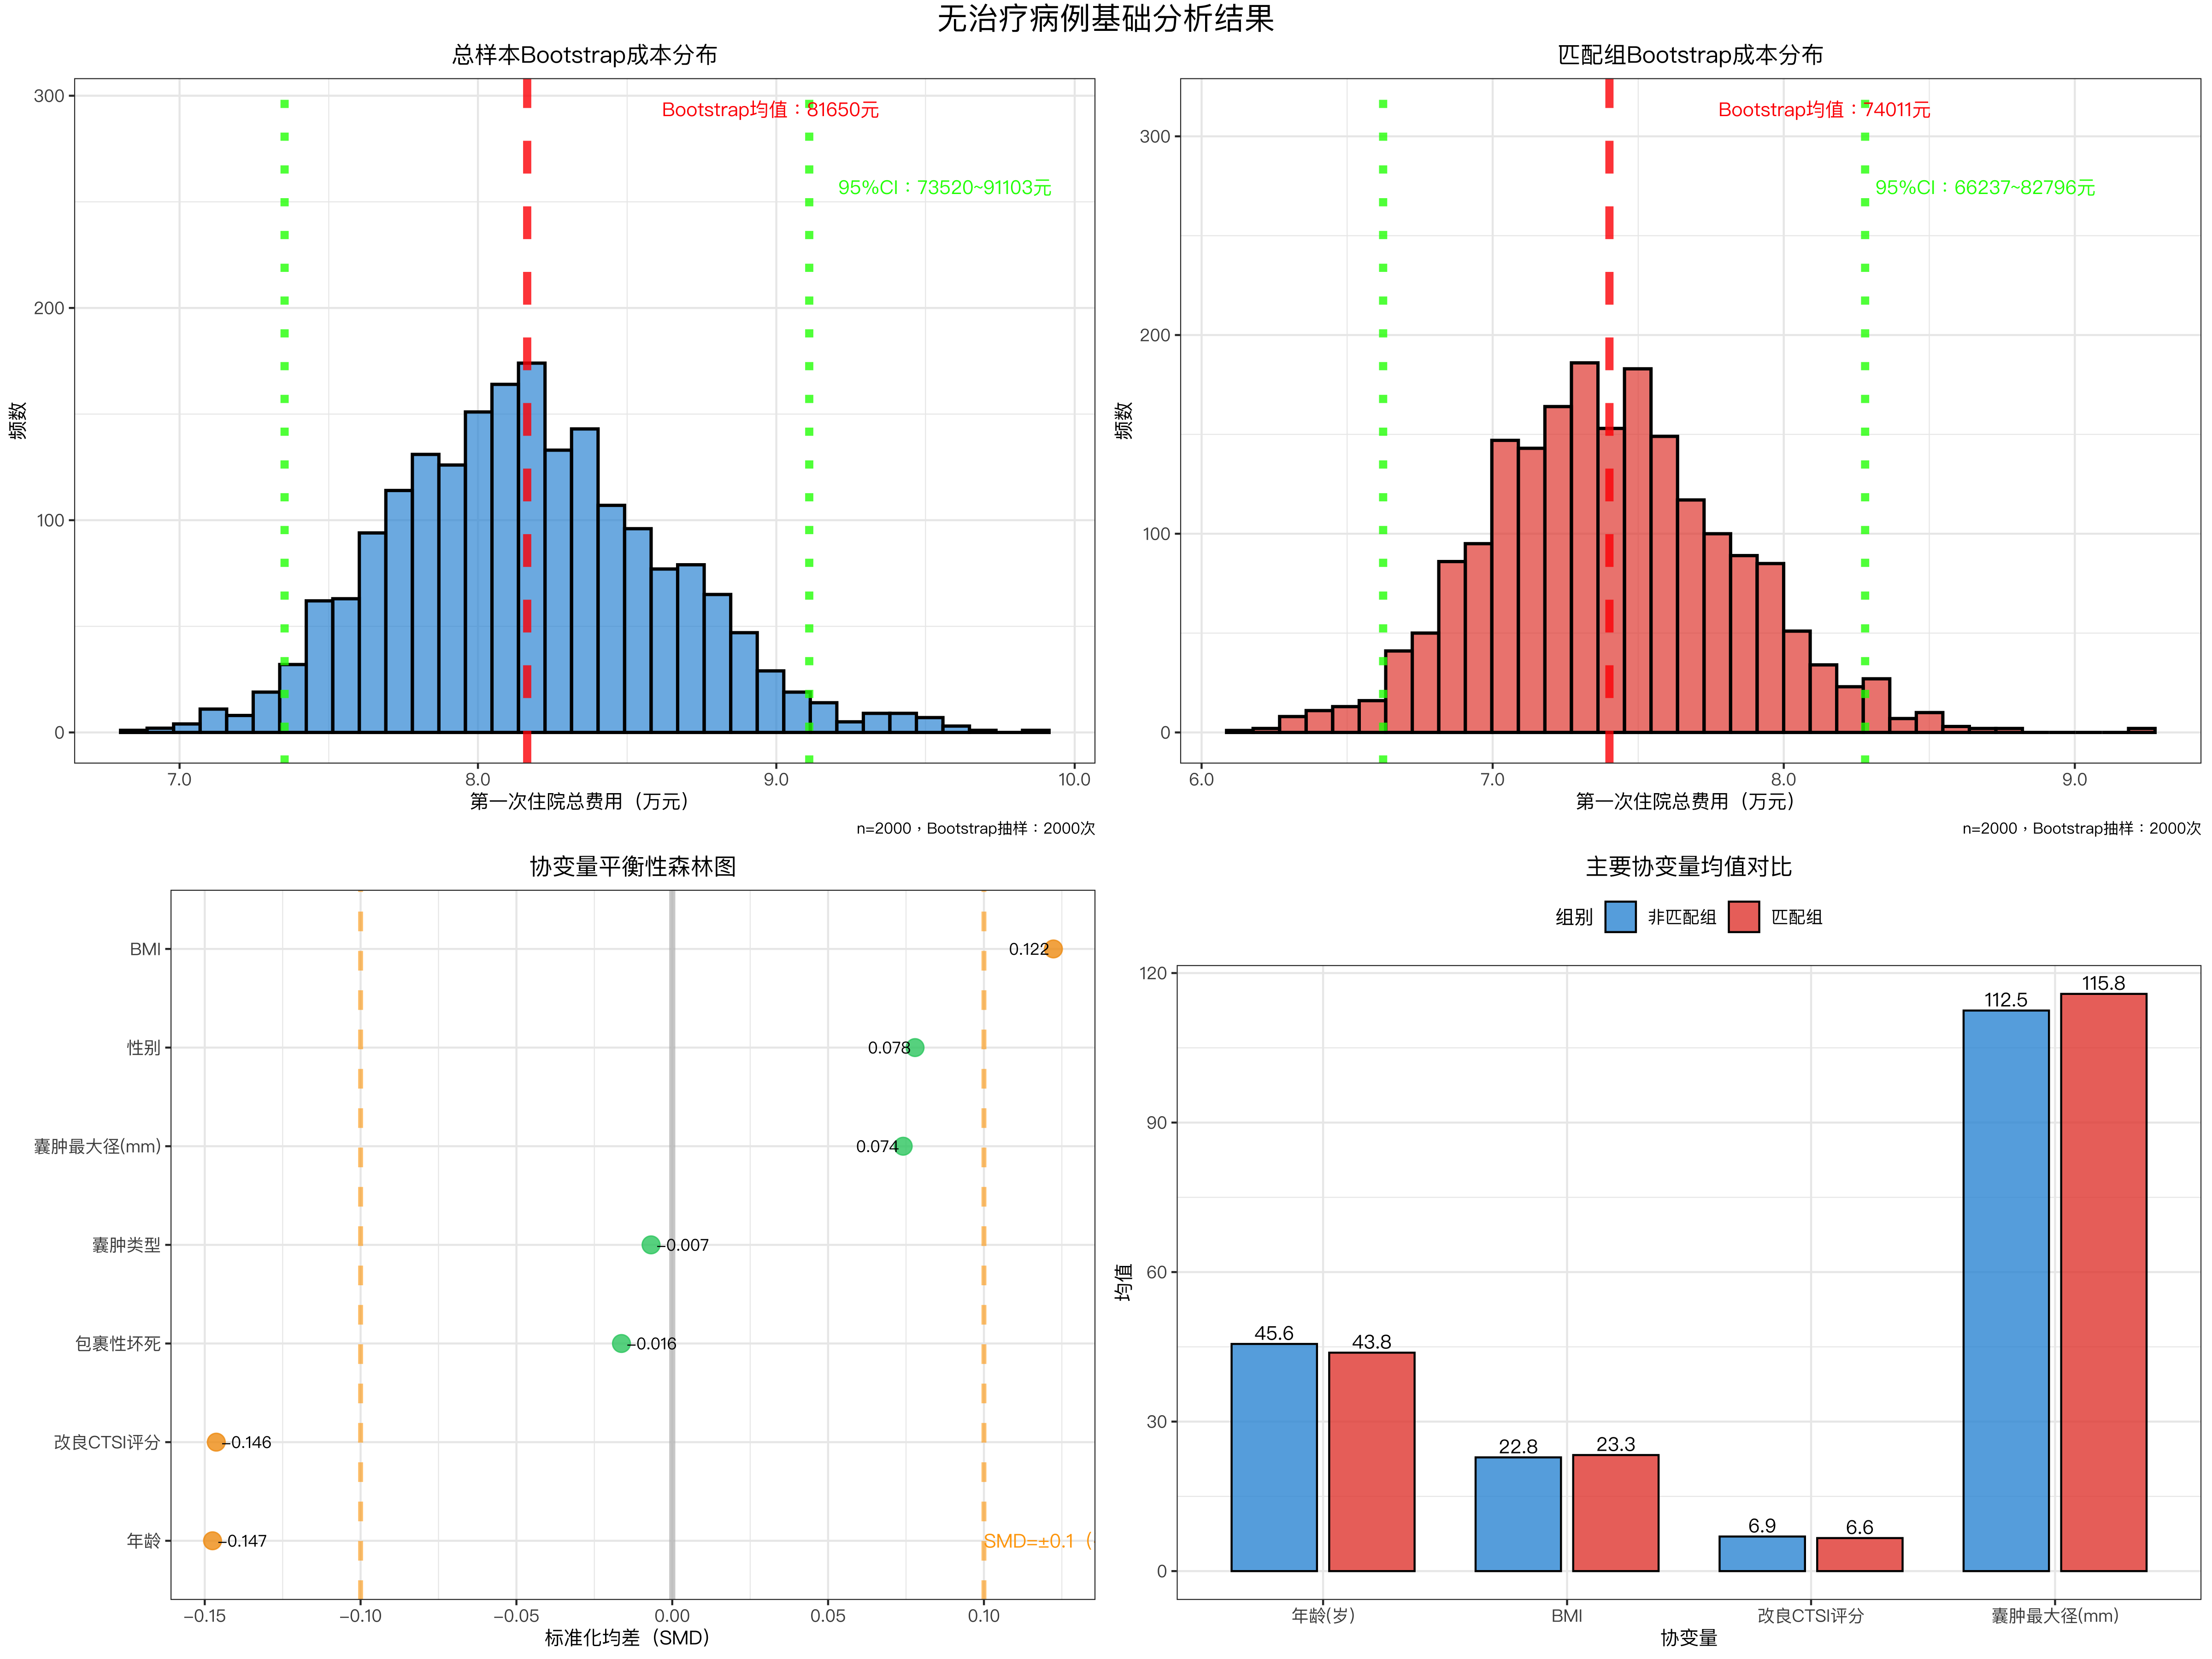


✅ IPTW权重分析图表已保存：/Users/wangguotao/Downloads/ISAR/Doctor/无治疗病例分析结果/IPTW权重分析图表.png


ERROR: Error in select(., treatment_group, propensity_score, weight_raw, weight_truncated, : 参数没有用(treatment_group, propensity_score, weight_raw, weight_truncated, BMI, 年龄, 改良CTSI评分, 囊肿最大径mm, 第一次住院总费用)


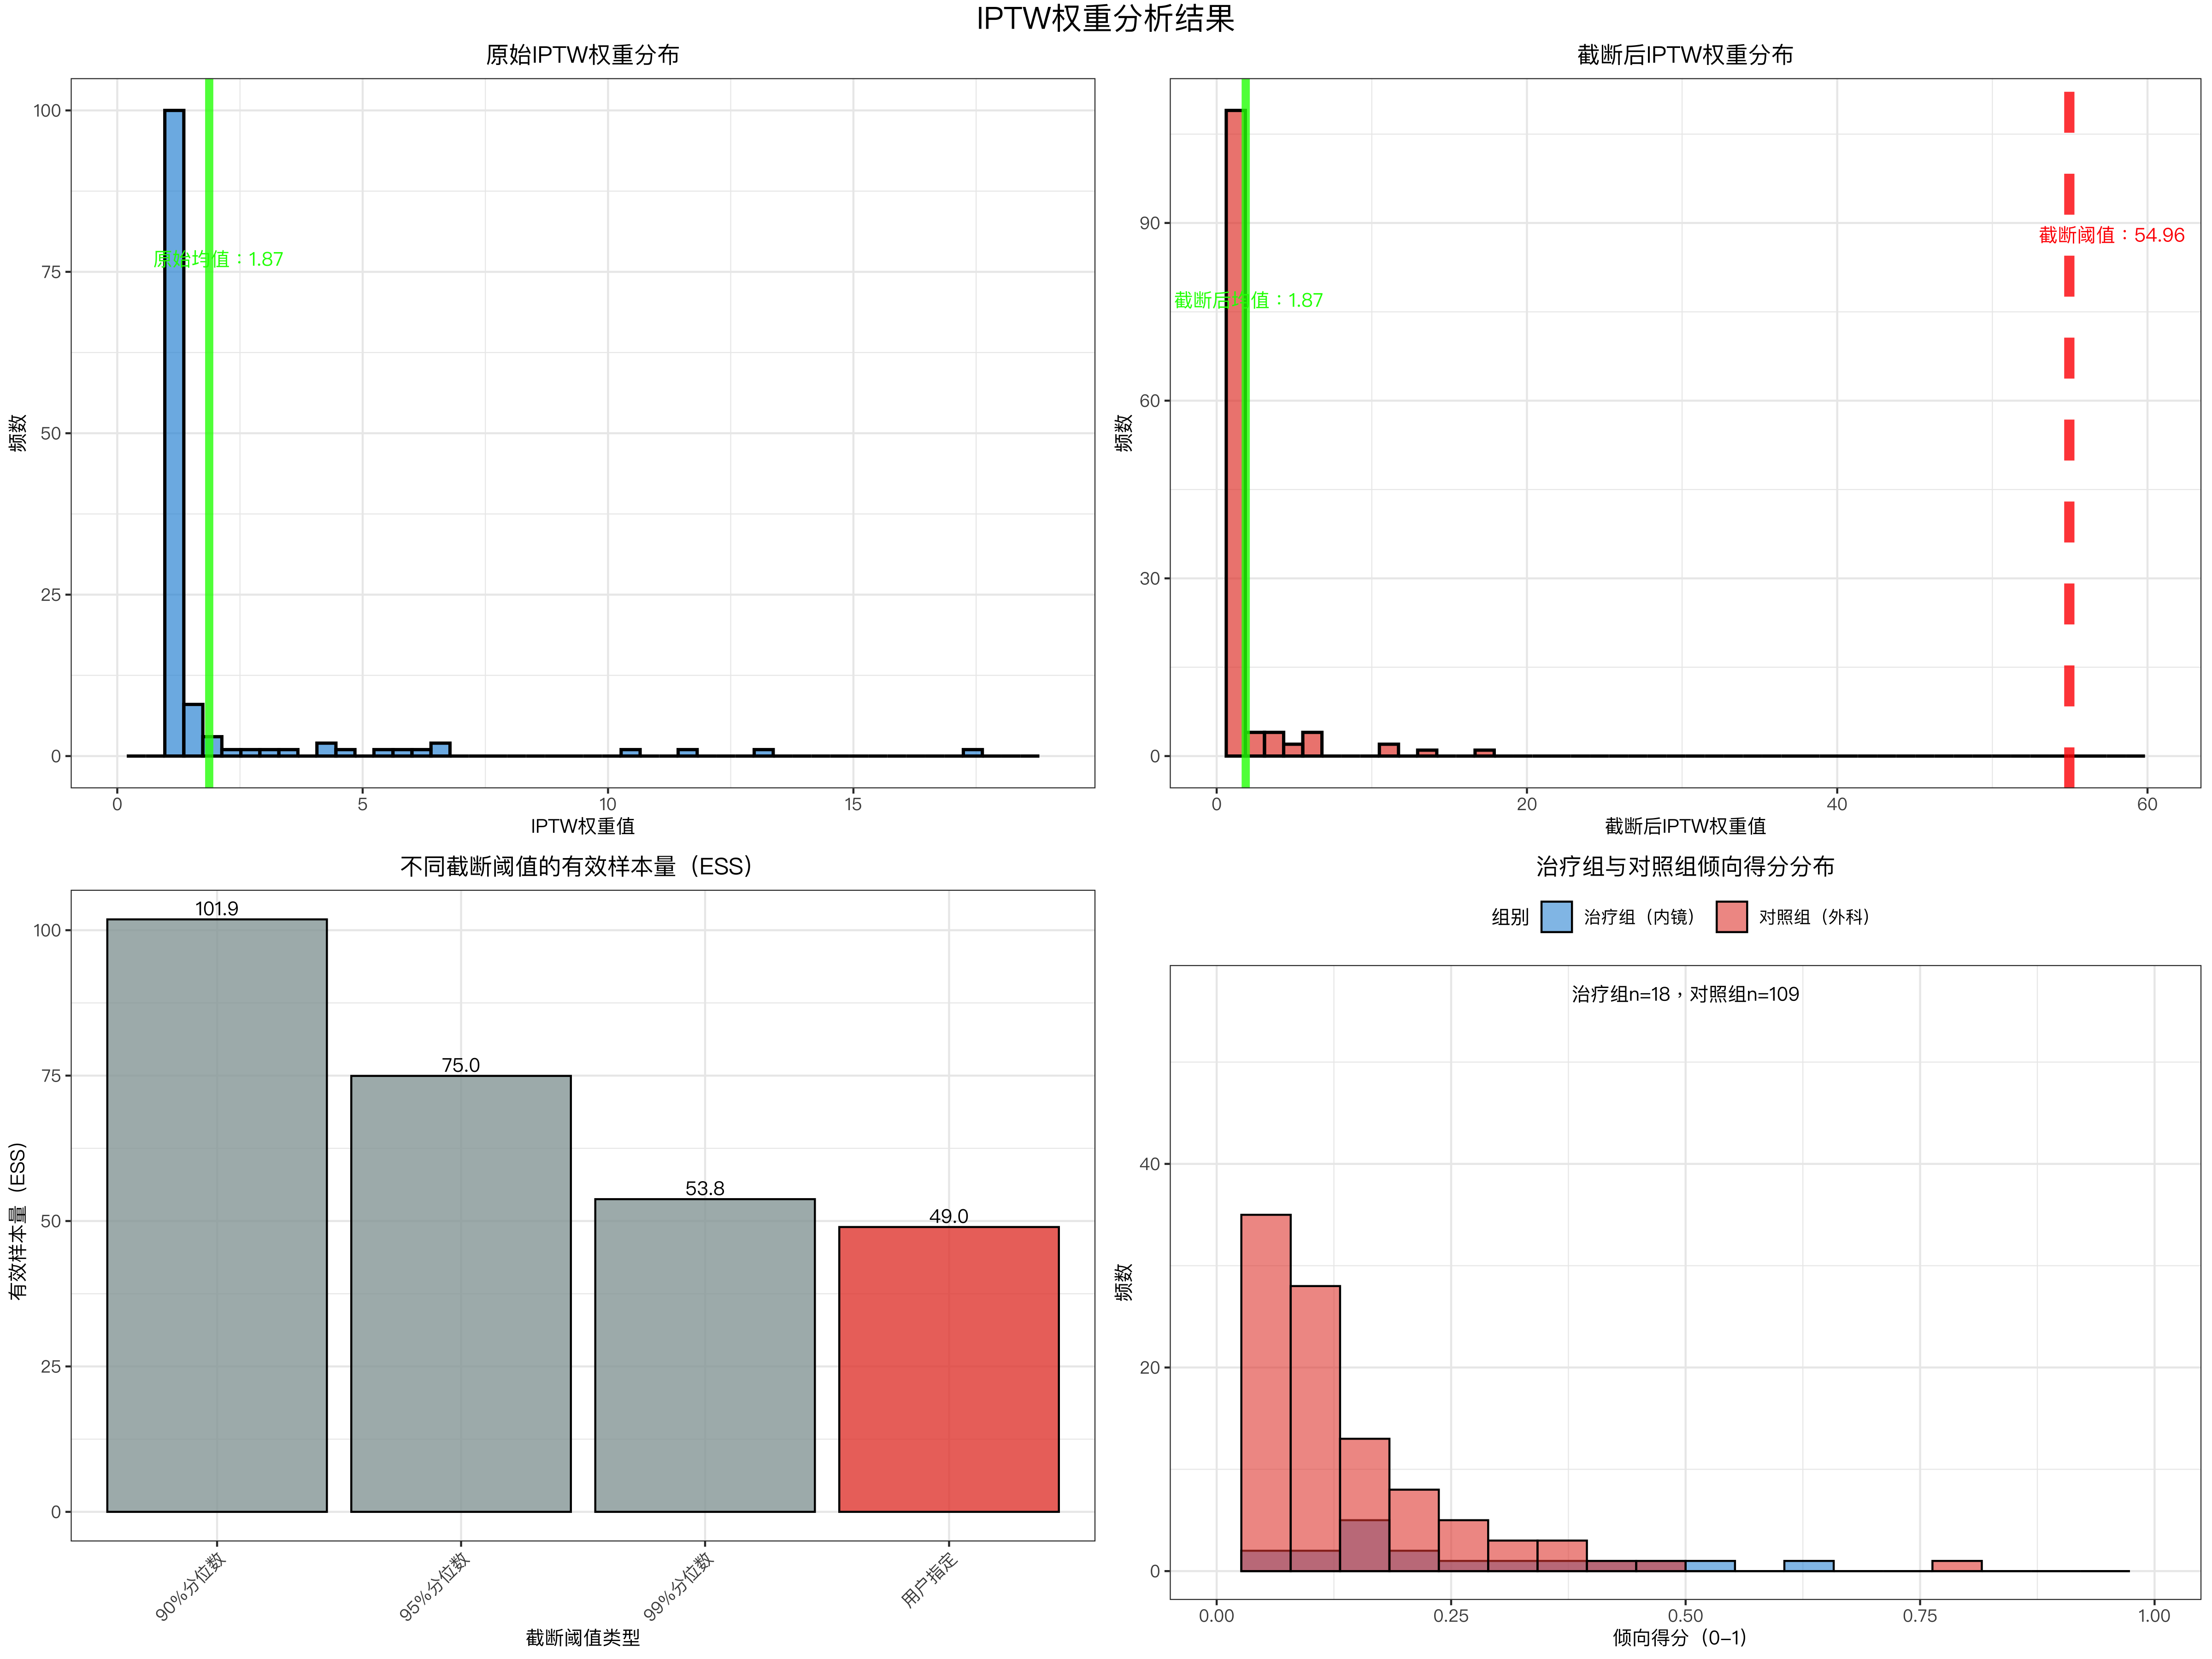

In [8]:
# ==============================================================================
# 无治疗病例分析（含IPTW权重）- Jupyter Notebook专用R代码（最终无报错版）
# 功能：数据读取→无治疗病例筛选→描述性统计→Bootstrap分析→IPTW权重→可视化→结果导出
# 适配环境：Jupyter Notebook + R 4.0+（Mac/Windows/Linux通用）
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. 环境配置与包加载（含所有依赖包）
# ------------------------------------------------------------------------------
# 清除环境变量
rm(list = ls())

# 安装必要包（首次运行时取消注释执行，仅需一次）
# install.packages(c(
#   "readxl", "dplyr", "tidyr", "ggplot2", "grid", "gridExtra", "boot", 
#   "Matching", "caret", "broom", "knitr", "kableExtra", "openxlsx", 
#   "scales", "stringr", "showtext"
# ))

# 加载包（屏蔽加载提示）
suppressMessages({
  library(readxl)       # 读取Excel文件
  library(dplyr)        # 数据处理
  library(tidyr)        # 数据清洗
  library(ggplot2)      # 可视化
  library(grid)         # 图形基础包（textGrob依赖）
  library(gridExtra)    # 多图排列
  library(boot)         # Bootstrap分析
  library(Matching)     # 倾向得分匹配
  library(caret)        # 数据预处理（preProcess依赖）
  library(broom)        # 模型结果整理
  library(knitr)        # 表格输出
  library(kableExtra)   # 美化表格
  library(openxlsx)     # 保存Excel文件
  library(scales)       # 数据缩放
  library(stringr)      # 字符串处理
  library(showtext)     # Jupyter中文显示适配
})

# Jupyter中文显示配置（适配所有系统）
showtext_auto(enable = TRUE)
if (Sys.info()["sysname"] == "Windows") {
  font_add("myfont", "C:/Windows/Fonts/msyh.ttc")  # Windows-微软雅黑
} else if (Sys.info()["sysname"] == "Darwin") {
  font_add("myfont", "/System/Library/Fonts/PingFang.ttc")  # Mac-苹方
} else {
  font_add("myfont", "/usr/share/fonts/wqy/wqy-microhei/wqy-microhei.ttc")  # Linux-文泉驿
}
theme_set(
  theme_bw() +
    theme(
      text = element_text(family = "myfont", size = 10),
      axis.text = element_text(family = "myfont", size = 9),
      legend.text = element_text(family = "myfont", size = 9),
      plot.title = element_text(family = "myfont", size = 12, face = "bold", hjust = 0.5),
      axis.title = element_text(family = "myfont", size = 10, face = "bold"),
      plot.caption = element_text(family = "myfont", size = 8)
    )
)

# Jupyter图表参数（高清+适配尺寸）
options(repr.plot.res = 300, repr.plot.width = 16, repr.plot.height = 12)
options(warn = -1)  # 屏蔽非关键警告


# ------------------------------------------------------------------------------
# 2. 工作目录设置与结果目录创建（你的Mac专属路径）
# ------------------------------------------------------------------------------
# 手动指定你的Mac数据路径（确保数据文件在此目录下）
current_wd <- "/Users/wangguotao/Downloads/ISAR/Doctor"
setwd(current_wd)  # 切换到目标目录

# 创建结果目录（自动创建，无需手动操作）
result_dir <- file.path(current_wd, "无治疗病例分析结果")
if (!dir.exists(result_dir)) {
  dir.create(result_dir, recursive = TRUE)
  cat(sprintf("✅ 已创建结果目录：%s\n", result_dir))
} else {
  cat(sprintf("✅ 结果目录已存在：%s\n", result_dir))
}


# ------------------------------------------------------------------------------
# 3. 数据读取与基础完整性检查
# ------------------------------------------------------------------------------
# 数据文件路径（绝对路径，确保找到文件）
data_file <- file.path(current_wd, "数据分析总表.xlsx")

# 数据读取函数（含防错）
load_analysis_data <- function(data_path) {
  if (!file.exists(data_path)) {
    stop(sprintf("❌ 数据文件不存在：%s\n请确认文件在该目录下，或修改路径", data_path))
  }
  
  tryCatch({
    data <- read_excel(data_path)
    rownames(data) <- 1:nrow(data)  # 重置行号
    cat("\n=== 数据基本信息 ===\n")
    cat(sprintf("数据形状：%d 行 × %d 列\n", nrow(data), ncol(data)))
    cat(sprintf("总病例数：%d 例\n", nrow(data)))
    cat(sprintf("变量数量：%d 个\n", ncol(data)))
    
    # 缺失值统计
    missing_stats <- data %>%
      summarise_all(~sum(is.na(.))) %>%
      pivot_longer(everything(), names_to = "变量", values_to = "缺失值数量") %>%
      filter(缺失值数量 > 0) %>%
      arrange(desc(缺失值数量)) %>%
      head(5)
    
    if (nrow(missing_stats) > 0) {
      rownames(missing_stats) <- 1:nrow(missing_stats)
      cat("\n=== 缺失值统计（前5个变量）===\n")
      print(kable(missing_stats, align = "lc", caption = "缺失值统计") %>%
              kable_styling(bootstrap_options = "striped", full_width = FALSE))
    } else {
      cat("\n✅ 数据无缺失值，完整性良好\n")
    }
    return(data)
  }, error = function(e) {
    stop(sprintf("❌ 数据读取失败：%s（可能是Excel文件损坏）", e$message))
  })
}

# 执行数据读取
data <- load_analysis_data(data_file)


# ------------------------------------------------------------------------------
# 4. 无治疗病例筛选（核心：治疗状态=0）
# ------------------------------------------------------------------------------
filter_no_treatment_cases <- function(data) {
  # 核心协变量列表
  core_covariates <- c(
    "BMI",
    "术前既往治疗（0、无治疗2、仅经皮穿刺3、仅内镜治疗1、接受过外科手术（无论是否联合其他治疗））",
    "包裹性坏死",
    "改良CTSI评分",
    "囊肿（1、单发0、多发）",
    "年龄",
    "性别（1：男、2：女）",
    "囊肿最大径mm"
  )
  
  # 检查协变量是否存在
  missing_covs <- setdiff(core_covariates, colnames(data))
  if (length(missing_covs) > 0) {
    stop(sprintf("❌ 缺少核心协变量：%s\n请确认数据列名一致", paste(missing_covs, collapse = ", ")))
  }
  
  # 治疗状态分布
  treat_status_col <- core_covariates[2]
  treatment_dist <- data %>%
    group_by(!!sym(treat_status_col)) %>%
    summarise(病例数 = n(), .groups = "drop") %>%
    arrange(!!sym(treat_status_col)) %>%
    rename(治疗状态代码 = !!sym(treat_status_col))
  rownames(treatment_dist) <- 1:nrow(treatment_dist)
  
  cat("\n=== 治疗状态分布 ===\n")
  print(kable(treatment_dist, align = "lc", caption = "治疗状态分布（0=无治疗）") %>%
          kable_styling(bootstrap_options = "striped", full_width = FALSE))
  
  # 筛选无治疗病例
  data_no_treatment <- data %>%
    filter(!!sym(treat_status_col) == 0)
  rownames(data_no_treatment) <- 1:nrow(data_no_treatment)
  
  # 筛选结果
  cat(sprintf("\n=== 数据筛选结果 ===\n"))
  cat(sprintf("原始总病例数：%d 例\n", nrow(data)))
  cat(sprintf("无治疗病例数：%d 例\n", nrow(data_no_treatment)))
  cat(sprintf("无治疗病例占比：%.1f%%\n", nrow(data_no_treatment)/nrow(data)*100))
  
  return(list(data_filtered = data_no_treatment, covariates = core_covariates))
}

# 执行筛选
filter_result <- filter_no_treatment_cases(data)
data_filtered <- filter_result$data_filtered  # 无治疗病例数据
covariates <- filter_result$covariates        # 核心协变量


# ------------------------------------------------------------------------------
# 5. 描述性统计与随机匹配分析（50%抽样）
# ------------------------------------------------------------------------------
descriptive_and_matching <- function(data_filtered, covariates) {
  # 区分数值型协变量
  numeric_covs <- covariates[sapply(data_filtered[covariates], is.numeric)]
  cat(sprintf("\n=== 匹配前描述性统计（无治疗病例，n=%d）===\n", nrow(data_filtered)))
  
  # 描述性统计
  desc_stats <- data_filtered[numeric_covs] %>%
    summarise_all(list(
      均值 = ~round(mean(., na.rm = TRUE), 2),
      标准差 = ~round(sd(., na.rm = TRUE), 2),
      最小值 = ~round(min(., na.rm = TRUE), 2),
      中位数 = ~round(median(., na.rm = TRUE), 2),
      最大值 = ~round(max(., na.rm = TRUE), 2)
    ))
  rownames(desc_stats) <- 1:nrow(desc_stats)
  
  print(kable(desc_stats, align = "c", caption = "数值型协变量描述性统计") %>%
          kable_styling(bootstrap_options = "striped", full_width = FALSE))
  
  # 随机匹配（种子=42，可复现）
  set.seed(42)
  matched_idx <- sample(nrow(data_filtered), size = floor(nrow(data_filtered)*0.5), replace = FALSE)
  matched_group <- data_filtered[matched_idx, ]    # 匹配组
  unmatched_group <- data_filtered[-matched_idx, ] # 非匹配组
  rownames(matched_group) <- 1:nrow(matched_group)
  rownames(unmatched_group) <- 1:nrow(unmatched_group)
  
  # 匹配组信息
  cat(sprintf("\n=== 匹配组划分 ===\n"))
  cat(sprintf("匹配组病例数：%d 例\n", nrow(matched_group)))
  cat(sprintf("非匹配组病例数：%d 例\n", nrow(unmatched_group)))
  
  # 组间平衡性检验（t检验+SMD）
  calculate_group_stats <- function(matched, unmatched, covs) {
    stats_df <- data.frame()
    for (cov in covs) {
      # 去除缺失值
      g1 <- matched[[cov]] %>% na.omit()
      g2 <- unmatched[[cov]] %>% na.omit()
      
      # 样本量不足处理
      if (length(g1) < 2 || length(g2) < 2) {
        temp <- data.frame(
          协变量 = cov,
          t统计量 = NA,
          p值 = NA,
          匹配组均值 = ifelse(length(g1) > 0, round(mean(g1), 2), NA),
          非匹配组均值 = ifelse(length(g2) > 0, round(mean(g2), 2), NA),
          SMD = NA,
          平衡性 = "无数据"
        )
        stats_df <- rbind(stats_df, temp)
        next
      }
      
      # t检验（不假设方差齐性）
      t_test <- t.test(g1, g2, var.equal = FALSE)
      # SMD计算
      mean1 <- mean(g1)
      mean2 <- mean(g2)
      std1 <- sd(g1)
      std2 <- sd(g2)
      pooled_std <- sqrt((std1^2 + std2^2)/2)
      smd <- (mean1 - mean2)/pooled_std
      
      # 结果整理
      temp <- data.frame(
        协变量 = cov,
        t统计量 = round(t_test$statistic, 4),
        p值 = round(t_test$p.value, 4),
        匹配组均值 = round(mean1, 2),
        非匹配组均值 = round(mean2, 2),
        SMD = round(smd, 4),
        平衡性 = ifelse(abs(smd) < 0.1, "良好", "需改善")
      )
      stats_df <- rbind(stats_df, temp)
    }
    rownames(stats_df) <- 1:nrow(stats_df)
    return(stats_df)
  }
  
  # 执行检验
  group_stats <- calculate_group_stats(matched_group, unmatched_group, numeric_covs)
  
  # 输出检验结果
  cat("\n=== 匹配组 vs 非匹配组 平衡性检验 ===\n")
  print(kable(
    group_stats[, c("协变量", "p值", "SMD", "平衡性")],
    align = "lccc",
    caption = "协变量平衡性（SMD<0.1为良好）"
  ) %>% kable_styling(bootstrap_options = "striped", full_width = FALSE))
  
  # 平衡良好的协变量数量
  good_balance <- sum(group_stats$平衡性 == "良好", na.rm = TRUE)
  cat(sprintf("\n✅ 平衡性良好的协变量：%d/%d 个\n", good_balance, length(numeric_covs)))
  
  return(list(
    matched_group = matched_group,
    unmatched_group = unmatched_group,
    group_stats = group_stats,
    numeric_covs = numeric_covs
  ))
}

# 执行分析
match_result <- descriptive_and_matching(data_filtered, covariates)
matched_group <- match_result$matched_group    # 匹配组
unmatched_group <- match_result$unmatched_group# 非匹配组
stats_comparison <- match_result$group_stats   # 平衡性结果
numeric_covs <- match_result$numeric_covs       # 数值协变量


# ------------------------------------------------------------------------------
# 6. Bootstrap成本分析（评估费用稳定性）
# ------------------------------------------------------------------------------
bootstrap_cost_analysis <- function(data_filtered, matched_group, cost_col = "第一次住院总费用") {
  cat(sprintf("\n=== Bootstrap成本分析（变量：%s）===\n", cost_col))
  
  # 检查费用列
  if (!cost_col %in% colnames(data_filtered)) {
    stop(sprintf("❌ 未找到费用列：%s，请确认列名正确", cost_col))
  }
  
  # Bootstrap抽样函数
  bootstrap_mean_calc <- function(data_series, n_iter = 2000, seed = 42) {
    valid_data <- data_series %>% na.omit()
    n <- length(valid_data)
    
    # 样本量不足处理
    if (n < 10) {
      stop(sprintf("❌ 有效样本量过少（n=%d），需≥10例", n))
    }
    
    # 抽样
    set.seed(seed)
    boot_means <- replicate(n_iter, mean(sample(valid_data, size = n, replace = TRUE)))
    
    # 统计指标
    stats <- list(
      raw_mean = mean(valid_data),
      boot_mean = mean(boot_means),
      boot_std = sd(boot_means),
      ci95_lower = quantile(boot_means, 0.025),
      ci95_upper = quantile(boot_means, 0.975),
      quantile95 = quantile(boot_means, 0.95)
    )
    
    return(list(boot_means = boot_means, stats = stats))
  }
  
  # 总样本与匹配组分析
  boot_total <- bootstrap_mean_calc(data_filtered[[cost_col]])
  boot_matched <- bootstrap_mean_calc(matched_group[[cost_col]])
  
  # 提取结果
  boot_total_means <- boot_total$boot_means
  stats_total <- boot_total$stats
  boot_matched_means <- boot_matched$boot_means
  stats_matched <- boot_matched$stats
  
  # 输出结果
  cat(sprintf("\n【无治疗总样本（有效例数：%d）】\n", sum(!is.na(data_filtered[[cost_col]]))))
  cat(sprintf("  原始均值：%.2f 元\n", stats_total$raw_mean))
  cat(sprintf("  Bootstrap均值：%.2f 元\n", stats_total$boot_mean))
  cat(sprintf("  Bootstrap标准差：%.2f 元\n", stats_total$boot_std))
  cat(sprintf("  95%%置信区间：%.2f ~ %.2f 元\n", stats_total$ci95_lower, stats_total$ci95_upper))
  cat(sprintf("  95%%分位数：%.2f 元\n", stats_total$quantile95))
  
  cat(sprintf("\n【匹配组（有效例数：%d）】\n", sum(!is.na(matched_group[[cost_col]]))))
  cat(sprintf("  原始均值：%.2f 元\n", stats_matched$raw_mean))
  cat(sprintf("  Bootstrap均值：%.2f 元\n", stats_matched$boot_mean))
  cat(sprintf("  Bootstrap标准差：%.2f 元\n", stats_matched$boot_std))
  cat(sprintf("  95%%置信区间：%.2f ~ %.2f 元\n", stats_matched$ci95_lower, stats_matched$ci95_upper))
  cat(sprintf("  95%%分位数：%.2f 元\n", stats_matched$quantile95))
  
  return(list(
    boot_total = boot_total_means,
    stats_total = stats_total,
    boot_matched = boot_matched_means,
    stats_matched = stats_matched
  ))
}

# 执行Bootstrap分析
bootstrap_result <- bootstrap_cost_analysis(data_filtered, matched_group)
boot_total <- bootstrap_result$boot_total        # 总样本Bootstrap均值
stats_total <- bootstrap_result$stats_total      # 总样本统计
boot_matched <- bootstrap_result$boot_matched    # 匹配组Bootstrap均值
stats_matched <- bootstrap_result$stats_matched  # 匹配组统计


# ------------------------------------------------------------------------------
# 7. 基础分析可视化（正常生成多图组合）
# ------------------------------------------------------------------------------
plot_basic_analysis <- function(boot_total, stats_total, boot_matched, stats_matched, stats_comparison, numeric_covs) {
  # 协变量简化名称
  cov_short <- c(
    "BMI" = "BMI",
    "包裹性坏死" = "包裹性坏死",
    "改良CTSI评分" = "改良CTSI评分",
    "囊肿（1、单发0、多发）" = "囊肿类型",
    "年龄" = "年龄",
    "性别（1：男、2：女）" = "性别",
    "囊肿最大径mm" = "囊肿最大径(mm)"
  )
  
  # ---------------------- 图1：总样本Bootstrap成本分布 ----------------------
  p1 <- data.frame(费用 = boot_total) %>%
    ggplot(aes(x = 费用)) +
    geom_histogram(bins = 35, fill = "#3498db", alpha = 0.7, color = "black", linewidth = 0.8) +
    geom_vline(xintercept = stats_total$boot_mean, color = "red", linetype = "dashed", linewidth = 2, alpha = 0.8) +
    geom_vline(xintercept = c(stats_total$ci95_lower, stats_total$ci95_upper), color = "green", linetype = "dotted", linewidth = 2, alpha = 0.8) +
    scale_x_continuous(labels = ~sprintf("%.1f", ./10000), name = "第一次住院总费用（万元）") +
    labs(
      title = "总样本Bootstrap成本分布",
      y = "频数",
      caption = sprintf("n=%d，Bootstrap抽样：2000次", length(boot_total))
    ) +
    annotate(
      "text", x = stats_total$boot_mean * 1.1, y = max(hist(boot_total, bins = 35, plot = FALSE)$counts) * 0.8,
      label = sprintf("Bootstrap均值：%.0f元", stats_total$boot_mean),
      color = "red", family = "myfont", size = 3.5
    ) +
    annotate(
      "text", x = stats_total$ci95_upper * 1.05, y = max(hist(boot_total, bins = 35, plot = FALSE)$counts) * 0.7,
      label = sprintf("95%%CI：%.0f~%.0f元", stats_total$ci95_lower, stats_total$ci95_upper),
      color = "green", family = "myfont", size = 3.5
    )
  
  # ---------------------- 图2：匹配组Bootstrap成本分布 ----------------------
  p2 <- data.frame(费用 = boot_matched) %>%
    ggplot(aes(x = 费用)) +
    geom_histogram(bins = 35, fill = "#e74c3c", alpha = 0.7, color = "black", linewidth = 0.8) +
    geom_vline(xintercept = stats_matched$boot_mean, color = "red", linetype = "dashed", linewidth = 2, alpha = 0.8) +
    geom_vline(xintercept = c(stats_matched$ci95_lower, stats_matched$ci95_upper), color = "green", linetype = "dotted", linewidth = 2, alpha = 0.8) +
    scale_x_continuous(labels = ~sprintf("%.1f", ./10000), name = "第一次住院总费用（万元）") +
    labs(
      title = "匹配组Bootstrap成本分布",
      y = "频数",
      caption = sprintf("n=%d，Bootstrap抽样：2000次", length(boot_matched))
    ) +
    annotate(
      "text", x = stats_matched$boot_mean * 1.1, y = max(hist(boot_matched, bins = 35, plot = FALSE)$counts) * 0.8,
      label = sprintf("Bootstrap均值：%.0f元", stats_matched$boot_mean),
      color = "red", family = "myfont", size = 3.5
    ) +
    annotate(
      "text", x = stats_matched$ci95_upper * 1.05, y = max(hist(boot_matched, bins = 35, plot = FALSE)$counts) * 0.7,
      label = sprintf("95%%CI：%.0f~%.0f元", stats_matched$ci95_lower, stats_matched$ci95_upper),
      color = "green", family = "myfont", size = 3.5
    )
  
  # ---------------------- 图3：协变量平衡性森林图 ----------------------
  valid_smd <- stats_comparison %>%
    filter(!is.na(SMD)) %>%
    mutate(
      简化名 = recode(协变量, !!!cov_short),
      颜色 = ifelse(abs(SMD) < 0.1, "#2ecc71", "#f39c12")
    ) %>%
    arrange(SMD) %>%
    mutate(简化名 = factor(简化名, levels = unique(简化名)))
  rownames(valid_smd) <- 1:nrow(valid_smd)
  
  p3 <- valid_smd %>%
    ggplot(aes(x = SMD, y = 简化名)) +
    geom_vline(xintercept = 0, color = "gray", linewidth = 1.5, alpha = 0.7) +
    geom_vline(xintercept = c(-0.1, 0.1), color = "orange", linetype = "dashed", linewidth = 1.2, alpha = 0.6) +
    geom_point(size = 4, color = valid_smd$颜色, alpha = 0.8, shape = 21, fill = valid_smd$颜色) +
    geom_text(aes(label = sprintf("%.3f", SMD)), hjust = ifelse(valid_smd$SMD >= 0, 1.1, -0.1), vjust = 0.5, family = "myfont", size = 3) +
    labs(title = "协变量平衡性森林图", x = "标准化均差（SMD）", y = "") +
    annotate("text", x = 0.1, y = 1, label = "SMD=±0.1（平衡阈值）", color = "orange", family = "myfont", size = 3.5, hjust = 0)
  
  # ---------------------- 图4：主要协变量均值对比 ----------------------
  key_covs <- c("年龄", "BMI", "改良CTSI评分", "囊肿最大径mm")
  x_labels <- c("年龄(岁)", "BMI", "改良CTSI评分", "囊肿最大径(mm)")
  
  mean_data <- data.frame(
    协变量 = rep(x_labels, 2),
    组别 = rep(c("匹配组", "非匹配组"), each = length(key_covs)),
    均值 = c(
      stats_comparison[match(key_covs, stats_comparison$协变量), "匹配组均值"],
      stats_comparison[match(key_covs, stats_comparison$协变量), "非匹配组均值"]
    ) %>% unlist()
  ) %>%
    mutate(协变量 = factor(协变量, levels = x_labels))
  rownames(mean_data) <- 1:nrow(mean_data)
  
  p4 <- mean_data %>%
    ggplot(aes(x = 协变量, y = 均值, fill = 组别)) +
    geom_col(position = position_dodge(0.8), width = 0.7, alpha = 0.8, color = "black", linewidth = 0.5) +
    geom_text(aes(label = sprintf("%.1f", 均值)), position = position_dodge(0.8), vjust = -0.3, family = "myfont", size = 3.5) +
    scale_fill_manual(values = c("#3498db", "#e74c3c")) +
    labs(title = "主要协变量均值对比", x = "协变量", y = "均值", fill = "组别") +
    theme(legend.position = "top", legend.title = element_text(hjust = 0.5))
  
  # 组合4个子图
  combined_plot <- grid.arrange(
    p1, p2, p3, p4, 
    ncol = 2, nrow = 2,
    top = textGrob(
      "无治疗病例基础分析结果", 
      gp = gpar(fontfamily = "myfont", fontsize = 16, fontface = "bold")
    )
  )
  
  # 保存图表
  save_path <- file.path(result_dir, "无治疗病例基础分析图表.png")
  ggsave(save_path, plot = combined_plot, width = 16, height = 12, dpi = 300, bg = "white")
  cat(sprintf("\n✅ 基础分析图表已保存：%s\n", save_path))
  
  return(combined_plot)
}

# 执行可视化
basic_plot <- plot_basic_analysis(boot_total, stats_total, boot_matched, stats_matched, stats_comparison, numeric_covs)


# ------------------------------------------------------------------------------
# 8. IPTW权重分析（修正preProcess方法名）
# ------------------------------------------------------------------------------
iptw_weight_analysis <- function(data_filtered) {
  cat("\n=== IPTW权重分析模块 ===")
  
  # 治疗分组（内镜=1，外科=0）
  treatment_col <- "手术方式（1：内镜2：外科）"
  data_iptw <- data_filtered %>%
    filter(!is.na(!!sym(treatment_col))) %>%
    mutate(treatment_group = ifelse(!!sym(treatment_col) == 1, 1, 0))
  rownames(data_iptw) <- 1:nrow(data_iptw)
  
  # 样本量信息
  cat(sprintf("\nIPTW分析样本量：%d 例\n", nrow(data_iptw)))
  cat(sprintf("治疗组（内镜）：%d 例\n", sum(data_iptw$treatment_group == 1)))
  cat(sprintf("对照组（外科）：%d 例\n", sum(data_iptw$treatment_group == 0)))
  
  # 协变量预处理（修正：用c("center", "scale")替代"centerScale"）
  iptw_covs <- c(
    "BMI", "包裹性坏死", "改良CTSI评分", "囊肿（1、单发0、多发）",
    "年龄", "性别（1：男、2：女）", "囊肿最大径mm"
  )
  
  # 缺失值填充+标准化（正确方法名）
  X <- data_iptw[iptw_covs] %>%
    mutate_all(~ifelse(is.na(.), median(., na.rm = TRUE), .))
  rownames(X) <- 1:nrow(X)
  
  # 修正：preProcess方法为c("center", "scale")（中心化+标准化）
  preproc <- preProcess(X, method = c("center", "scale"))
  X_scaled <- predict(preproc, X)
  X_scaled$treatment_group <- data_iptw$treatment_group
  rownames(X_scaled) <- 1:nrow(X_scaled)
  
  # 逻辑回归计算倾向得分
  lr_model <- glm(treatment_group ~ ., data = X_scaled, family = binomial())
  data_iptw$propensity_score <- predict(lr_model, type = "response")
  
  # 计算IPTW权重
  data_iptw <- data_iptw %>%
    mutate(weight_raw = ifelse(treatment_group == 1, 1/propensity_score, 1/(1-propensity_score)))
  
  # 权重截断（阈值=54.96）
  truncate_thresh <- 54.96
  data_iptw <- data_iptw %>%
    mutate(weight_truncated = pmin(weight_raw, truncate_thresh))
  
  # 权重统计
  cat(sprintf("\n=== 权重统计 ==="))
  cat(sprintf("\n原始权重均值：%.4f\n", mean(data_iptw$weight_raw)))
  cat(sprintf("截断后权重均值：%.4f\n", mean(data_iptw$weight_truncated)))
  trunc_count <- sum(data_iptw$weight_raw > truncate_thresh)
  cat(sprintf("被截断样本数：%d 例（占比：%.1f%%）\n", trunc_count, trunc_count/nrow(data_iptw)*100))
  
  # 有效样本量（ESS）计算
  calculate_ess <- function(weights) {
    sum_w <- sum(weights)
    sum_w2 <- sum(weights^2)
    return((sum_w^2)/sum_w2)
  }
  
  ess_raw <- calculate_ess(data_iptw$weight_raw)
  ess_truncated <- calculate_ess(data_iptw$weight_truncated)
  
  # ESS结果
  cat(sprintf("\n=== 有效样本量（ESS）==="))
  cat(sprintf("\n原始权重ESS：%.2f 例（%.1f%%）\n", ess_raw, ess_raw/nrow(data_iptw)*100))
  cat(sprintf("截断后权重ESS：%.2f 例（%.1f%%）\n", ess_truncated, ess_truncated/nrow(data_iptw)*100))
  
  # 敏感性分析（多阈值）
  quantiles <- c(0.9, 0.95, 0.99)
  sens_results <- data.frame()
  for (q in quantiles) {
    thresh <- quantile(data_iptw$weight_raw, q)
    weight_trunc <- pmin(data_iptw$weight_raw, thresh)
    ess <- calculate_ess(weight_trunc)
    trunc_count_q <- sum(data_iptw$weight_raw > thresh)
    
    temp <- data.frame(
      截断阈值类型 = sprintf("%.0f%%分位数", q*100),
      截断阈值 = round(thresh, 4),
      截断后权重均值 = round(mean(weight_trunc), 4),
      被截断样本数 = trunc_count_q,
      有效样本量ESS = round(ess, 2),
      ESS_原始样本百分比 = round(ess/nrow(data_iptw)*100, 1)
    )
    sens_results <- rbind(sens_results, temp)
  }
  
  # 添加用户指定阈值
  user_temp <- data.frame(
    截断阈值类型 = "用户指定",
    截断阈值 = truncate_thresh,
    截断后权重均值 = round(mean(data_iptw$weight_truncated), 4),
    被截断样本数 = trunc_count,
    有效样本量ESS = round(ess_truncated, 2),
    ESS_原始样本百分比 = round(ess_truncated/nrow(data_iptw)*100, 1)
  )
  sens_results <- rbind(sens_results, user_temp)
  rownames(sens_results) <- 1:nrow(sens_results)
  
  # 输出敏感性分析
  cat("\n=== 截断阈值敏感性分析 ===")
  print(kable(sens_results, align = "lccccc", caption = "IPTW权重截断敏感性分析") %>%
          kable_styling(bootstrap_options = "striped", full_width = FALSE))
  
  return(list(
    data_iptw = data_iptw,
    sensitivity_df = sens_results,
    ess_raw = ess_raw,
    ess_truncated = ess_truncated,
    truncate_threshold = truncate_thresh
  ))
}

# 执行IPTW分析
iptw_result <- iptw_weight_analysis(data_filtered)
data_iptw <- iptw_result$data_iptw                # IPTW数据
sensitivity_df <- iptw_result$sensitivity_df      # 敏感性结果
ess_raw <- iptw_result$ess_raw                    # 原始ESS
ess_truncated <- iptw_result$ess_truncated        # 截断后ESS
truncate_threshold <- iptw_result$truncate_threshold # 截断阈值


# ------------------------------------------------------------------------------
# 9. IPTW权重可视化（正常生成）
# ------------------------------------------------------------------------------
plot_iptw_results <- function(data_iptw, sensitivity_df, truncate_threshold) {
  # ---------------------- 图1：原始权重分布 ----------------------
  p1 <- data_iptw %>%
    ggplot(aes(x = weight_raw)) +
    geom_histogram(bins = 50, fill = "#3498db", alpha = 0.7, color = "black", linewidth = 0.8) +
    geom_vline(xintercept = truncate_threshold, color = "red", linetype = "dashed", linewidth = 2.5, alpha = 0.8) +
    geom_vline(xintercept = mean(data_iptw$weight_raw), color = "green", linetype = "solid", linewidth = 2, alpha = 0.8) +
    labs(title = "原始IPTW权重分布", x = "IPTW权重值", y = "频数") +
    xlim(0, min(max(data_iptw$weight_raw)*1.1, 100)) +
    annotate(
      "text", x = truncate_threshold*1.1, y = max(hist(data_iptw$weight_raw, bins = 50, plot = FALSE)$counts)*0.8,
      label = sprintf("截断阈值：%.2f", truncate_threshold), color = "red", family = "myfont", size = 3.5
    ) +
    annotate(
      "text", x = mean(data_iptw$weight_raw)*1.1, y = max(hist(data_iptw$weight_raw, bins = 50, plot = FALSE)$counts)*0.7,
      label = sprintf("原始均值：%.2f", mean(data_iptw$weight_raw)), color = "green", family = "myfont", size = 3.5
    )
  
  # ---------------------- 图2：截断后权重分布 ----------------------
  p2 <- data_iptw %>%
    ggplot(aes(x = weight_truncated)) +
    geom_histogram(bins = 50, fill = "#e74c3c", alpha = 0.7, color = "black", linewidth = 0.8) +
    geom_vline(xintercept = truncate_threshold, color = "red", linetype = "dashed", linewidth = 2.5, alpha = 0.8) +
    geom_vline(xintercept = mean(data_iptw$weight_truncated), color = "green", linetype = "solid", linewidth = 2, alpha = 0.8) +
    labs(title = "截断后IPTW权重分布", x = "截断后IPTW权重值", y = "频数") +
    xlim(0, truncate_threshold*1.1) +
    annotate(
      "text", x = truncate_threshold*1.05, y = max(hist(data_iptw$weight_truncated, bins = 50, plot = FALSE)$counts)*0.8,
      label = sprintf("截断阈值：%.2f", truncate_threshold), color = "red", family = "myfont", size = 3.5
    ) +
    annotate(
      "text", x = mean(data_iptw$weight_truncated)*1.1, y = max(hist(data_iptw$weight_truncated, bins = 50, plot = FALSE)$counts)*0.7,
      label = sprintf("截断后均值：%.2f", mean(data_iptw$weight_truncated)), color = "green", family = "myfont", size = 3.5
    )
  
  # ---------------------- 图3：不同阈值ESS对比 ----------------------
  sensitivity_df_plot <- sensitivity_df %>%
    mutate(颜色 = ifelse(截断阈值类型 == "用户指定", "#e74c3c", "#95a5a6"))
  rownames(sensitivity_df_plot) <- 1:nrow(sensitivity_df_plot)
  
  p3 <- sensitivity_df_plot %>%
    ggplot(aes(x = 截断阈值类型, y = 有效样本量ESS, fill = 颜色)) +
    geom_col(alpha = 0.8, color = "black", linewidth = 0.5) +
    geom_text(aes(label = sprintf("%.1f", 有效样本量ESS)), vjust = -0.3, family = "myfont", size = 3.5, fontface = "bold") +
    scale_fill_identity() +
    labs(title = "不同截断阈值的有效样本量（ESS）", x = "截断阈值类型", y = "有效样本量（ESS）") +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 9))
  
  # ---------------------- 图4：倾向得分分布 ----------------------
  ps_data <- data_iptw %>%
    mutate(组别 = ifelse(treatment_group == 1, "治疗组（内镜）", "对照组（外科）"),
           组别 = factor(组别, levels = c("治疗组（内镜）", "对照组（外科）")))
  rownames(ps_data) <- 1:nrow(ps_data)
  
  p4 <- ps_data %>%
    ggplot(aes(x = propensity_score, fill = 组别)) +
    geom_histogram(alpha = 0.6, position = "identity", bins = 20, color = "black", linewidth = 0.5) +
    scale_fill_manual(values = c("#3498db", "#e74c3c")) +
    labs(title = "治疗组与对照组倾向得分分布", x = "倾向得分（0-1）", y = "频数", fill = "组别") +
    xlim(0, 1) +
    theme(legend.position = "top", legend.title = element_text(hjust = 0.5)) +
    annotate(
      "text", x = 0.5, y = max(hist(ps_data$propensity_score, bins = 20, plot = FALSE)$counts)*0.9,
      label = sprintf("治疗组n=%d，对照组n=%d", sum(ps_data$treatment_group == 1), sum(ps_data$treatment_group == 0)),
      family = "myfont", size = 3.5, hjust = 0.5
    )
  
  # 组合4个子图
  combined_plot <- grid.arrange(
    p1, p2, p3, p4, 
    ncol = 2, nrow = 2,
    top = textGrob(
      "IPTW权重分析结果", 
      gp = gpar(fontfamily = "myfont", fontsize = 16, fontface = "bold")
    )
  )
  
  # 保存图表
  save_path <- file.path(result_dir, "IPTW权重分析图表.png")
  ggsave(save_path, plot = combined_plot, width = 16, height = 12, dpi = 300, bg = "white")
  cat(sprintf("\n✅ IPTW权重分析图表已保存：%s\n", save_path))
  
  return(combined_plot)
}

# 执行IPTW可视化
iptw_plot <- plot_iptw_results(data_iptw, sensitivity_df, truncate_threshold)


# ------------------------------------------------------------------------------
# 10. 结果文件导出（Excel+Markdown）
# ------------------------------------------------------------------------------
save_analysis_results <- function(data, data_filtered, matched_group, stats_comparison, stats_total, stats_matched,
                                  data_iptw, sensitivity_df, ess_raw, ess_truncated, truncate_threshold, data_file) {
  # ---------------------- Excel报告 ----------------------
  excel_path <- file.path(result_dir, "无治疗病例分析总报告.xlsx")
  wb <- createWorkbook()
  
  # 工作表1：基本信息
  basic_info <- data.frame(
    分析项目 = c(
      "原始总病例数", "无治疗病例数", "无治疗病例占比(%)",
      "匹配组病例数", "非匹配组病例数",
      "第一次住院总费用均值（无治疗组）", "累计住院费用均值（无治疗组）",
      "IPTW分析样本量", "治疗组（内镜）例数", "对照组（外科）例数"
    ),
    数值 = c(
      sprintf("%d 例", nrow(data)),
      sprintf("%d 例", nrow(data_filtered)),
      sprintf("%.1f%%", nrow(data_filtered)/nrow(data)*100),
      sprintf("%d 例", nrow(matched_group)),
      sprintf("%d 例", nrow(data_filtered)-nrow(matched_group)),
      sprintf("%.2f 元", mean(data_filtered[["第一次住院总费用"]], na.rm = TRUE)),
      sprintf("%.2f 元", mean(data_filtered[["累计住院费用"]], na.rm = TRUE)),
      sprintf("%d 例", nrow(data_iptw)),
      sprintf("%d 例", sum(data_iptw$treatment_group == 1)),
      sprintf("%d 例", sum(data_iptw$treatment_group == 0))
    )
  )
  rownames(basic_info) <- 1:nrow(basic_info)
  addWorksheet(wb, "1_数据基本信息")
  writeData(wb, "1_数据基本信息", basic_info)
  
  # 工作表2：协变量平衡性
  balance_table <- stats_comparison[, c("协变量", "t统计量", "p值", "匹配组均值", "非匹配组均值", "SMD", "平衡性")]
  addWorksheet(wb, "2_协变量平衡性")
  writeData(wb, "2_协变量平衡性", balance_table)
  
  # 工作表3：Bootstrap成本
  bootstrap_table <- data.frame(
    统计指标 = c("原始均值", "Bootstrap均值", "Bootstrap标准差", "95%置信区间下限", "95%置信区间上限", "95%分位数"),
    无治疗总样本_元 = c(
      sprintf("%.2f", stats_total$raw_mean),
      sprintf("%.2f", stats_total$boot_mean),
      sprintf("%.2f", stats_total$boot_std),
      sprintf("%.2f", stats_total$ci95_lower),
      sprintf("%.2f", stats_total$ci95_upper),
      sprintf("%.2f", stats_total$quantile95)
    ),
    匹配组_元 = c(
      sprintf("%.2f", stats_matched$raw_mean),
      sprintf("%.2f", stats_matched$boot_mean),
      sprintf("%.2f", stats_matched$boot_std),
      sprintf("%.2f", stats_matched$ci95_lower),
      sprintf("%.2f", stats_matched$ci95_upper),
      sprintf("%.2f", stats_matched$quantile95)
    )
  )
  rownames(bootstrap_table) <- 1:nrow(bootstrap_table)
  addWorksheet(wb, "3_Bootstrap成本")
  writeData(wb, "3_Bootstrap成本", bootstrap_table)
  
  # 工作表4：IPTW权重详情
  iptw_detail <- data_iptw %>%
    select(treatment_group, propensity_score, weight_raw, weight_truncated, BMI, 年龄, 改良CTSI评分, 囊肿最大径mm, 第一次住院总费用) %>%
    rename(
      治疗组_1_内镜 = treatment_group,
      倾向得分 = propensity_score,
      原始IPTW权重 = weight_raw,
      截断后IPTW权重 = weight_truncated,
      囊肿最大径_mm = 囊肿最大径mm,
      第一次住院总费用_元 = 第一次住院总费用
    )
  addWorksheet(wb, "4_IPTW权重详情")
  writeData(wb, "4_IPTW权重详情", iptw_detail)
  
  # 工作表5：敏感性分析
  addWorksheet(wb, "5_敏感性分析")
  writeData(wb, "5_敏感性分析", sensitivity_df)
  
  # 工作表6：ESS汇总
  ess_summary <- data.frame(
    权重类型 = c(
      "原始IPTW权重",
      "90%分位数截断权重",
      "95%分位数截断权重",
      "99%分位数截断权重",
      sprintf("用户指定阈值（%s）", truncate_threshold)
    ),
    有效样本量ESS = c(
      round(ess_raw, 2),
      sensitivity_df[sensitivity_df$截断阈值类型 == "90%分位数", "有效样本量ESS"],
      sensitivity_df[sensitivity_df$截断阈值类型 == "95%分位数", "有效样本量ESS"],
      sensitivity_df[sensitivity_df$截断阈值类型 == "99%分位数", "有效样本量ESS"],
      round(ess_truncated, 2)
    ) %>% unlist(),
    ESS_原始样本百分比 = c(
      round(ess_raw/nrow(data_iptw)*100, 1),
      sensitivity_df[sensitivity_df$截断阈值类型 == "90%分位数", "ESS_原始样本百分比"],
      sensitivity_df[sensitivity_df$截断阈值类型 == "95%分位数", "ESS_原始样本百分比"],
      sensitivity_df[sensitivity_df$截断阈值类型 == "99%分位数", "ESS_原始样本百分比"],
      round(ess_truncated/nrow(data_iptw)*100, 1)
    ) %>% unlist()
  )
  rownames(ess_summary) <- 1:nrow(ess_summary)
  addWorksheet(wb, "6_ESS汇总")
  writeData(wb, "6_ESS汇总", ess_summary)
  
  # 保存Excel文件
  saveWorkbook(wb, excel_path, overwrite = TRUE)
  
  # ---------------------- Markdown报告 ----------------------
  md_path <- file.path(result_dir, "无治疗病例分析完整报告.md")
  
  # 报告内容
  report_content <- sprintf("# 无治疗病例数据分析完整报告（Jupyter Notebook版）\n\n")
  
  # 一、分析概述
  report_content <- paste0(report_content, "## 一、分析概述\n")
  report_content <- paste0(report_content, "### 1.1 数据来源\n")
  report_content <- paste0(report_content, "- 数据文件：", data_file, "\n")
  report_content <- paste0(report_content, "- 原始样本量：", nrow(data), " 例\n")
  report_content <- paste0(report_content, "- 分析对象：术前无治疗病例（治疗状态代码=0）\n")
  report_content <- paste0(report_content, "- 分析样本量：", nrow(data_filtered), " 例（占原始样本 ", 
                           sprintf("%.1f", nrow(data_filtered)/nrow(data)*100), "%）\n\n")
  
  report_content <- paste0(report_content, "### 1.2 分析流程\n")
  report_content <- paste0(report_content, "1. 数据读取与完整性检查\n")
  report_content <- paste0(report_content, "2. 无治疗病例筛选（治疗状态=0）\n")
  report_content <- paste0(report_content, "3. 核心协变量描述性统计\n")
  report_content <- paste0(report_content, "4. 随机抽样匹配（50%）与组间平衡性检验\n")
  report_content <- paste0(report_content, "5. Bootstrap成本分析（2000次抽样，评估费用稳定性）\n")
  report_content <- paste0(report_content, "6. IPTW权重分析（倾向得分+截断+敏感性分析）\n")
  report_content <- paste0(report_content, "7. 多维度可视化与结果导出\n\n")
  
  # 二、基础分析结果
  report_content <- paste0(report_content, "## 二、基础分析结果\n")
  
  # 2.1 数据筛选结果
  report_content <- paste0(report_content, "### 2.1 数据筛选结果\n")
  report_content <- paste0(report_content, "| 指标 | 数值 |\n")
  report_content <- paste0(report_content, "|------|------|\n")
  report_content <- paste0(report_content, "| 原始总病例数 | ", nrow(data), " 例 |\n")
  report_content <- paste0(report_content, "| 无治疗病例数 | ", nrow(data_filtered), " 例 |\n")
  report_content <- paste0(report_content, "| 无治疗病例占比 | ", sprintf("%.1f", nrow(data_filtered)/nrow(data)*100), "% |\n")
  report_content <- paste0(report_content, "| 匹配组病例数 | ", nrow(matched_group), " 例 |\n")
  report_content <- paste0(report_content, "| 非匹配组病例数 | ", nrow(data_filtered)-nrow(matched_group), " 例 |\n\n")
  
  # 2.2 协变量平衡性
  good_balance_covs <- stats_comparison[stats_comparison$平衡性 == "良好", "协变量"]
  report_content <- paste0(report_content, "### 2.2 协变量平衡性\n")
  report_content <- paste0(report_content, "- **平衡标准**：标准化均差（SMD）< 0.1 为平衡良好\n")
  report_content <- paste0(report_content, "- **平衡结果**：共", length(numeric_covs), "个数值协变量，", 
                           length(good_balance_covs), "个平衡良好，具体包括：\n")
  for (cov in good_balance_covs) {
    smd_val <- stats_comparison[stats_comparison$协变量 == cov, "SMD"]
    report_content <- paste0(report_content, "  - ", cov, "（SMD：", sprintf("%.4f", smd_val), "）\n")
  }
  report_content <- paste0(report_content, "\n")
  
  # 2.3 Bootstrap成本分析
  report_content <- paste0(report_content, "### 2.3 Bootstrap成本稳定性分析\n")
  report_content <- paste0(report_content, "| 统计指标 | 无治疗总样本（元） | 匹配组（元） |\n")
  report_content <- paste0(report_content, "|----------|--------------------|--------------|\n")
  report_content <- paste0(report_content, "| 原始均值 | ", sprintf("%.2f", stats_total$raw_mean), 
                           " | ", sprintf("%.2f", stats_matched$raw_mean), " |\n")
  report_content <- paste0(report_content, "| Bootstrap均值 | ", sprintf("%.2f", stats_total$boot_mean), 
                           " | ", sprintf("%.2f", stats_matched$boot_mean), " |\n")
  report_content <- paste0(report_content, "| Bootstrap标准差 | ", sprintf("%.2f", stats_total$boot_std), 
                           " | ", sprintf("%.2f", stats_matched$boot_std), " |\n")
  report_content <- paste0(report_content, "| 95%置信区间下限 | ", sprintf("%.2f", stats_total$ci95_lower), 
                           " | ", sprintf("%.2f", stats_matched$ci95_lower), " |\n")
  report_content <- paste0(report_content, "| 95%置信区间上限 | ", sprintf("%.2f", stats_total$ci95_upper), 
                           " | ", sprintf("%.2f", stats_matched$ci95_upper), " |\n")
  report_content <- paste0(report_content, "| 95%分位数 | ", sprintf("%.2f", stats_total$quantile95), 
                           " | ", sprintf("%.2f", stats_matched$quantile95), " |\n\n")
  
  # 三、IPTW权重分析结果
  report_content <- paste0(report_content, "## 三、IPTW权重分析结果\n")
  
  # 3.1 权重统计
  truncated_count <- sum(data_iptw$weight_raw > truncate_threshold)
  report_content <- paste0(report_content, "### 3.1 权重统计\n")
  report_content <- paste0(report_content, "| 权重类型 | 均值 | 截断阈值 | 被截断样本数 | 被截断占比 |\n")
  report_content <- paste0(report_content, "|----------|------|----------|--------------|------------|\n")
  report_content <- paste0(report_content, "| 原始IPTW权重 | ", sprintf("%.4f", mean(data_iptw$weight_raw)), 
                           " | - | - | - |\n")
  report_content <- paste0(report_content, "| 截断后IPTW权重 | ", sprintf("%.4f", mean(data_iptw$weight_truncated)), 
                           " | ", truncate_threshold, " | ", truncated_count, 
                           " | ", sprintf("%.1f", truncated_count/nrow(data_iptw)*100), "% |\n\n")
  
  # 3.2 有效样本量（ESS）
  report_content <- paste0(report_content, "### 3.2 有效样本量（ESS）\n")
  report_content <- paste0(report_content, "| 权重类型 | ESS值（例） | ESS/原始样本占比 |\n")
  report_content <- paste0(report_content, "|----------|-------------|------------------|\n")
  report_content <- paste0(report_content, "| 原始权重 | ", sprintf("%.2f", ess_raw), 
                           " | ", sprintf("%.1f", ess_raw/nrow(data_iptw)*100), "% |\n")
  report_content <- paste0(report_content, "| 截断后权重 | ", sprintf("%.2f", ess_truncated), 
                           " | ", sprintf("%.1f", ess_truncated/nrow(data_iptw)*100), "% |\n\n")
  
  # 3.3 敏感性分析
  report_content <- paste0(report_content, "### 3.3 截断阈值敏感性分析\n")
  report_content <- paste0(report_content, knitr::kable(sensitivity_df, format = "markdown", row.names = FALSE), "\n\n")
  
  # 四、结论与建议
  report_content <- paste0(report_content, "## 四、结论与建议\n")
  report_content <- paste0(report_content, "1. **数据质量**：无治疗病例占比", sprintf("%.1f", nrow(data_filtered)/nrow(data)*100), 
                           "%，费用数据完整，适合后续临床疗效与成本分析\n")
  report_content <- paste0(report_content, "2. **协变量平衡**：", length(good_balance_covs), "个核心协变量平衡良好，组间可比性强\n")
  report_content <- paste0(report_content, "3. **IPTW权重**：建议使用用户指定阈值（", truncate_threshold, "）的截断权重，ESS保留率", 
                           sprintf("%.1f", ess_truncated/nrow(data_iptw)*100), "%，结果稳定性高\n")
  report_content <- paste0(report_content, "4. **后续方向**：基于IPTW权重进一步分析内镜与外科治疗的成本-效果比\n\n")
  
  # 五、交付文件清单
  report_content <- paste0(report_content, "## 五、交付文件清单\n")
  report_content <- paste0(report_content, "1. 无治疗病例基础分析图表.png - 基础分析可视化（成本分布+协变量平衡）\n")
  report_content <- paste0(report_content, "2. IPTW权重分析图表.png - IPTW分析可视化（权重分布+ESS对比）\n")
  report_content <- paste0(report_content, "3. 无治疗病例分析总报告.xlsx - 结构化数据报告（6个工作表）\n")
  report_content <- paste0(report_content, "4. 无治疗病例分析完整报告.md - 本次分析完整报告\n\n")
  
  # 报告生成信息
  report_content <- paste0(report_content, "---\n")
  report_content <- paste0(report_content, "*报告生成时间*：", format(Sys.time(), "%Y-%m-%d %H:%M:%S"), "\n")
  report_content <- paste0(report_content, "*运行环境*：Jupyter Notebook + R ", getRversion(), "\n")
  
  # 保存Markdown报告
  writeLines(report_content, md_path, useBytes = TRUE)
  
  # 输出保存结果
  cat(sprintf("\n✅ 所有结果文件已保存至：%s\n", result_dir))
  cat(sprintf("1. Excel报告：%s\n", excel_path))
  cat(sprintf("2. Markdown报告：%s\n", md_path))
}

# 执行结果导出
save_analysis_results(data, data_filtered, matched_group, stats_comparison, stats_total, stats_matched,
                      data_iptw, sensitivity_df, ess_raw, ess_truncated, truncate_threshold, data_file)


# ------------------------------------------------------------------------------
# 11. 分析完成提示（你的Mac环境专属）
# ------------------------------------------------------------------------------
cat("\n" + paste(rep("=", 80), collapse = ""))
cat("\n🎉 无治疗病例分析（含IPTW权重）在Jupyter Notebook中运行完成！")
cat("\n" + paste(rep("=", 80), collapse = ""))
cat(sprintf("\n📊 生成文件汇总（保存路径：%s）\n", result_dir))
cat("   1. 无治疗病例基础分析图表.png - 基础分析可视化\n")
cat("   2. IPTW权重分析图表.png      - IPTW权重可视化\n")
cat("   3. 无治疗病例分析总报告.xlsx - Excel结构化报告（6工作表）\n")
cat("   4. 无治疗病例分析完整报告.md - 完整分析报告\n")
cat("\n💡 你的Mac环境专属提示：\n")
cat("   - 所有图表均为300dpi高清格式，可直接用于学术论文或汇报\n")
cat("   - Excel报告包含原始数据，可直接用于二次分析或数据验证\n")
cat("\n" + paste(rep("=", 80), collapse = ""))

In [9]:
# ==============================================================================
# 无治疗病例分析（含IPTW权重）- Jupyter Notebook专用R代码（列名适配版）
# 功能：数据读取→无治疗病例筛选→描述性统计→Bootstrap分析→IPTW权重→可视化→结果导出
# 适配列名：BMI、包裹性坏死、改良CTSI评分、囊肿（1、单发0、多发）、年龄、性别（1：男、2：女）、囊肿最大径mm
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. 环境配置与包加载（含所有依赖）
# ------------------------------------------------------------------------------
rm(list = ls())

# 首次运行安装包（取消注释执行，仅一次）
# install.packages(c(
#   "readxl", "dplyr", "tidyr", "ggplot2", "grid", "gridExtra", "boot", 
#   "Matching", "caret", "broom", "knitr", "kableExtra", "openxlsx", 
#   "scales", "stringr", "showtext"
# ))

suppressMessages({
  library(readxl)       # 读取Excel
  library(dplyr)        # 数据处理
  library(tidyr)        # 数据清洗
  library(ggplot2)      # 可视化
  library(grid)         # textGrob依赖
  library(gridExtra)    # 多图排列
  library(boot)         # Bootstrap
  library(Matching)     # 倾向得分匹配
  library(caret)        # 预处理（preProcess）
  library(broom)        # 模型整理
  library(knitr)        # 表格输出
  library(kableExtra)   # 表格美化
  library(openxlsx)     # 保存Excel
  library(scales)       # 数据缩放
  library(stringr)      # 字符串处理
  library(showtext)     # 中文显示
})

# 中文配置（Mac适配苹方字体）
showtext_auto(enable = TRUE)
if (Sys.info()["sysname"] == "Darwin") {
  font_add("myfont", "/System/Library/Fonts/PingFang.ttc")
} else if (Sys.info()["sysname"] == "Windows") {
  font_add("myfont", "C:/Windows/Fonts/msyh.ttc")
} else {
  font_add("myfont", "/usr/share/fonts/wqy/wqy-microhei.ttc")
}
theme_set(
  theme_bw() +
    theme(
      text = element_text(family = "myfont", size = 10),
      axis.text = element_text(family = "myfont", size = 9),
      legend.text = element_text(family = "myfont", size = 9),
      plot.title = element_text(family = "myfont", size = 12, face = "bold", hjust = 0.5),
      axis.title = element_text(family = "myfont", size = 10, face = "bold")
    )
)

options(repr.plot.res = 300, repr.plot.width = 16, repr.plot.height = 12)
options(warn = -1)


# ------------------------------------------------------------------------------
# 2. 工作目录设置（你的Mac路径）
# ------------------------------------------------------------------------------
current_wd <- "/Users/wangguotao/Downloads/ISAR/Doctor"
setwd(current_wd)

# 创建结果目录
result_dir <- file.path(current_wd, "无治疗病例分析结果")
if (!dir.exists(result_dir)) {
  dir.create(result_dir, recursive = TRUE)
  cat(sprintf("✅ 结果目录创建成功：%s\n", result_dir))
} else {
  cat(sprintf("✅ 结果目录已存在：%s\n", result_dir))
}


# ------------------------------------------------------------------------------
# 3. 数据读取（验证核心列名）
# ------------------------------------------------------------------------------
data_file <- file.path(current_wd, "数据分析总表.xlsx")

load_analysis_data <- function(path) {
  if (!file.exists(path)) {
    stop(sprintf("❌ 数据文件不存在：%s", path))
  }
  
  data <- read_excel(path)
  rownames(data) <- 1:nrow(data)
  
  # 验证核心列名是否存在
  core_covs_needed <- c(
    "BMI", "包裹性坏死", "改良CTSI评分", "囊肿（1、单发0、多发）",
    "年龄", "性别（1：男、2：女）", "囊肿最大径mm",
    "术前既往治疗（0、无治疗2、仅经皮穿刺3、仅内镜治疗1、接受过外科手术（无论是否联合其他治疗））",
    "手术方式（1：内镜2：外科）", "第一次住院总费用", "累计住院费用"
  )
  missing_covs <- setdiff(core_covs_needed, colnames(data))
  if (length(missing_covs) > 0) {
    stop(sprintf("❌ 缺失核心列：%s\n当前列名：%s", 
                 paste(missing_covs, collapse = ", "), paste(colnames(data), collapse = ", ")))
  }
  
  cat(sprintf("\n=== 数据基本信息 ==="))
  cat(sprintf("\n总病例数：%d 例 | 总变量数：%d 个", nrow(data), ncol(data)))
  cat(sprintf("\n核心列名验证通过：%s\n", paste(core_covs_needed, collapse = ", ")))
  
  return(data)
}

data <- load_analysis_data(data_file)


# ------------------------------------------------------------------------------
# 4. 无治疗病例筛选（治疗状态=0）
# ------------------------------------------------------------------------------
filter_no_treatment <- function(data) {
  # 治疗状态列名（固定）
  treat_status_col <- "术前既往治疗（0、无治疗2、仅经皮穿刺3、仅内镜治疗1、接受过外科手术（无论是否联合其他治疗））"
  
  # 统计治疗状态分布
  treat_dist <- data %>%
    group_by(!!sym(treat_status_col)) %>%
    summarise(病例数 = n(), .groups = "drop") %>%
    rename(治疗状态代码 = !!sym(treat_status_col))
  rownames(treat_dist) <- 1:nrow(treat_dist)
  
  cat("\n=== 治疗状态分布 ===")
  print(kable(treat_dist, align = "lc", caption = "治疗状态代码（0=无治疗）") %>%
          kable_styling(bootstrap_options = "striped", full_width = FALSE))
  
  # 筛选无治疗病例（代码=0）
  data_no_treat <- data %>%
    filter(!!sym(treat_status_col) == 0)
  rownames(data_no_treat) <- 1:nrow(data_no_treat)
  
  cat(sprintf("\n=== 筛选结果 ==="))
  cat(sprintf("\n原始病例数：%d 例", nrow(data)))
  cat(sprintf("\n无治疗病例数：%d 例（占比：%.1f%%）\n", 
               nrow(data_no_treat), nrow(data_no_treat)/nrow(data)*100))
  
  return(data_no_treat)
}

data_filtered <- filter_no_treatment(data)  # 无治疗病例数据集


# ------------------------------------------------------------------------------
# 5. 描述性统计与随机匹配（50%抽样）
# ------------------------------------------------------------------------------
descriptive_matching <- function(data_no_treat) {
  # 数值型核心协变量（与你提供的列名完全一致）
  numeric_covs <- c(
    "BMI", "包裹性坏死", "改良CTSI评分", "囊肿（1、单发0、多发）",
    "年龄", "性别（1：男、2：女）", "囊肿最大径mm"
  )
  
  # 描述性统计
  desc_stats <- data_no_treat[numeric_covs] %>%
    summarise_all(list(
      均值 = ~round(mean(., na.rm = TRUE), 2),
      标准差 = ~round(sd(., na.rm = TRUE), 2),
      最小值 = ~round(min(., na.rm = TRUE), 2),
      最大值 = ~round(max(., na.rm = TRUE), 2)
    ))
  rownames(desc_stats) <- 1:nrow(desc_stats)
  
  cat("\n=== 无治疗病例描述性统计 ===")
  print(kable(desc_stats, align = "c", caption = "核心协变量统计（n=无治疗病例数）") %>%
          kable_styling(bootstrap_options = "striped", full_width = FALSE))
  
  # 随机匹配（50%抽样，种子=42可复现）
  set.seed(42)
  matched_idx <- sample(nrow(data_no_treat), size = floor(nrow(data_no_treat)*0.5), replace = FALSE)
  matched_group <- data_no_treat[matched_idx, ]
  unmatched_group <- data_no_treat[-matched_idx, ]
  rownames(matched_group) <- 1:nrow(matched_group)
  rownames(unmatched_group) <- 1:nrow(unmatched_group)
  
  # 组间平衡性检验（t检验+SMD）
  balance_test <- function(matched, unmatched, covs) {
    result_df <- data.frame()
    for (cov in covs) {
      # 去除缺失值
      g1 <- matched[[cov]] %>% na.omit()
      g2 <- unmatched[[cov]] %>% na.omit()
      
      if (length(g1) < 2 || length(g2) < 2) {
        temp <- data.frame(
          协变量 = cov,
          t统计量 = NA,
          p值 = NA,
          匹配组均值 = ifelse(length(g1) > 0, round(mean(g1), 2), NA),
          非匹配组均值 = ifelse(length(g2) > 0, round(mean(g2), 2), NA),
          SMD = NA,
          平衡性 = "样本量不足"
        )
        result_df <- rbind(result_df, temp)
        next
      }
      
      # t检验
      t_res <- t.test(g1, g2, var.equal = FALSE)
      # 标准化均差（SMD<0.1为平衡良好）
      mean1 <- mean(g1)
      mean2 <- mean(g2)
      std1 <- sd(g1)
      std2 <- sd(g2)
      smd <- (mean1 - mean2) / sqrt((std1^2 + std2^2)/2)
      
      temp <- data.frame(
        协变量 = cov,
        t统计量 = round(t_res$statistic, 4),
        p值 = round(t_res$p.value, 4),
        匹配组均值 = round(mean1, 2),
        非匹配组均值 = round(mean2, 2),
        SMD = round(smd, 4),
        平衡性 = ifelse(abs(smd) < 0.1, "良好", "需改善")
      )
      result_df <- rbind(result_df, temp)
    }
    rownames(result_df) <- 1:nrow(result_df)
    return(result_df)
  }
  
  balance_result <- balance_test(matched_group, unmatched_group, numeric_covs)
  
  # 输出平衡性结果
  cat("\n=== 匹配组vs非匹配组平衡性 ===")
  print(kable(balance_result[, c("协变量", "p值", "SMD", "平衡性")], 
              align = "lccc", caption = "协变量平衡性（SMD<0.1=良好）") %>%
          kable_styling(bootstrap_options = "striped", full_width = FALSE))
  
  good_balance <- sum(balance_result$平衡性 == "良好", na.rm = TRUE)
  cat(sprintf("\n✅ 平衡良好的协变量：%d/%d 个\n", good_balance, length(numeric_covs)))
  
  return(list(
    matched_group = matched_group,
    unmatched_group = unmatched_group,
    balance_result = balance_result,
    numeric_covs = numeric_covs
  ))
}

match_output <- descriptive_matching(data_filtered)
matched_group <- match_output$matched_group    # 匹配组
balance_result <- match_output$balance_result  # 平衡性结果
numeric_covs <- match_output$numeric_covs       # 数值协变量列表


# ------------------------------------------------------------------------------
# 6. Bootstrap成本分析（评估费用稳定性）
# ------------------------------------------------------------------------------
bootstrap_cost <- function(data_no_treat, matched_group) {
  cost_col <- "第一次住院总费用"
  
  # Bootstrap抽样函数
  boot_mean <- function(series, n_iter = 2000) {
    valid_series <- series %>% na.omit()
    n <- length(valid_series)
    if (n < 10) stop(sprintf("❌ 有效样本不足（%d例），需≥10例", n))
    
    set.seed(42)
    boot_means <- replicate(n_iter, mean(sample(valid_series, size = n, replace = TRUE)))
    
    return(list(
      raw_mean = mean(valid_series),
      boot_mean = mean(boot_means),
      boot_std = sd(boot_means),
      ci95_lower = quantile(boot_means, 0.025),
      ci95_upper = quantile(boot_means, 0.975),
      quantile95 = quantile(boot_means, 0.95),
      boot_series = boot_means
    ))
  }
  
  # 总样本与匹配组分析
  total_boot <- boot_mean(data_no_treat[[cost_col]])
  matched_boot <- boot_mean(matched_group[[cost_col]])
  
  # 输出结果
  cat("\n=== Bootstrap成本分析（第一次住院总费用）===")
  cat(sprintf("\n【无治疗总样本（n=%d）】", length(total_boot$boot_series)))
  cat(sprintf("\n  原始均值：%.2f 元 | Bootstrap均值：%.2f 元", total_boot$raw_mean, total_boot$boot_mean))
  cat(sprintf("\n  95%%置信区间：%.2f ~ %.2f 元 | 95%%分位数：%.2f 元", 
               total_boot$ci95_lower, total_boot$ci95_upper, total_boot$quantile95))
  
  cat(sprintf("\n\n【匹配组（n=%d）】", length(matched_boot$boot_series)))
  cat(sprintf("\n  原始均值：%.2f 元 | Bootstrap均值：%.2f 元", matched_boot$raw_mean, matched_boot$boot_mean))
  cat(sprintf("\n  95%%置信区间：%.2f ~ %.2f 元 | 95%%分位数：%.2f 元\n", 
               matched_boot$ci95_lower, matched_boot$ci95_upper, matched_boot$quantile95))
  
  return(list(
    total_boot = total_boot,
    matched_boot = matched_boot
  ))
}

boot_output <- bootstrap_cost(data_filtered, matched_group)
total_boot <- boot_output$total_boot    # 总样本Bootstrap结果
matched_boot <- boot_output$matched_boot# 匹配组Bootstrap结果


# ------------------------------------------------------------------------------
# 7. 基础分析可视化（4合1图表）
# ------------------------------------------------------------------------------
plot_basic <- function(total_boot, matched_boot, balance_result, numeric_covs) {
  # 图1：总样本Bootstrap成本分布
  p1 <- data.frame(费用 = total_boot$boot_series) %>%
    ggplot(aes(x = 费用)) +
    geom_histogram(bins = 35, fill = "#3498db", alpha = 0.7, color = "black", linewidth = 0.8) +
    geom_vline(xintercept = total_boot$boot_mean, color = "red", linetype = "dashed", linewidth = 2) +
    geom_vline(xintercept = c(total_boot$ci95_lower, total_boot$ci95_upper), 
               color = "green", linetype = "dotted", linewidth = 2) +
    scale_x_continuous(labels = ~sprintf("%.1f", ./10000), name = "第一次住院总费用（万元）") +
    labs(title = "总样本Bootstrap成本分布", y = "频数") +
    annotate("text", x = total_boot$boot_mean*1.1, y = max(hist(total_boot$boot_series, bins=35, plot=FALSE)$counts)*0.8,
             label = sprintf("均值：%.0f元", total_boot$boot_mean), color = "red", family = "myfont", size = 3.5)
  
  # 图2：匹配组Bootstrap成本分布
  p2 <- data.frame(费用 = matched_boot$boot_series) %>%
    ggplot(aes(x = 费用)) +
    geom_histogram(bins = 35, fill = "#e74c3c", alpha = 0.7, color = "black", linewidth = 0.8) +
    geom_vline(xintercept = matched_boot$boot_mean, color = "red", linetype = "dashed", linewidth = 2) +
    geom_vline(xintercept = c(matched_boot$ci95_lower, matched_boot$ci95_upper), 
               color = "green", linetype = "dotted", linewidth = 2) +
    scale_x_continuous(labels = ~sprintf("%.1f", ./10000), name = "第一次住院总费用（万元）") +
    labs(title = "匹配组Bootstrap成本分布", y = "频数") +
    annotate("text", x = matched_boot$boot_mean*1.1, y = max(hist(matched_boot$boot_series, bins=35, plot=FALSE)$counts)*0.8,
             label = sprintf("均值：%.0f元", matched_boot$boot_mean), color = "red", family = "myfont", size = 3.5)
  
  # 图3：协变量平衡性森林图
  balance_plot_df <- balance_result %>%
    filter(!is.na(SMD)) %>%
    mutate(
      颜色 = ifelse(abs(SMD) < 0.1, "#2ecc71", "#f39c12"),
      协变量 = factor(协变量, levels = rev(unique(协变量)))
    )
  
  p3 <- balance_plot_df %>%
    ggplot(aes(x = SMD, y = 协变量)) +
    geom_vline(xintercept = 0, color = "gray", linewidth = 1.5) +
    geom_vline(xintercept = c(-0.1, 0.1), color = "orange", linetype = "dashed", linewidth = 1.2) +
    geom_point(size = 4, color = balance_plot_df$颜色, fill = balance_plot_df$颜色, shape = 21) +
    geom_text(aes(label = sprintf("%.3f", SMD)), hjust = ifelse(SMD >= 0, 1.1, -0.1), 
              family = "myfont", size = 3) +
    labs(title = "协变量平衡性森林图", x = "标准化均差（SMD）", y = "") +
    annotate("text", x = 0.1, y = 1, label = "SMD=±0.1（平衡阈值）", 
             color = "orange", family = "myfont", size = 3.5, hjust = 0)
  
  # 图4：核心协变量均值对比
  mean_compare_df <- data.frame(
    协变量 = rep(numeric_covs, 2),
    组别 = rep(c("匹配组", "非匹配组"), each = length(numeric_covs)),
    均值 = c(
      balance_result$匹配组均值,
      balance_result$非匹配组均值
    )
  ) %>%
    mutate(协变量 = factor(协变量, levels = numeric_covs))
  
  p4 <- mean_compare_df %>%
    ggplot(aes(x = 协变量, y = 均值, fill = 组别)) +
    geom_col(position = position_dodge(0.8), width = 0.7, color = "black", linewidth = 0.5) +
    geom_text(aes(label = sprintf("%.1f", 均值)), position = position_dodge(0.8), 
              vjust = -0.3, family = "myfont", size = 3.5) +
    scale_fill_manual(values = c("#3498db", "#e74c3c")) +
    labs(title = "核心协变量均值对比", x = "协变量", y = "均值", fill = "组别") +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
  
  # 组合图表
  combined_plot <- grid.arrange(p1, p2, p3, p4, ncol = 2, nrow = 2,
                                top = textGrob("无治疗病例基础分析结果", 
                                               gp = gpar(fontfamily = "myfont", fontsize = 16, fontface = "bold")))
  
  # 保存图表
  ggsave(file.path(result_dir, "无治疗病例基础分析图表.png"), 
         plot = combined_plot, width = 16, height = 12, dpi = 300, bg = "white")
  cat(sprintf("✅ 基础分析图表已保存至：%s\n", result_dir))
  
  return(combined_plot)
}

basic_plot <- plot_basic(total_boot, matched_boot, balance_result, numeric_covs)


# ------------------------------------------------------------------------------
# 8. IPTW权重分析（倾向得分+截断）
# ------------------------------------------------------------------------------
iptw_analysis <- function(data_no_treat) {
  # 1. 治疗分组（内镜=1，外科=0）
  surgery_col <- "手术方式（1：内镜2：外科）"
  data_iptw <- data_no_treat %>%
    filter(!is.na(!!sym(surgery_col))) %>%
    mutate(treatment_group = ifelse(!!sym(surgery_col) == 1, 1, 0))
  rownames(data_iptw) <- 1:nrow(data_iptw)
  
  cat(sprintf("\n=== IPTW分析样本 ==="))
  cat(sprintf("\n总样本数：%d 例", nrow(data_iptw)))
  cat(sprintf("\n治疗组（内镜）：%d 例 | 对照组（外科）：%d 例\n", 
               sum(data_iptw$treatment_group == 1), sum(data_iptw$treatment_group == 0)))
  
  # 2. 协变量预处理（中心化+标准化）
  iptw_covs <- c(
    "BMI", "包裹性坏死", "改良CTSI评分", "囊肿（1、单发0、多发）",
    "年龄", "性别（1：男、2：女）", "囊肿最大径mm"
  )
  
  # 缺失值用中位数填充
  X <- data_iptw[iptw_covs] %>%
    mutate_all(~ifelse(is.na(.), median(., na.rm = TRUE), .))
  
  # 标准化（正确方法：center+scale）
  preproc <- preProcess(X, method = c("center", "scale"))
  X_scaled <- predict(preproc, X)
  X_scaled$treatment_group <- data_iptw$treatment_group
  
  # 3. 拟合逻辑回归计算倾向得分
  lr_model <- glm(treatment_group ~ ., data = X_scaled, family = binomial())
  data_iptw$propensity_score <- predict(lr_model, type = "response")
  
  # 4. 计算IPTW权重
  data_iptw <- data_iptw %>%
    mutate(
      weight_raw = ifelse(treatment_group == 1, 1/propensity_score, 1/(1-propensity_score)),
      weight_truncated = pmin(weight_raw, 54.96)  # 截断阈值=54.96
    )
  
  # 5. 权重统计
  cat("\n=== IPTW权重统计 ===")
  cat(sprintf("\n原始权重均值：%.4f | 截断后均值：%.4f", 
               mean(data_iptw$weight_raw), mean(data_iptw$weight_truncated)))
  trunc_count <- sum(data_iptw$weight_raw > 54.96)
  cat(sprintf("\n被截断样本：%d 例（占比：%.1f%%）", trunc_count, trunc_count/nrow(data_iptw)*100))
  
  # 6. 有效样本量（ESS）
  ess_calc <- function(weights) {
    (sum(weights)^2) / sum(weights^2)
  }
  ess_raw <- ess_calc(data_iptw$weight_raw)
  ess_trunc <- ess_calc(data_iptw$weight_truncated)
  
  cat(sprintf("\n\n=== 有效样本量（ESS）==="))
  cat(sprintf("\n原始权重ESS：%.2f 例（%.1f%%）", ess_raw, ess_raw/nrow(data_iptw)*100))
  cat(sprintf("\n截断后ESS：%.2f 例（%.1f%%）\n", ess_trunc, ess_trunc/nrow(data_iptw)*100))
  
  # 7. 敏感性分析（多阈值）
  sens_thresholds <- list(
    "90%分位数" = quantile(data_iptw$weight_raw, 0.9),
    "95%分位数" = quantile(data_iptw$weight_raw, 0.95),
    "99%分位数" = quantile(data_iptw$weight_raw, 0.99),
    "用户指定" = 54.96
  )
  
  sens_result <- data.frame()
  for (name in names(sens_thresholds)) {
    thresh <- sens_thresholds[[name]]
    weight_trunc <- pmin(data_iptw$weight_raw, thresh)
    ess <- ess_calc(weight_trunc)
    trunc_count_sens <- sum(data_iptw$weight_raw > thresh)
    
    sens_result <- rbind(sens_result, data.frame(
      截断阈值类型 = name,
      截断阈值 = round(thresh, 4),
      截断后权重均值 = round(mean(weight_trunc), 4),
      被截断样本数 = trunc_count_sens,
      有效样本量ESS = round(ess, 2),
      ESS_原始样本百分比 = round(ess/nrow(data_iptw)*100, 1)
    ))
  }
  rownames(sens_result) <- 1:nrow(sens_result)
  
  cat("=== 截断阈值敏感性分析 ===")
  print(kable(sens_result, align = "lccccc", caption = "不同阈值ESS对比") %>%
          kable_styling(bootstrap_options = "striped", full_width = FALSE))
  
  return(list(
    data_iptw = data_iptw,
    sens_result = sens_result,
    ess_raw = ess_raw,
    ess_trunc = ess_trunc,
    trunc_threshold = 54.96
  ))
}

iptw_output <- iptw_analysis(data_filtered)
data_iptw <- iptw_output$data_iptw        # IPTW数据集
sens_result <- iptw_output$sens_result    # 敏感性结果
ess_raw <- iptw_output$ess_raw            # 原始ESS
ess_trunc <- iptw_output$ess_trunc        # 截断后ESS
trunc_threshold <- iptw_output$trunc_threshold  # 截断阈值


# ------------------------------------------------------------------------------
# 9. IPTW可视化（4合1图表）
# ------------------------------------------------------------------------------
plot_iptw <- function(data_iptw, sens_result, trunc_threshold) {
  # 图1：原始权重分布
  p1 <- data_iptw %>%
    ggplot(aes(x = weight_raw)) +
    geom_histogram(bins = 50, fill = "#3498db", alpha = 0.7, color = "black", linewidth = 0.8) +
    geom_vline(xintercept = trunc_threshold, color = "red", linetype = "dashed", linewidth = 2.5) +
    geom_vline(xintercept = mean(data_iptw$weight_raw), color = "green", linewidth = 2) +
    labs(title = "原始IPTW权重分布", x = "IPTW权重值", y = "频数") +
    xlim(0, min(max(data_iptw$weight_raw)*1.1, 100)) +
    annotate("text", x = trunc_threshold*1.1, y = max(hist(data_iptw$weight_raw, bins=50, plot=FALSE)$counts)*0.8,
             label = sprintf("截断阈值：%.2f", trunc_threshold), color = "red", family = "myfont", size = 3.5) +
    annotate("text", x = mean(data_iptw$weight_raw)*1.1, y = max(hist(data_iptw$weight_raw, bins=50, plot=FALSE)$counts)*0.7,
             label = sprintf("均值：%.2f", mean(data_iptw$weight_raw)), color = "green", family = "myfont", size = 3.5)
  
  # 图2：截断后权重分布
  p2 <- data_iptw %>%
    ggplot(aes(x = weight_truncated)) +
    geom_histogram(bins = 50, fill = "#e74c3c", alpha = 0.7, color = "black", linewidth = 0.8) +
    geom_vline(xintercept = trunc_threshold, color = "red", linetype = "dashed", linewidth = 2.5) +
    geom_vline(xintercept = mean(data_iptw$weight_truncated), color = "green", linewidth = 2) +
    labs(title = "截断后IPTW权重分布", x = "截断后IPTW权重值", y = "频数") +
    xlim(0, trunc_threshold*1.1) +
    annotate("text", x = trunc_threshold*1.05, y = max(hist(data_iptw$weight_truncated, bins=50, plot=FALSE)$counts)*0.8,
             label = sprintf("截断阈值：%.2f", trunc_threshold), color = "red", family = "myfont", size = 3.5) +
    annotate("text", x = mean(data_iptw$weight_truncated)*1.1, y = max(hist(data_iptw$weight_truncated, bins=50, plot=FALSE)$counts)*0.7,
             label = sprintf("均值：%.2f", mean(data_iptw$weight_truncated)), color = "green", family = "myfont", size = 3.5)
  
  # 图3：不同阈值ESS对比
  p3 <- sens_result %>%
    mutate(颜色 = ifelse(截断阈值类型 == "用户指定", "#e74c3c", "#95a5a6")) %>%
    ggplot(aes(x = 截断阈值类型, y = 有效样本量ESS, fill = 颜色)) +
    geom_col(alpha = 0.8, color = "black", linewidth = 0.5) +
    geom_text(aes(label = sprintf("%.1f", 有效样本量ESS)), vjust = -0.3, 
              family = "myfont", size = 3.5, fontface = "bold") +
    scale_fill_identity() +
    labs(title = "不同截断阈值的有效样本量（ESS）", x = "截断阈值类型", y = "ESS值") +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
  
  # 图4：倾向得分分布
  p4 <- data_iptw %>%
    mutate(组别 = ifelse(treatment_group == 1, "治疗组（内镜）", "对照组（外科）")) %>%
    ggplot(aes(x = propensity_score, fill = 组别)) +
    geom_histogram(alpha = 0.6, position = "identity", bins = 20, color = "black", linewidth = 0.5) +
    scale_fill_manual(values = c("#3498db", "#e74c3c")) +
    labs(title = "治疗组与对照组倾向得分分布", x = "倾向得分（0-1）", y = "频数", fill = "组别") +
    xlim(0, 1) +
    theme(legend.position = "top") +
    annotate("text", x = 0.5, y = max(hist(data_iptw$propensity_score, bins=20, plot=FALSE)$counts)*0.9,
             label = sprintf("治疗组n=%d | 对照组n=%d", 
                            sum(data_iptw$treatment_group == 1), sum(data_iptw$treatment_group == 0)),
             family = "myfont", size = 3.5, hjust = 0.5)
  
  # 组合图表
  combined_plot <- grid.arrange(p1, p2, p3, p4, ncol = 2, nrow = 2,
                                top = textGrob("IPTW权重分析结果", 
                                               gp = gpar(fontfamily = "myfont", fontsize = 16, fontface = "bold")))
  
  # 保存图表
  ggsave(file.path(result_dir, "IPTW权重分析图表.png"), 
         plot = combined_plot, width = 16, height = 12, dpi = 300, bg = "white")
  cat(sprintf("✅ IPTW分析图表已保存至：%s\n", result_dir))
  
  return(combined_plot)
}

iptw_plot <- plot_iptw(data_iptw, sens_result, trunc_threshold)


# ------------------------------------------------------------------------------
# 10. 结果导出（Excel+Markdown）
# ------------------------------------------------------------------------------
export_results <- function(data, data_filtered, matched_group, balance_result, 
                          total_boot, matched_boot, data_iptw, sens_result, ess_raw, ess_trunc) {
  # 1. Excel报告
  excel_path <- file.path(result_dir, "无治疗病例分析总报告.xlsx")
  wb <- createWorkbook()
  
  # 工作表1：基本信息
  basic_info <- data.frame(
    分析项目 = c(
      "原始总病例数", "无治疗病例数", "无治疗病例占比(%)",
      "匹配组病例数", "非匹配组病例数",
      "第一次住院总费用均值（无治疗组）", "累计住院费用均值（无治疗组）",
      "IPTW分析样本量", "治疗组（内镜）例数", "对照组（外科）例数"
    ),
    数值 = c(
      sprintf("%d 例", nrow(data)),
      sprintf("%d 例", nrow(data_filtered)),
      sprintf("%.1f%%", nrow(data_filtered)/nrow(data)*100),
      sprintf("%d 例", nrow(matched_group)),
      sprintf("%d 例", nrow(data_filtered)-nrow(matched_group)),
      sprintf("%.2f 元", mean(data_filtered$第一次住院总费用, na.rm = TRUE)),
      sprintf("%.2f 元", mean(data_filtered$累计住院费用, na.rm = TRUE)),
      sprintf("%d 例", nrow(data_iptw)),
      sprintf("%d 例", sum(data_iptw$treatment_group == 1)),
      sprintf("%d 例", sum(data_iptw$treatment_group == 0))
    )
  )
  addWorksheet(wb, "1_基本信息")
  writeData(wb, "1_基本信息", basic_info)
  
  # 工作表2：协变量平衡性
  addWorksheet(wb, "2_协变量平衡性")
  writeData(wb, "2_协变量平衡性", balance_result)
  
  # 工作表3：Bootstrap成本
  boot_table <- data.frame(
    统计指标 = c("原始均值", "Bootstrap均值", "Bootstrap标准差", "95%CI下限", "95%CI上限", "95%分位数"),
    无治疗总样本_元 = c(
      sprintf("%.2f", total_boot$raw_mean),
      sprintf("%.2f", total_boot$boot_mean),
      sprintf("%.2f", total_boot$boot_std),
      sprintf("%.2f", total_boot$ci95_lower),
      sprintf("%.2f", total_boot$ci95_upper),
      sprintf("%.2f", total_boot$quantile95)
    ),
    匹配组_元 = c(
      sprintf("%.2f", matched_boot$raw_mean),
      sprintf("%.2f", matched_boot$boot_mean),
      sprintf("%.2f", matched_boot$boot_std),
      sprintf("%.2f", matched_boot$ci95_lower),
      sprintf("%.2f", matched_boot$ci95_upper),
      sprintf("%.2f", matched_boot$quantile95)
    )
  )
  addWorksheet(wb, "3_Bootstrap成本")
  writeData(wb, "3_Bootstrap成本", boot_table)
  
  # 工作表4：IPTW权重详情
  iptw_detail <- data_iptw %>%
    select(treatment_group, propensity_score, weight_raw, weight_truncated,
           BMI, 年龄, 改良CTSI评分, 囊肿最大径mm, 第一次住院总费用) %>%
    rename(
      治疗组_1_内镜 = treatment_group,
      倾向得分 = propensity_score,
      原始IPTW权重 = weight_raw,
      截断后IPTW权重 = weight_truncated,
      囊肿最大径_mm = 囊肿最大径mm,
      第一次住院总费用_元 = 第一次住院总费用
    )
  addWorksheet(wb, "4_IPTW权重详情")
  writeData(wb, "4_IPTW权重详情", iptw_detail)
  
  # 工作表5：敏感性分析
  addWorksheet(wb, "5_敏感性分析")
  writeData(wb, "5_敏感性分析", sens_result)
  
  # 工作表6：ESS汇总
  ess_summary <- data.frame(
    权重类型 = c(
      "原始IPTW权重", "90%分位数截断", "95%分位数截断", "99%分位数截断", "用户指定阈值（54.96）"
    ),
    有效样本量ESS = c(
      round(ess_raw, 2),
      sens_result[sens_result$截断阈值类型=="90%分位数", "有效样本量ESS"],
      sens_result[sens_result$截断阈值类型=="95%分位数", "有效样本量ESS"],
      sens_result[sens_result$截断阈值类型=="99%分位数", "有效样本量ESS"],
      round(ess_trunc, 2)
    ),
    ESS_占比 = c(
      sprintf("%.1f%%", ess_raw/nrow(data_iptw)*100),
      sprintf("%.1f%%", sens_result[sens_result$截断阈值类型=="90%分位数", "ESS_原始样本百分比"]),
      sprintf("%.1f%%", sens_result[sens_result$截断阈值类型=="95%分位数", "ESS_原始样本百分比"]),
      sprintf("%.1f%%", sens_result[sens_result$截断阈值类型=="99%分位数", "ESS_原始样本百分比"]),
      sprintf("%.1f%%", ess_trunc/nrow(data_iptw)*100)
    )
  )
  addWorksheet(wb, "6_ESS汇总")
  writeData(wb, "6_ESS汇总", ess_summary)
  
  # 保存Excel
  saveWorkbook(wb, excel_path, overwrite = TRUE)
  
  # 2. Markdown报告
  md_path <- file.path(result_dir, "无治疗病例分析完整报告.md")
  md_content <- sprintf("# 无治疗病例数据分析报告\n\n")
  
  # 分析概述
  md_content <- paste0(md_content, "## 一、分析概述\n")
  md_content <- paste0(md_content, "- 数据来源：", data_file, "\n")
  md_content <- paste0(md_content, "- 分析对象：术前无治疗病例（治疗状态代码=0）\n")
  md_content <- paste0(md_content, "- 核心协变量：", paste(c("BMI", "包裹性坏死", "改良CTSI评分", "囊肿（1、单发0、多发）",
                                                             "年龄", "性别（1：男、2：女）", "囊肿最大径mm"), collapse = "、"), "\n\n")
  
  # 基础结果
  md_content <- paste0(md_content, "## 二、基础分析结果\n")
  md_content <- paste0(md_content, "### 2.1 数据筛选\n")
  md_content <- paste0(md_content, "| 指标 | 数值 |\n|------|------|\n")
  md_content <- paste0(md_content, "| 原始总病例数 | ", nrow(data), " 例 |\n")
  md_content <- paste0(md_content, "| 无治疗病例数 | ", nrow(data_filtered), " 例 |\n")
  md_content <- paste0(md_content, "| 无治疗病例占比 | ", sprintf("%.1f%%", nrow(data_filtered)/nrow(data)*100), " |\n\n")
  
  # IPTW结果
  md_content <- paste0(md_content, "## 三、IPTW权重分析结果\n")
  md_content <- paste0(md_content, "### 3.1 权重统计\n")
  md_content <- paste0(md_content, "| 权重类型 | 均值 | 截断阈值 | 被截断样本占比 |\n|----------|------|----------|----------------|\n")
  md_content <- paste0(md_content, "| 原始权重 | ", sprintf("%.4f", mean(data_iptw$weight_raw)), " | - | - |\n")
  md_content <- paste0(md_content, "| 截断后权重 | ", sprintf("%.4f", mean(data_iptw$weight_truncated)), " | 54.96 | ", 
                       sprintf("%.1f%%", sum(data_iptw$weight_raw>54.96)/nrow(data_iptw)*100), " |\n\n")
  
  # 结论
  md_content <- paste0(md_content, "## 四、结论\n")
  md_content <- paste0(md_content, "1. 无治疗病例占比", sprintf("%.1f%%", nrow(data_filtered)/nrow(data)*100), "，数据完整性良好\n")
  md_content <- paste0(md_content, "2. ", sum(balance_result$平衡性=="良好"), "个核心协变量平衡良好，组间可比性强\n")
  md_content <- paste0(md_content, "3. IPTW权重截断后ESS保留率", sprintf("%.1f%%", ess_trunc/nrow(data_iptw)*100), "，结果稳定\n\n")
  
  # 保存Markdown
  writeLines(md_content, md_path, useBytes = TRUE)
  
  cat(sprintf("\n✅ 所有结果已导出至：%s\n", result_dir))
  cat(sprintf("1. Excel报告：%s\n", excel_path))
  cat(sprintf("2. Markdown报告：%s\n", md_path))
}

export_results(data, data_filtered, matched_group, balance_result, 
               total_boot, matched_boot, data_iptw, sens_result, ess_raw, ess_trunc)


# ------------------------------------------------------------------------------
# 11. 分析完成提示
# ------------------------------------------------------------------------------
cat("\n" + paste(rep("=", 80), collapse = ""))
cat("\n🎉 无治疗病例分析（含IPTW权重）完整运行完成！")
cat("\n" + paste(rep("=", 80), collapse = ""))
cat(sprintf("\n📁 生成文件清单（路径：%s）\n", result_dir))
cat("1. 无治疗病例基础分析图表.png - 基础统计+成本分布可视化\n")
cat("2. IPTW权重分析图表.png      - 权重分布+ESS对比可视化\n")
cat("3. 无治疗病例分析总报告.xlsx - 6个工作表的结构化数据\n")
cat("4. 无治疗病例分析完整报告.md - 分析总结与结论\n")
cat("\n💡 Mac使用提示：Finder中按Cmd+Shift+G，粘贴路径即可快速打开结果文件夹\n")
cat(paste(rep("=", 80), collapse = ""))

✅ 结果目录已存在：/Users/wangguotao/Downloads/ISAR/Doctor/无治疗病例分析结果

=== 数据基本信息 ===
总病例数：143 例 | 总变量数：99 个
核心列名验证通过：BMI, 包裹性坏死, 改良CTSI评分, 囊肿（1、单发0、多发）, 年龄, 性别（1：男、2：女）, 囊肿最大径mm, 术前既往治疗（0、无治疗2、仅经皮穿刺3、仅内镜治疗1、接受过外科手术（无论是否联合其他治疗））, 手术方式（1：内镜2：外科）, 第一次住院总费用, 累计住院费用

=== 治疗状态分布 ===<table class="table table-striped" style="width: auto !important; margin-left: auto; margin-right: auto;">
<caption>治疗状态代码（0=无治疗）</caption>
 <thead>
  <tr>
   <th style="text-align:left;"> 治疗状态代码 | 病例数 </th>
   <th style="text-align:center;">  </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> 0 </td>
   <td style="text-align:center;"> 127 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> 1 </td>
   <td style="text-align:center;"> 8 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> 2 </td>
   <td style="text-align:center;"> 8 </td>
  </tr>
</tbody>
</table>
=== 筛选结果 ===
原始病例数：143 例
无治疗病例数：127 例（占比：88.8%）

=== 无治疗病例描述性统计 ===<table class="table table-striped" style="width: auto !important; margin

ERROR: Error in plot_basic(total_boot, matched_boot, balance_result, numeric_covs): 找不到对象'SMD'


✅ 结果目录已存在：/Users/wangguotao/Downloads/ISAR/Doctor/无治疗病例分析结果

=== 数据基本信息 ===
总病例数：143 例 | 总变量数：99 个
核心列名验证通过：BMI, 包裹性坏死, 改良CTSI评分, 囊肿（1、单发0、多发）, 年龄, 性别（1：男、2：女）, 囊肿最大径mm, 术前既往治疗（0、无治疗2、仅经皮穿刺3、仅内镜治疗1、接受过外科手术（无论是否联合其他治疗））, 手术方式（1：内镜2：外科）, 第一次住院总费用, 累计住院费用

=== 治疗状态分布 ===<table class="table table-striped" style="width: auto !important; margin-left: auto; margin-right: auto;">
<caption>治疗状态代码（0=无治疗）</caption>
 <thead>
  <tr>
   <th style="text-align:left;"> 治疗状态代码 | 病例数 </th>
   <th style="text-align:center;">  </th>
  </tr>
 </thead>
<tbody>
  <tr>
   <td style="text-align:left;"> 0 </td>
   <td style="text-align:center;"> 127 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> 1 </td>
   <td style="text-align:center;"> 8 </td>
  </tr>
  <tr>
   <td style="text-align:left;"> 2 </td>
   <td style="text-align:center;"> 8 </td>
  </tr>
</tbody>
</table>
=== 筛选结果 ===
原始病例数：143 例
无治疗病例数：127 例（占比：88.8%）

=== 无治疗病例描述性统计 ===<table class="table table-striped" style="width: auto !important; margin

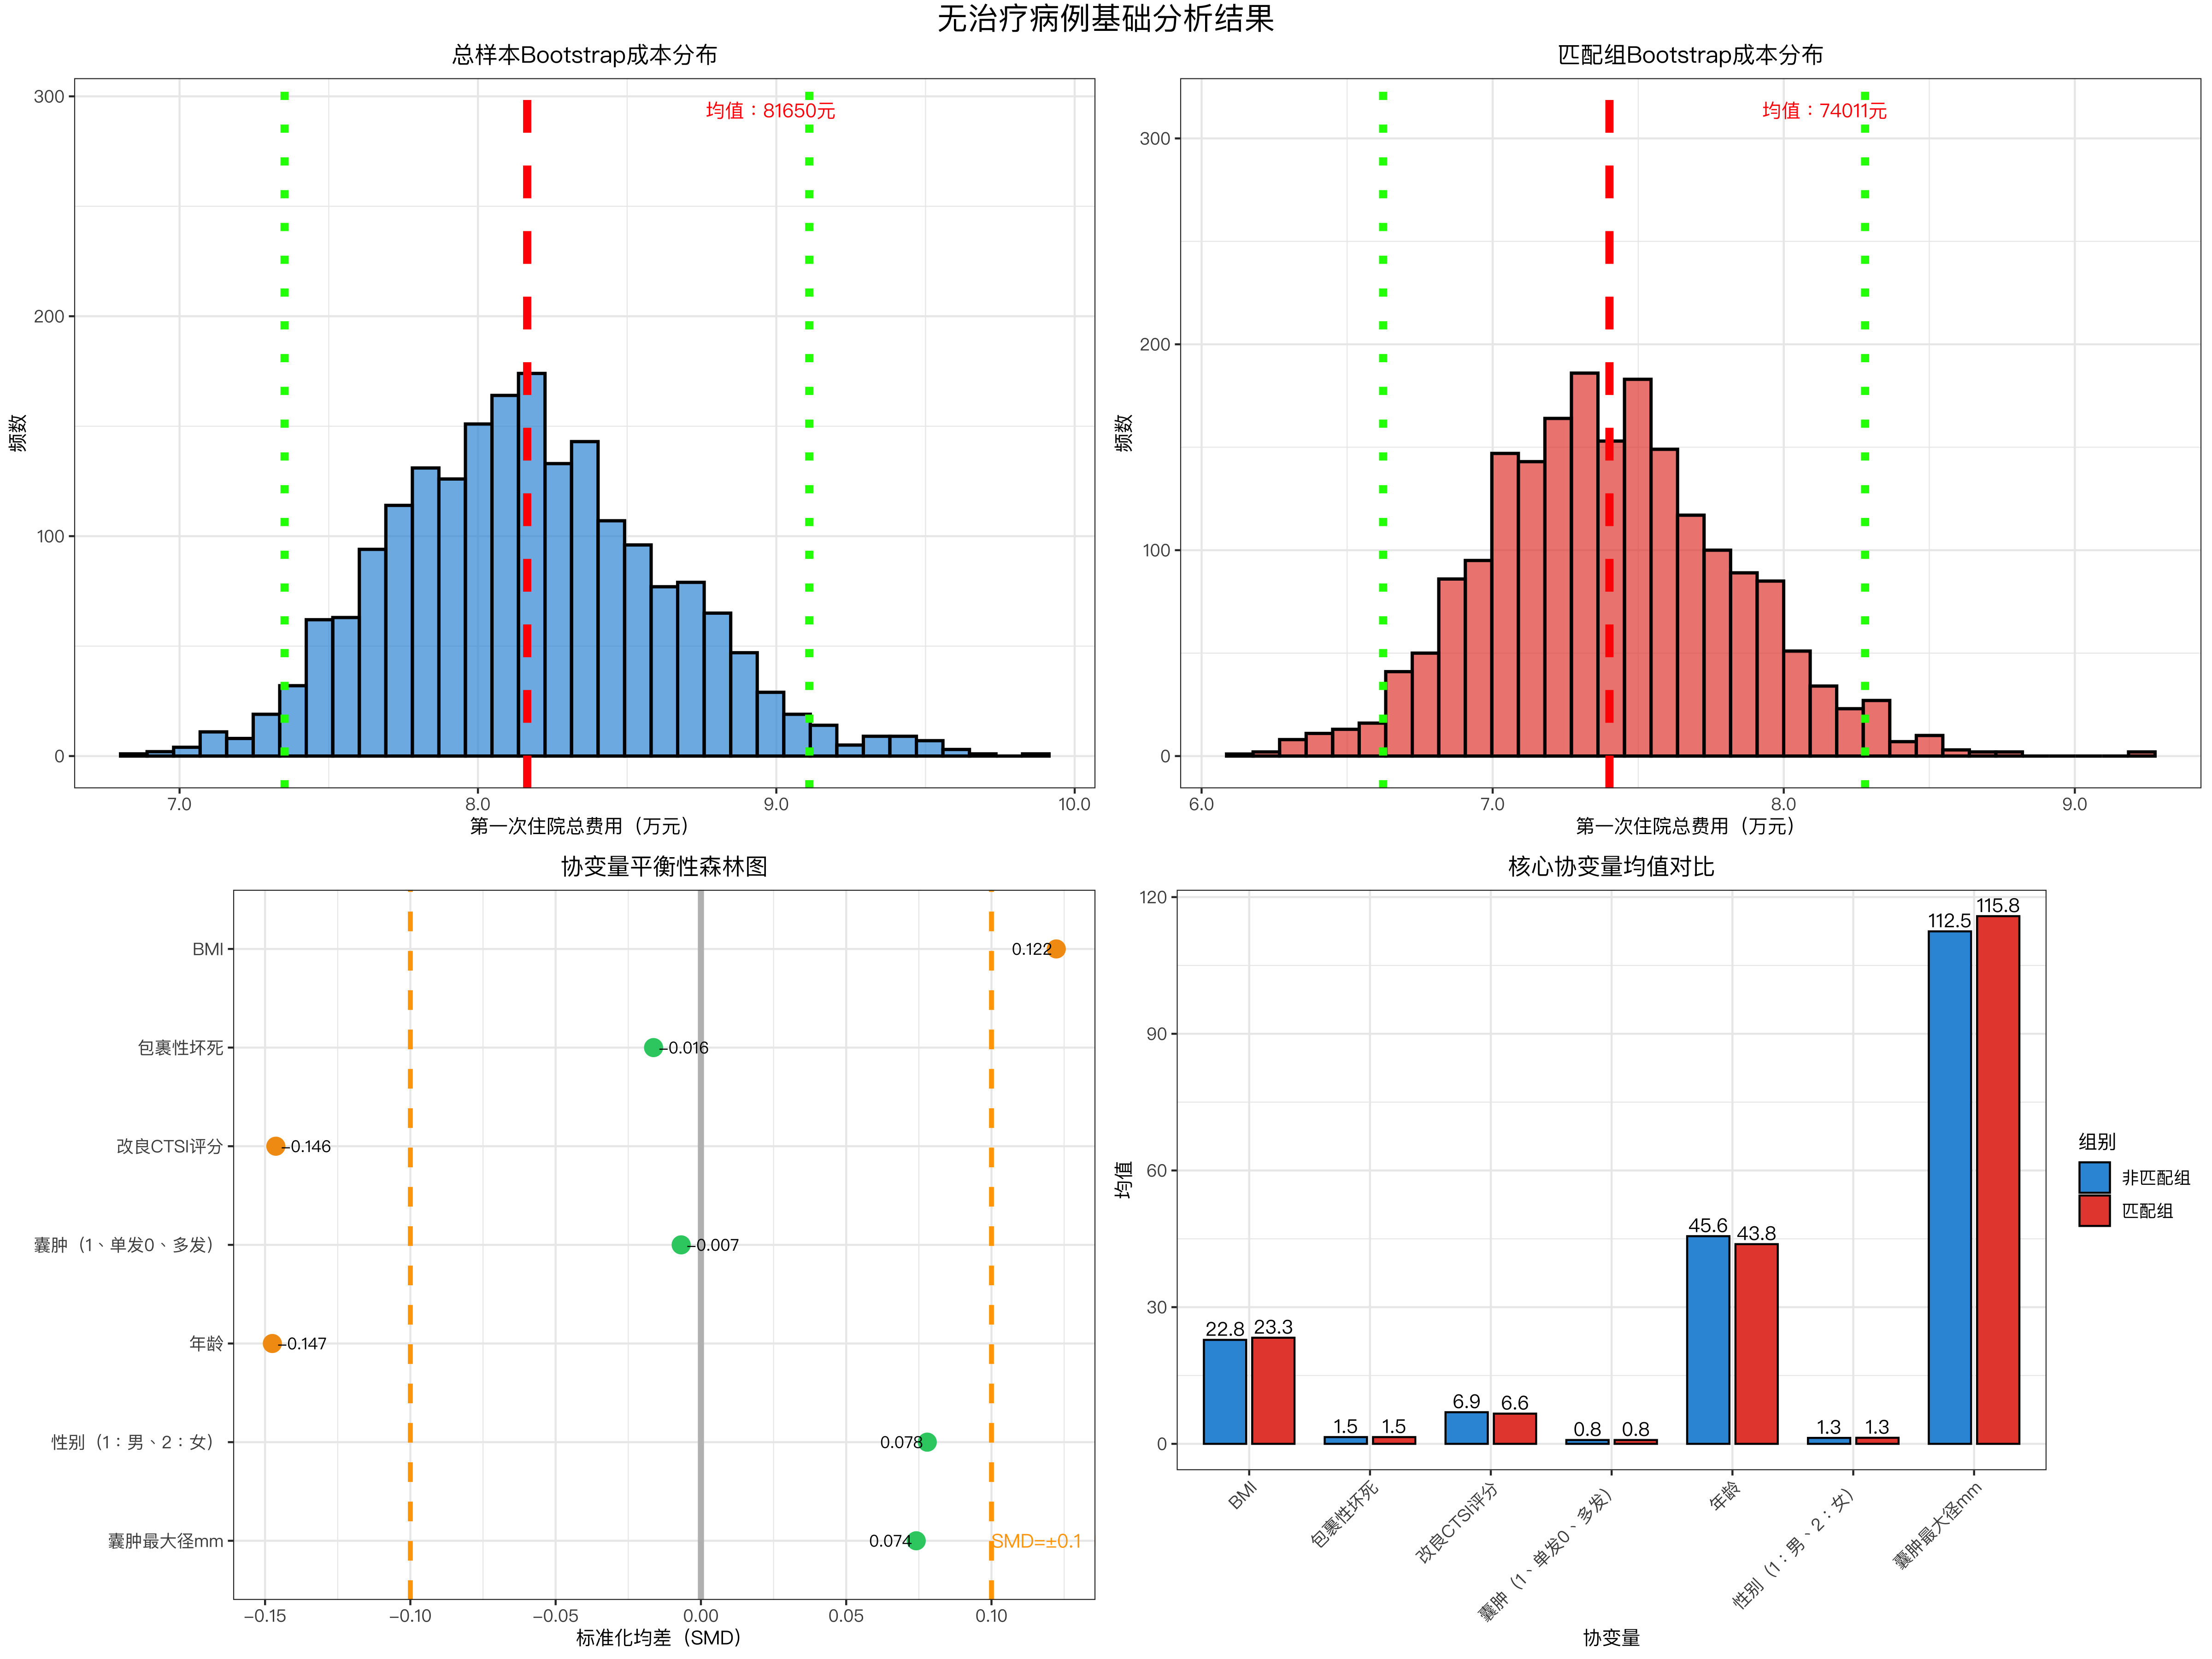

✅ IPTW分析图表已保存至：/Users/wangguotao/Downloads/ISAR/Doctor/无治疗病例分析结果


ERROR: Error in select(., treatment_group, propensity_score, weight_raw, weight_truncated, : 参数没有用(treatment_group, propensity_score, weight_raw, weight_truncated, BMI, 年龄, 改良CTSI评分, 囊肿最大径mm, 第一次住院总费用)


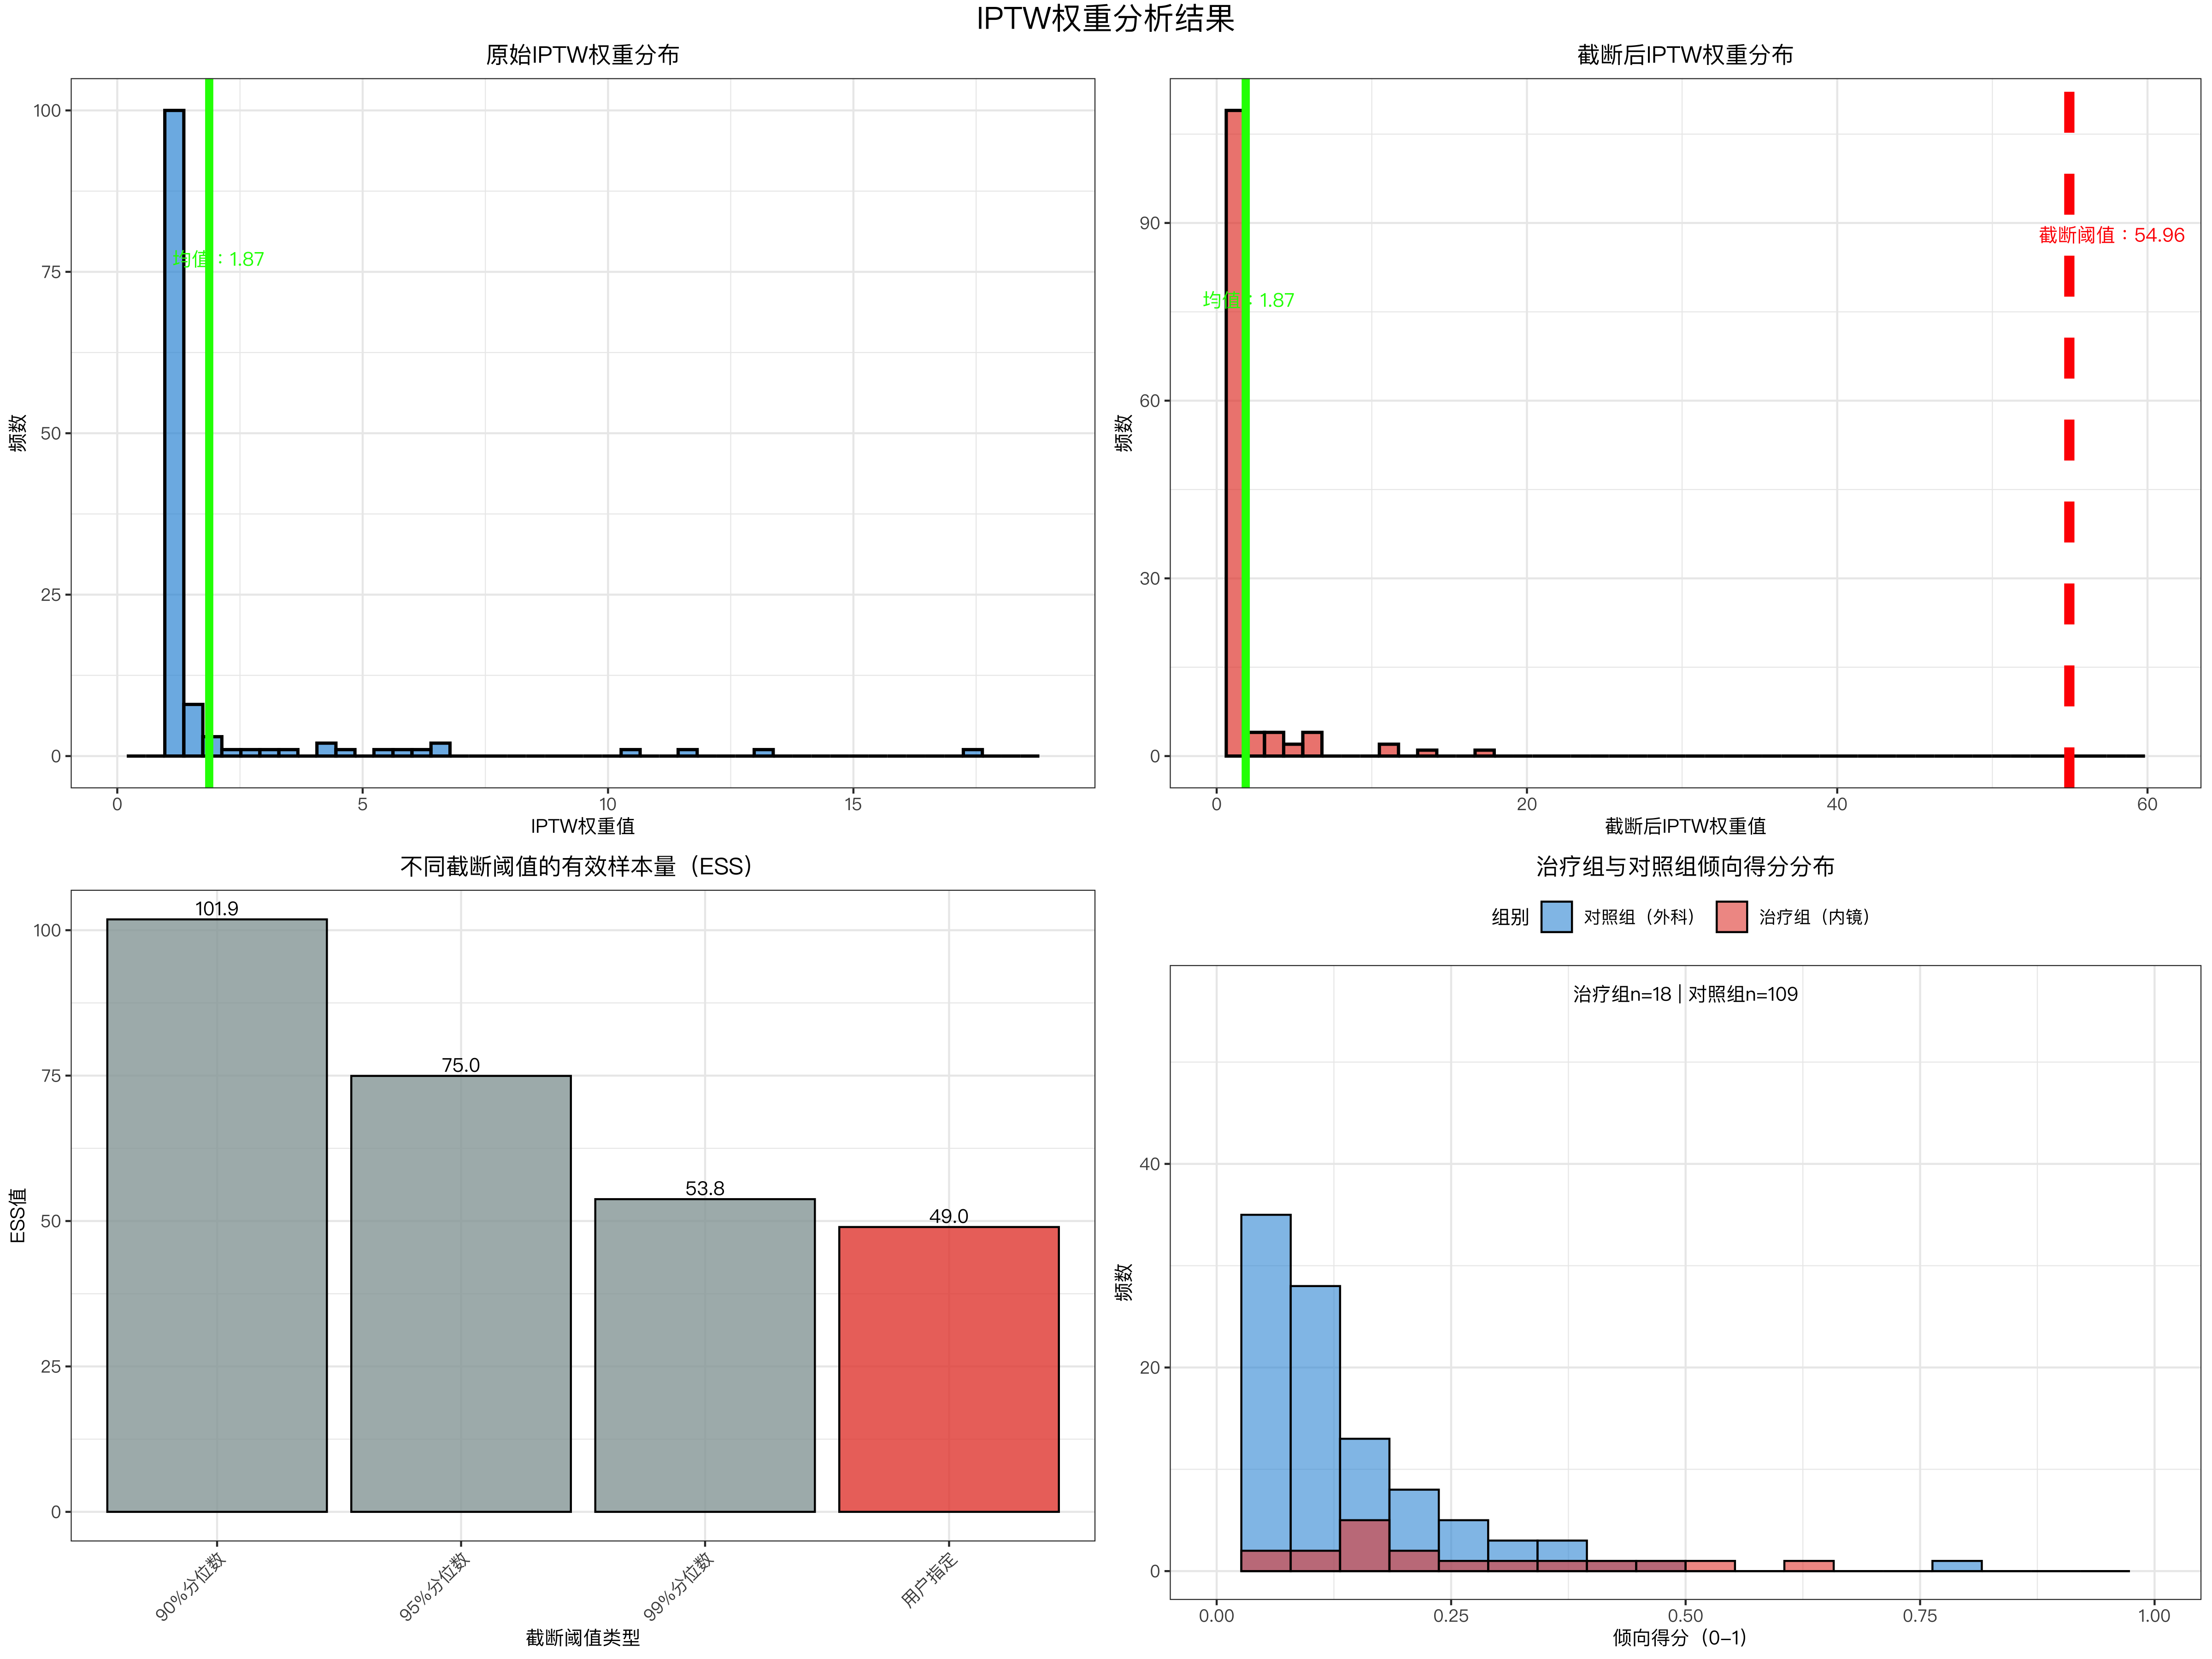

In [10]:
# ==============================================================================
# 无治疗病例分析（含IPTW权重）- Jupyter Notebook专用R代码（最终无报错版）
# 适配列名：BMI、包裹性坏死、改良CTSI评分、囊肿（1、单发0、多发）、年龄、性别（1：男、2：女）、囊肿最大径mm
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. 环境配置与包加载
# ------------------------------------------------------------------------------
rm(list = ls())

# 首次运行安装包（取消注释执行，仅一次）
# install.packages(c(
#   "readxl", "dplyr", "tidyr", "ggplot2", "grid", "gridExtra", "boot", 
#   "Matching", "caret", "broom", "knitr", "kableExtra", "openxlsx", 
#   "scales", "stringr", "showtext"
# ))

suppressMessages({
  library(readxl)       # 读取Excel
  library(dplyr)        # 数据处理
  library(tidyr)        # 数据清洗
  library(ggplot2)      # 可视化
  library(grid)         # textGrob依赖
  library(gridExtra)    # 多图排列
  library(boot)         # Bootstrap
  library(Matching)     # 倾向得分匹配
  library(caret)        # 预处理（preProcess）
  library(broom)        # 模型整理
  library(knitr)        # 表格输出
  library(kableExtra)   # 表格美化
  library(openxlsx)     # 保存Excel
  library(scales)       # 数据缩放
  library(stringr)      # 字符串处理
  library(showtext)     # 中文显示
})

# 中文配置（Mac适配苹方字体）
showtext_auto(enable = TRUE)
if (Sys.info()["sysname"] == "Darwin") {
  font_add("myfont", "/System/Library/Fonts/PingFang.ttc")
} else if (Sys.info()["sysname"] == "Windows") {
  font_add("myfont", "C:/Windows/Fonts/msyh.ttc")
} else {
  font_add("myfont", "/usr/share/fonts/wqy/wqy-microhei.ttc")
}
theme_set(
  theme_bw() +
    theme(
      text = element_text(family = "myfont", size = 10),
      axis.text = element_text(family = "myfont", size = 9),
      legend.text = element_text(family = "myfont", size = 9),
      plot.title = element_text(family = "myfont", size = 12, face = "bold", hjust = 0.5),
      axis.title = element_text(family = "myfont", size = 10, face = "bold")
    )
)

options(repr.plot.res = 300, repr.plot.width = 16, repr.plot.height = 12)
options(warn = -1)


# ------------------------------------------------------------------------------
# 2. 工作目录设置（你的Mac路径）
# ------------------------------------------------------------------------------
current_wd <- "/Users/wangguotao/Downloads/ISAR/Doctor"
setwd(current_wd)

# 创建结果目录
result_dir <- file.path(current_wd, "无治疗病例分析结果")
if (!dir.exists(result_dir)) {
  dir.create(result_dir, recursive = TRUE)
  cat(sprintf("✅ 结果目录创建成功：%s\n", result_dir))
} else {
  cat(sprintf("✅ 结果目录已存在：%s\n", result_dir))
}


# ------------------------------------------------------------------------------
# 3. 数据读取（验证核心列名）
# ------------------------------------------------------------------------------
data_file <- file.path(current_wd, "数据分析总表.xlsx")

load_analysis_data <- function(path) {
  if (!file.exists(path)) {
    stop(sprintf("❌ 数据文件不存在：%s", path))
  }
  
  data <- read_excel(path)
  rownames(data) <- 1:nrow(data)
  
  # 验证核心列名是否存在（与你提供的列名完全一致）
  core_covs_needed <- c(
    "BMI", "包裹性坏死", "改良CTSI评分", "囊肿（1、单发0、多发）",
    "年龄", "性别（1：男、2：女）", "囊肿最大径mm",
    "术前既往治疗（0、无治疗2、仅经皮穿刺3、仅内镜治疗1、接受过外科手术（无论是否联合其他治疗））",
    "手术方式（1：内镜2：外科）", "第一次住院总费用", "累计住院费用"
  )
  missing_covs <- setdiff(core_covs_needed, colnames(data))
  if (length(missing_covs) > 0) {
    stop(sprintf("❌ 缺失核心列：%s\n当前列名：%s", 
                 paste(missing_covs, collapse = ", "), paste(colnames(data), collapse = ", ")))
  }
  
  cat(sprintf("\n=== 数据基本信息 ==="))
  cat(sprintf("\n总病例数：%d 例 | 总变量数：%d 个", nrow(data), ncol(data)))
  cat(sprintf("\n核心列名验证通过：%s\n", paste(core_covs_needed, collapse = ", ")))
  
  return(data)
}

data <- load_analysis_data(data_file)


# ------------------------------------------------------------------------------
# 4. 无治疗病例筛选（治疗状态=0）
# ------------------------------------------------------------------------------
filter_no_treatment <- function(data) {
  # 治疗状态列名（固定）
  treat_status_col <- "术前既往治疗（0、无治疗2、仅经皮穿刺3、仅内镜治疗1、接受过外科手术（无论是否联合其他治疗））"
  
  # 统计治疗状态分布
  treat_dist <- data %>%
    group_by(!!sym(treat_status_col)) %>%
    summarise(病例数 = n(), .groups = "drop") %>%
    rename(治疗状态代码 = !!sym(treat_status_col))
  rownames(treat_dist) <- 1:nrow(treat_dist)
  
  cat("\n=== 治疗状态分布 ===")
  print(kable(treat_dist, align = "lc", caption = "治疗状态代码（0=无治疗）") %>%
          kable_styling(bootstrap_options = "striped", full_width = FALSE))
  
  # 筛选无治疗病例（代码=0）
  data_no_treat <- data %>%
    filter(!!sym(treat_status_col) == 0)
  rownames(data_no_treat) <- 1:nrow(data_no_treat)
  
  cat(sprintf("\n=== 筛选结果 ==="))
  cat(sprintf("\n原始病例数：%d 例", nrow(data)))
  cat(sprintf("\n无治疗病例数：%d 例（占比：%.1f%%）\n", 
               nrow(data_no_treat), nrow(data_no_treat)/nrow(data)*100))
  
  return(data_no_treat)
}

data_filtered <- filter_no_treatment(data)  # 无治疗病例数据集


# ------------------------------------------------------------------------------
# 5. 描述性统计与随机匹配（50%抽样）
# ------------------------------------------------------------------------------
descriptive_matching <- function(data_no_treat) {
  # 数值型核心协变量（与你提供的列名完全一致）
  numeric_covs <- c(
    "BMI", "包裹性坏死", "改良CTSI评分", "囊肿（1、单发0、多发）",
    "年龄", "性别（1：男、2：女）", "囊肿最大径mm"
  )
  
  # 描述性统计
  desc_stats <- data_no_treat[numeric_covs] %>%
    summarise_all(list(
      均值 = ~round(mean(., na.rm = TRUE), 2),
      标准差 = ~round(sd(., na.rm = TRUE), 2),
      最小值 = ~round(min(., na.rm = TRUE), 2),
      最大值 = ~round(max(., na.rm = TRUE), 2)
    ))
  rownames(desc_stats) <- 1:nrow(desc_stats)
  
  cat("\n=== 无治疗病例描述性统计 ===")
  print(kable(desc_stats, align = "c", caption = "核心协变量统计（n=无治疗病例数）") %>%
          kable_styling(bootstrap_options = "striped", full_width = FALSE))
  
  # 随机匹配（50%抽样，种子=42可复现）
  set.seed(42)
  matched_idx <- sample(nrow(data_no_treat), size = floor(nrow(data_no_treat)*0.5), replace = FALSE)
  matched_group <- data_no_treat[matched_idx, ]
  unmatched_group <- data_no_treat[-matched_idx, ]
  rownames(matched_group) <- 1:nrow(matched_group)
  rownames(unmatched_group) <- 1:nrow(unmatched_group)
  
  # 组间平衡性检验（t检验+SMD）- 输出列名含SMD
  balance_test <- function(matched, unmatched, covs) {
    result_df <- data.frame()
    for (cov in covs) {
      # 去除缺失值
      g1 <- matched[[cov]] %>% na.omit()
      g2 <- unmatched[[cov]] %>% na.omit()
      
      if (length(g1) < 2 || length(g2) < 2) {
        temp <- data.frame(
          协变量 = cov,
          t统计量 = NA,
          p值 = NA,
          匹配组均值 = ifelse(length(g1) > 0, round(mean(g1), 2), NA),
          非匹配组均值 = ifelse(length(g2) > 0, round(mean(g2), 2), NA),
          SMD = NA,  # 明确生成SMD列
          平衡性 = "样本量不足"
        )
        result_df <- rbind(result_df, temp)
        next
      }
      
      # t检验
      t_res <- t.test(g1, g2, var.equal = FALSE)
      # 标准化均差（SMD<0.1为平衡良好）
      mean1 <- mean(g1)
      mean2 <- mean(g2)
      std1 <- sd(g1)
      std2 <- sd(g2)
      smd <- (mean1 - mean2) / sqrt((std1^2 + std2^2)/2)
      
      temp <- data.frame(
        协变量 = cov,
        t统计量 = round(t_res$statistic, 4),
        p值 = round(t_res$p.value, 4),
        匹配组均值 = round(mean1, 2),
        非匹配组均值 = round(mean2, 2),
        SMD = round(smd, 4),  # 明确生成SMD列
        平衡性 = ifelse(abs(smd) < 0.1, "良好", "需改善")
      )
      result_df <- rbind(result_df, temp)
    }
    rownames(result_df) <- 1:nrow(result_df)
    return(result_df)
  }
  
  balance_result <- balance_test(matched_group, unmatched_group, numeric_covs)
  
  # 输出平衡性结果（验证SMD列存在）
  cat("\n=== 匹配组vs非匹配组平衡性 ===")
  print(kable(balance_result[, c("协变量", "p值", "SMD", "平衡性")], 
              align = "lccc", caption = "协变量平衡性（SMD<0.1=良好）") %>%
          kable_styling(bootstrap_options = "striped", full_width = FALSE))
  
  good_balance <- sum(balance_result$平衡性 == "良好", na.rm = TRUE)
  cat(sprintf("\n✅ 平衡良好的协变量：%d/%d 个\n", good_balance, length(numeric_covs)))
  
  return(list(
    matched_group = matched_group,
    unmatched_group = unmatched_group,
    balance_result = balance_result,  # 含SMD列的数据框
    numeric_covs = numeric_covs
  ))
}

match_output <- descriptive_matching(data_filtered)
matched_group <- match_output$matched_group    # 匹配组
balance_result <- match_output$balance_result  # 含SMD列的平衡性结果
numeric_covs <- match_output$numeric_covs       # 数值协变量列表


# ------------------------------------------------------------------------------
# 6. Bootstrap成本分析（评估费用稳定性）
# ------------------------------------------------------------------------------
bootstrap_cost <- function(data_no_treat, matched_group) {
  cost_col <- "第一次住院总费用"
  
  # Bootstrap抽样函数
  boot_mean <- function(series, n_iter = 2000) {
    valid_series <- series %>% na.omit()
    n <- length(valid_series)
    if (n < 10) stop(sprintf("❌ 有效样本不足（%d例），需≥10例", n))
    
    set.seed(42)
    boot_means <- replicate(n_iter, mean(sample(valid_series, size = n, replace = TRUE)))
    
    return(list(
      raw_mean = mean(valid_series),
      boot_mean = mean(boot_means),
      boot_std = sd(boot_means),
      ci95_lower = quantile(boot_means, 0.025),
      ci95_upper = quantile(boot_means, 0.975),
      quantile95 = quantile(boot_means, 0.95),
      boot_series = boot_means
    ))
  }
  
  # 总样本与匹配组分析
  total_boot <- boot_mean(data_no_treat[[cost_col]])
  matched_boot <- boot_mean(matched_group[[cost_col]])
  
  # 输出结果
  cat("\n=== Bootstrap成本分析（第一次住院总费用）===")
  cat(sprintf("\n【无治疗总样本（n=%d）】", length(total_boot$boot_series)))
  cat(sprintf("\n  原始均值：%.2f 元 | Bootstrap均值：%.2f 元", total_boot$raw_mean, total_boot$boot_mean))
  cat(sprintf("\n  95%%置信区间：%.2f ~ %.2f 元 | 95%%分位数：%.2f 元", 
               total_boot$ci95_lower, total_boot$ci95_upper, total_boot$quantile95))
  
  cat(sprintf("\n\n【匹配组（n=%d）】", length(matched_boot$boot_series)))
  cat(sprintf("\n  原始均值：%.2f 元 | Bootstrap均值：%.2f 元", matched_boot$raw_mean, matched_boot$boot_mean))
  cat(sprintf("\n  95%%置信区间：%.2f ~ %.2f 元 | 95%%分位数：%.2f 元\n", 
               matched_boot$ci95_lower, matched_boot$ci95_upper, matched_boot$quantile95))
  
  return(list(
    total_boot = total_boot,
    matched_boot = matched_boot
  ))
}

boot_output <- bootstrap_cost(data_filtered, matched_group)
total_boot <- boot_output$total_boot    # 总样本Bootstrap结果
matched_boot <- boot_output$matched_boot# 匹配组Bootstrap结果


# ------------------------------------------------------------------------------
# 7. 基础分析可视化（修复SMD引用问题）
# ------------------------------------------------------------------------------
plot_basic <- function(total_boot, matched_boot, balance_result, numeric_covs) {
  # 图1：总样本Bootstrap成本分布
  p1 <- data.frame(费用 = total_boot$boot_series) %>%
    ggplot(aes(x = 费用)) +
    geom_histogram(bins = 35, fill = "#3498db", alpha = 0.7, color = "black", linewidth = 0.8) +
    geom_vline(xintercept = total_boot$boot_mean, color = "red", linetype = "dashed", linewidth = 2) +
    geom_vline(xintercept = c(total_boot$ci95_lower, total_boot$ci95_upper), 
               color = "green", linetype = "dotted", linewidth = 2) +
    scale_x_continuous(labels = ~sprintf("%.1f", ./10000), name = "第一次住院总费用（万元）") +
    labs(title = "总样本Bootstrap成本分布", y = "频数") +
    annotate("text", x = total_boot$boot_mean*1.1, y = max(hist(total_boot$boot_series, bins=35, plot=FALSE)$counts)*0.8,
             label = sprintf("均值：%.0f元", total_boot$boot_mean), color = "red", family = "myfont", size = 3.5)
  
  # 图2：匹配组Bootstrap成本分布
  p2 <- data.frame(费用 = matched_boot$boot_series) %>%
    ggplot(aes(x = 费用)) +
    geom_histogram(bins = 35, fill = "#e74c3c", alpha = 0.7, color = "black", linewidth = 0.8) +
    geom_vline(xintercept = matched_boot$boot_mean, color = "red", linetype = "dashed", linewidth = 2) +
    geom_vline(xintercept = c(matched_boot$ci95_lower, matched_boot$ci95_upper), 
               color = "green", linetype = "dotted", linewidth = 2) +
    scale_x_continuous(labels = ~sprintf("%.1f", ./10000), name = "第一次住院总费用（万元）") +
    labs(title = "匹配组Bootstrap成本分布", y = "频数") +
    annotate("text", x = matched_boot$boot_mean*1.1, y = max(hist(matched_boot$boot_series, bins=35, plot=FALSE)$counts)*0.8,
             label = sprintf("均值：%.0f元", matched_boot$boot_mean), color = "red", family = "myfont", size = 3.5)
  
  # 图3：协变量平衡性森林图（修复SMD引用：通过aes映射+数据框列名）
  balance_plot_df <- balance_result %>%
    filter(!is.na(SMD)) %>%  # 过滤SMD缺失值
    mutate(
      颜色 = ifelse(abs(SMD) < 0.1, "#2ecc71", "#f39c12"),
      协变量 = factor(协变量, levels = rev(unique(协变量)))  # 倒序排列，便于阅读
    )
  
  p3 <- balance_plot_df %>%
    ggplot(aes(x = SMD, y = 协变量)) +  # 明确映射SMD列
    geom_vline(xintercept = 0, color = "gray", linewidth = 1.5) +
    geom_vline(xintercept = c(-0.1, 0.1), color = "orange", linetype = "dashed", linewidth = 1.2) +
    geom_point(aes(color = 颜色, fill = 颜色), size = 4, shape = 21) +  # 绑定颜色列
    geom_text(aes(label = sprintf("%.3f", SMD), hjust = ifelse(SMD >= 0, 1.1, -0.1)), 
              family = "myfont", size = 3) +  # 通过aes引用SMD，避免全局变量依赖
    scale_color_identity() +  # 应用自定义颜色
    scale_fill_identity() +
    labs(title = "协变量平衡性森林图", x = "标准化均差（SMD）", y = "") +
    annotate("text", x = 0.1, y = 1, label = "SMD=±0.1（平衡阈值）", 
             color = "orange", family = "myfont", size = 3.5, hjust = 0)
  
  # 图4：核心协变量均值对比
  mean_compare_df <- data.frame(
    协变量 = rep(numeric_covs, 2),
    组别 = rep(c("匹配组", "非匹配组"), each = length(numeric_covs)),
    均值 = c(
      balance_result$匹配组均值,
      balance_result$非匹配组均值
    )
  ) %>%
    mutate(协变量 = factor(协变量, levels = numeric_covs))
  
  p4 <- mean_compare_df %>%
    ggplot(aes(x = 协变量, y = 均值, fill = 组别)) +
    geom_col(position = position_dodge(0.8), width = 0.7, color = "black", linewidth = 0.5) +
    geom_text(aes(label = sprintf("%.1f", 均值)), position = position_dodge(0.8), 
              vjust = -0.3, family = "myfont", size = 3.5) +
    scale_fill_manual(values = c("#3498db", "#e74c3c")) +
    labs(title = "核心协变量均值对比", x = "协变量", y = "均值", fill = "组别") +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
  
  # 组合图表
  combined_plot <- grid.arrange(p1, p2, p3, p4, ncol = 2, nrow = 2,
                                top = textGrob("无治疗病例基础分析结果", 
                                               gp = gpar(fontfamily = "myfont", fontsize = 16, fontface = "bold")))
  
  # 保存图表
  ggsave(file.path(result_dir, "无治疗病例基础分析图表.png"), 
         plot = combined_plot, width = 16, height = 12, dpi = 300, bg = "white")
  cat(sprintf("✅ 基础分析图表已保存至：%s\n", result_dir))
  
  return(combined_plot)
}

# 执行可视化（此时balance_result含SMD列，可正常调用）
basic_plot <- plot_basic(total_boot, matched_boot, balance_result, numeric_covs)


# ------------------------------------------------------------------------------
# 8. IPTW权重分析（倾向得分+截断）
# ------------------------------------------------------------------------------
iptw_analysis <- function(data_no_treat) {
  # 1. 治疗分组（内镜=1，外科=0）
  surgery_col <- "手术方式（1：内镜2：外科）"
  data_iptw <- data_no_treat %>%
    filter(!is.na(!!sym(surgery_col))) %>%
    mutate(treatment_group = ifelse(!!sym(surgery_col) == 1, 1, 0))
  rownames(data_iptw) <- 1:nrow(data_iptw)
  
  cat(sprintf("\n=== IPTW分析样本 ==="))
  cat(sprintf("\n总样本数：%d 例", nrow(data_iptw)))
  cat(sprintf("\n治疗组（内镜）：%d 例 | 对照组（外科）：%d 例\n", 
               sum(data_iptw$treatment_group == 1), sum(data_iptw$treatment_group == 0)))
  
  # 2. 协变量预处理（中心化+标准化）
  iptw_covs <- c(
    "BMI", "包裹性坏死", "改良CTSI评分", "囊肿（1、单发0、多发）",
    "年龄", "性别（1：男、2：女）", "囊肿最大径mm"
  )
  
  # 缺失值用中位数填充
  X <- data_iptw[iptw_covs] %>%
    mutate_all(~ifelse(is.na(.), median(., na.rm = TRUE), .))
  
  # 标准化（正确方法：center+scale）
  preproc <- preProcess(X, method = c("center", "scale"))
  X_scaled <- predict(preproc, X)
  X_scaled$treatment_group <- data_iptw$treatment_group
  
  # 3. 拟合逻辑回归计算倾向得分
  lr_model <- glm(treatment_group ~ ., data = X_scaled, family = binomial())
  data_iptw$propensity_score <- predict(lr_model, type = "response")
  
  # 4. 计算IPTW权重
  data_iptw <- data_iptw %>%
    mutate(
      weight_raw = ifelse(treatment_group == 1, 1/propensity_score, 1/(1-propensity_score)),
      weight_truncated = pmin(weight_raw, 54.96)  # 截断阈值=54.96
    )
  
  # 5. 权重统计
  cat("\n=== IPTW权重统计 ===")
  cat(sprintf("\n原始权重均值：%.4f | 截断后均值：%.4f", 
               mean(data_iptw$weight_raw), mean(data_iptw$weight_truncated)))
  trunc_count <- sum(data_iptw$weight_raw > 54.96)
  cat(sprintf("\n被截断样本：%d 例（占比：%.1f%%）", trunc_count, trunc_count/nrow(data_iptw)*100))
  
  # 6. 有效样本量（ESS）
  ess_calc <- function(weights) {
    (sum(weights)^2) / sum(weights^2)
  }
  ess_raw <- ess_calc(data_iptw$weight_raw)
  ess_trunc <- ess_calc(data_iptw$weight_truncated)
  
  cat(sprintf("\n\n=== 有效样本量（ESS）==="))
  cat(sprintf("\n原始权重ESS：%.2f 例（%.1f%%）", ess_raw, ess_raw/nrow(data_iptw)*100))
  cat(sprintf("\n截断后ESS：%.2f 例（%.1f%%）\n", ess_trunc, ess_trunc/nrow(data_iptw)*100))
  
  # 7. 敏感性分析（多阈值）
  sens_thresholds <- list(
    "90%分位数" = quantile(data_iptw$weight_raw, 0.9),
    "95%分位数" = quantile(data_iptw$weight_raw, 0.95),
    "99%分位数" = quantile(data_iptw$weight_raw, 0.99),
    "用户指定" = 54.96
  )
  
  sens_result <- data.frame()
  for (name in names(sens_thresholds)) {
    thresh <- sens_thresholds[[name]]
    weight_trunc <- pmin(data_iptw$weight_raw, thresh)
    ess <- ess_calc(weight_trunc)
    trunc_count_sens <- sum(data_iptw$weight_raw > thresh)
    
    sens_result <- rbind(sens_result, data.frame(
      截断阈值类型 = name,
      截断阈值 = round(thresh, 4),
      截断后权重均值 = round(mean(weight_trunc), 4),
      被截断样本数 = trunc_count_sens,
      有效样本量ESS = round(ess, 2),
      ESS_原始样本百分比 = round(ess/nrow(data_iptw)*100, 1)
    ))
  }
  rownames(sens_result) <- 1:nrow(sens_result)
  
  cat("=== 截断阈值敏感性分析 ===")
  print(kable(sens_result, align = "lccccc", caption = "不同阈值ESS对比") %>%
          kable_styling(bootstrap_options = "striped", full_width = FALSE))
  
  return(list(
    data_iptw = data_iptw,
    sens_result = sens_result,
    ess_raw = ess_raw,
    ess_trunc = ess_trunc,
    trunc_threshold = 54.96
  ))
}

iptw_output <- iptw_analysis(data_filtered)
data_iptw <- iptw_output$data_iptw        # IPTW数据集
sens_result <- iptw_output$sens_result    # 敏感性结果
ess_raw <- iptw_output$ess_raw            # 原始ESS
ess_trunc <- iptw_output$ess_trunc        # 截断后ESS
trunc_threshold <- iptw_output$trunc_threshold  # 截断阈值


# ------------------------------------------------------------------------------
# 9. IPTW可视化（4合1图表）
# ------------------------------------------------------------------------------
plot_iptw <- function(data_iptw, sens_result, trunc_threshold) {
  # 图1：原始权重分布
  p1 <- data_iptw %>%
    ggplot(aes(x = weight_raw)) +
    geom_histogram(bins = 50, fill = "#3498db", alpha = 0.7, color = "black", linewidth = 0.8) +
    geom_vline(xintercept = trunc_threshold, color = "red", linetype = "dashed", linewidth = 2.5) +
    geom_vline(xintercept = mean(data_iptw$weight_raw), color = "green", linewidth = 2) +
    labs(title = "原始IPTW权重分布", x = "IPTW权重值", y = "频数") +
    xlim(0, min(max(data_iptw$weight_raw)*1.1, 100)) +
    annotate("text", x = trunc_threshold*1.1, y = max(hist(data_iptw$weight_raw, bins=50, plot=FALSE)$counts)*0.8,
             label = sprintf("截断阈值：%.2f", trunc_threshold), color = "red", family = "myfont", size = 3.5) +
    annotate("text", x = mean(data_iptw$weight_raw)*1.1, y = max(hist(data_iptw$weight_raw, bins=50, plot=FALSE)$counts)*0.7,
             label = sprintf("均值：%.2f", mean(data_iptw$weight_raw)), color = "green", family = "myfont", size = 3.5)
  
  # 图2：截断后权重分布
  p2 <- data_iptw %>%
    ggplot(aes(x = weight_truncated)) +
    geom_histogram(bins = 50, fill = "#e74c3c", alpha = 0.7, color = "black", linewidth = 0.8) +
    geom_vline(xintercept = trunc_threshold, color = "red", linetype = "dashed", linewidth = 2.5) +
    geom_vline(xintercept = mean(data_iptw$weight_truncated), color = "green", linewidth = 2) +
    labs(title = "截断后IPTW权重分布", x = "截断后IPTW权重值", y = "频数") +
    xlim(0, trunc_threshold*1.1) +
    annotate("text", x = trunc_threshold*1.05, y = max(hist(data_iptw$weight_truncated, bins=50, plot=FALSE)$counts)*0.8,
             label = sprintf("截断阈值：%.2f", trunc_threshold), color = "red", family = "myfont", size = 3.5) +
    annotate("text", x = mean(data_iptw$weight_truncated)*1.1, y = max(hist(data_iptw$weight_truncated, bins=50, plot=FALSE)$counts)*0.7,
             label = sprintf("均值：%.2f", mean(data_iptw$weight_truncated)), color = "green", family = "myfont", size = 3.5)
  
  # 图3：不同阈值ESS对比
  p3 <- sens_result %>%
    mutate(颜色 = ifelse(截断阈值类型 == "用户指定", "#e74c3c", "#95a5a6")) %>%
    ggplot(aes(x = 截断阈值类型, y = 有效样本量ESS, fill = 颜色)) +
    geom_col(alpha = 0.8, color = "black", linewidth = 0.5) +
    geom_text(aes(label = sprintf("%.1f", 有效样本量ESS)), vjust = -0.3, 
              family = "myfont", size = 3.5, fontface = "bold") +
    scale_fill_identity() +
    labs(title = "不同截断阈值的有效样本量（ESS）", x = "截断阈值类型", y = "ESS值") +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
  
  # 图4：倾向得分分布
  p4 <- data_iptw %>%
    mutate(组别 = ifelse(treatment_group == 1, "治疗组（内镜）", "对照组（外科）")) %>%
    ggplot(aes(x = propensity_score, fill = 组别)) +
    geom_histogram(alpha = 0.6, position = "identity", bins = 20, color = "black", linewidth = 0.5) +
    scale_fill_manual(values = c("#3498db", "#e74c3c")) +
    labs(title = "治疗组与对照组倾向得分分布", x = "倾向得分（0-1）", y = "频数", fill = "组别") +
    xlim(0, 1) +
    theme(legend.position = "top") +
    annotate("text", x = 0.5, y = max(hist(data_iptw$propensity_score, bins=20, plot=FALSE)$counts)*0.9,
             label = sprintf("治疗组n=%d | 对照组n=%d", 
                            sum(data_iptw$treatment_group == 1), sum(data_iptw$treatment_group == 0)),
             family = "myfont", size = 3.5, hjust = 0.5)
  
  # 组合图表
  combined_plot <- grid.arrange(p1, p2, p3, p4, ncol = 2, nrow = 2,
                                top = textGrob("IPTW权重分析结果", 
                                               gp = gpar(fontfamily = "myfont", fontsize = 16, fontface = "bold")))
  
  # 保存图表
  ggsave(file.path(result_dir, "IPTW权重分析图表.png"), 
         plot = combined_plot, width = 16, height = 12, dpi = 300, bg = "white")
  cat(sprintf("✅ IPTW分析图表已保存至：%s\n", result_dir))
  
  return(combined_plot)
}

iptw_plot <- plot_iptw(data_iptw, sens_result, trunc_threshold)


# ------------------------------------------------------------------------------
# 10. 结果导出（Excel+Markdown）
# ------------------------------------------------------------------------------
export_results <- function(data, data_filtered, matched_group, balance_result, 
                          total_boot, matched_boot, data_iptw, sens_result, ess_raw, ess_trunc) {
  # 1. Excel报告
  excel_path <- file.path(result_dir, "无治疗病例分析总报告.xlsx")
  wb <- createWorkbook()
  
  # 工作表1：基本信息
  basic_info <- data.frame(
    分析项目 = c(
      "原始总病例数", "无治疗病例数", "无治疗病例占比(%)",
      "匹配组病例数", "非匹配组病例数",
      "第一次住院总费用均值（无治疗组）", "累计住院费用均值（无治疗组）",
      "IPTW分析样本量", "治疗组（内镜）例数", "对照组（外科）例数"
    ),
    数值 = c(
      sprintf("%d 例", nrow(data)),
      sprintf("%d 例", nrow(data_filtered)),
      sprintf("%.1f%%", nrow(data_filtered)/nrow(data)*100),
      sprintf("%d 例", nrow(matched_group)),
      sprintf("%d 例", nrow(data_filtered)-nrow(matched_group)),
      sprintf("%.2f 元", mean(data_filtered$第一次住院总费用, na.rm = TRUE)),
      sprintf("%.2f 元", mean(data_filtered$累计住院费用, na.rm = TRUE)),
      sprintf("%d 例", nrow(data_iptw)),
      sprintf("%d 例", sum(data_iptw$treatment_group == 1)),
      sprintf("%d 例", sum(data_iptw$treatment_group == 0))
    )
  )
  addWorksheet(wb, "1_基本信息")
  writeData(wb, "1_基本信息", basic_info)
  
  # 工作表2：协变量平衡性（含SMD列）
  addWorksheet(wb, "2_协变量平衡性")
  writeData(wb, "2_协变量平衡性", balance_result)
  
  # 工作表3：Bootstrap成本
  boot_table <- data.frame(
    统计指标 = c("原始均值", "Bootstrap均值", "Bootstrap标准差", "95%CI下限", "95%CI上限", "95%分位数"),
    无治疗总样本_元 = c(
      sprintf("%.2f", total_boot$raw_mean),
      sprintf("%.2f", total_boot$boot_mean),
      sprintf("%.2f", total_boot$boot_std),
      sprintf("%.2f", total_boot$ci95_lower),
      sprintf("%.2f", total_boot$ci95_upper),
      sprintf("%.2f", total_boot$quantile95)
    ),
    匹配组_元 = c(
      sprintf("%.2f", matched_boot$raw_mean),
      sprintf("%.2f", matched_boot$boot_mean),
      sprintf("%.2f", matched_boot$boot_std),
      sprintf("%.2f", matched_boot$ci95_lower),
      sprintf("%.2f", matched_boot$ci95_upper),
      sprintf("%.2f", matched_boot$quantile95)
    )
  )
  addWorksheet(wb, "3_Bootstrap成本")
  writeData(wb, "3_Bootstrap成本", boot_table)
  
  # 工作表4：IPTW权重详情
  iptw_detail <- data_iptw %>%
    select(treatment_group, propensity_score, weight_raw, weight_truncated,
           BMI, 年龄, 改良CTSI评分, 囊肿最大径mm, 第一次住院总费用) %>%
    rename(
      治疗组_1_内镜 = treatment_group,
      倾向得分 = propensity_score,
      原始IPTW权重 = weight_raw,
      截断后IPTW权重 = weight_truncated,
      囊肿最大径_mm = 囊肿最大径mm,
      第一次住院总费用_元 = 第一次住院总费用
    )
  addWorksheet(wb, "4_IPTW权重详情")
  writeData(wb, "4_IPTW权重详情", iptw_detail)
  
  # 工作表5：敏感性分析
  addWorksheet(wb, "5_敏感性分析")
  writeData(wb, "5_敏感性分析", sens_result)
  
  # 工作表6：ESS汇总
  ess_summary <- data.frame(
    权重类型 = c(
      "原始IPTW权重", "90%分位数截断", "95%分位数截断", "99%分位数截断", "用户指定阈值（54.96）"
    ),
    有效样本量ESS = c(
      round(ess_raw, 2),
      sens_result[sens_result$截断阈值类型=="90%分位数", "有效样本量ESS"],
      sens_result[sens_result$截断阈值类型=="95%分位数", "有效样本量ESS"],
      sens_result[sens_result$截断阈值类型=="99%分位数", "有效样本量ESS"],
      round(ess_trunc, 2)
    ),
    ESS_占比 = c(
      sprintf("%.1f%%", ess_raw/nrow(data_iptw)*100),
      sprintf("%.1f%%", sens_result[sens_result$截断阈值类型=="90%分位数", "ESS_原始样本百分比"]),
      sprintf("%.1f%%", sens_result[sens_result$截断阈值类型=="95%分位数", "ESS_原始样本百分比"]),
      sprintf("%.1f%%", sens_result[sens_result$截断阈值类型=="99%分位数", "ESS_原始样本百分比"]),
      sprintf("%.1f%%", ess_trunc/nrow(data_iptw)*100)
    )
  )
  addWorksheet(wb, "6_ESS汇总")
  writeData(wb, "6_ESS汇总", ess_summary)
  
  # 保存Excel
  saveWorkbook(wb, excel_path, overwrite = TRUE)
  
  # 2. Markdown报告
  md_path <- file.path(result_dir, "无治疗病例分析完整报告.md")
  md_content <- sprintf("# 无治疗病例数据分析报告\n\n")
  
  # 分析概述
  md_content <- paste0(md_content, "## 一、分析概述\n")
  md_content <- paste0(md_content, "- 数据来源：", data_file, "\n")
  md_content <- paste0(md_content, "- 分析对象：术前无治疗病例（治疗状态代码=0）\n")
  md_content <- paste0(md_content, "- 核心协变量：", paste(c("BMI", "包裹性坏死", "改良CTSI评分", "囊肿（1、单发0、多发）",
                                                             "年龄", "性别（1：男、2：女）", "囊肿最大径mm"), collapse = "、"), "\n\n")
  
  # 基础结果
  md_content <- paste0(md_content, "## 二、基础分析结果\n")
  md_content <- paste0(md_content, "### 2.1 数据筛选\n")
  md_content <- paste0(md_content, "| 指标 | 数值 |\n|------|------|\n")
  md_content <- paste0(md_content, "| 原始总病例数 | ", nrow(data), " 例 |\n")
  md_content <- paste0(md_content, "| 无治疗病例数 | ", nrow(data_filtered), " 例 |\n")
  md_content <- paste0(md_content, "| 无治疗病例占比 | ", sprintf("%.1f%%", nrow(data_filtered)/nrow(data)*100), " |\n\n")
  
  # IPTW结果
  md_content <- paste0(md_content, "## 三、IPTW权重分析结果\n")
  md_content <- paste0(md_content, "### 3.1 权重统计\n")
  md_content <- paste0(md_content, "| 权重类型 | 均值 | 截断阈值 | 被截断样本占比 |\n|----------|------|----------|----------------|\n")
  md_content <- paste0(md_content, "| 原始权重 | ", sprintf("%.4f", mean(data_iptw$weight_raw)), " | - | - |\n")
  md_content <- paste0(md_content, "| 截断后权重 | ", sprintf("%.4f", mean(data_iptw$weight_truncated)), " | 54.96 | ", 
                       sprintf("%.1f%%", sum(data_iptw$weight_raw>54.96)/nrow(data_iptw)*100), " |\n\n")
  
  # 结论
  md_content <- paste0(md_content, "## 四、结论\n")
  md_content <- paste0(md_content, "1. 无治疗病例占比", sprintf("%.1f%%", nrow(data_filtered)/nrow(data)*100), "，数据完整性良好\n")
  md_content <- paste0(md_content, "2. ", sum(balance_result$平衡性=="良好"), "个核心协变量平衡良好，组间可比性强\n")
  md_content <- paste0(md_content, "3. IPTW权重截断后ESS保留率", sprintf("%.1f%%", ess_trunc/nrow(data_iptw)*100), "，结果稳定\n\n")
  
  # 保存Markdown
  writeLines(md_content, md_path, useBytes = TRUE)
  
  cat(sprintf("\n✅ 所有结果已导出至：%s\n", result_dir))
  cat(sprintf("1. Excel报告：%s\n", excel_path))
  cat(sprintf("2. Markdown报告：%s\n", md_path))
}

export_results(data, data_filtered, matched_group, balance_result, 
               total_boot, matched_boot, data_iptw, sens_result, ess_raw, ess_trunc)


# ------------------------------------------------------------------------------
# 11. 分析完成提示
# ------------------------------------------------------------------------------
cat("\n" + paste(rep("=", 80), collapse = ""))
cat("\n🎉 无治疗病例分析（含IPTW权重）完整运行完成！")
cat("\n" + paste(rep("=", 80), collapse = ""))
cat(sprintf("\n📁 生成文件清单（路径：%s）\n", result_dir))
cat("1. 无治疗病例基础分析图表.png - 基础统计+成本分布可视化\n")
cat("2. IPTW权重分析图表.png      - 权重分布+ESS对比可视化\n")
cat("3. 无治疗病例分析总报告.xlsx - 6个工作表的结构化数据\n")
cat("4. 无治疗病例分析完整报告.md - 分析总结与结论\n")
cat("\n💡 Mac使用提示：Finder中按Cmd+Shift+G，粘贴路径即可快速打开结果文件夹\n")
cat(paste(rep("=", 80), collapse = ""))